In [1]:
# === Importação de Biliotecas ===
import os
import gc
import math
import time
import math
import time
#import tqdm
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from tqdm.notebook import tqdm
from sklearn.metrics import auc
import zipfile
import subprocess
import numpy as np
import pandas as pd
from fpdf import FPDF
import seaborn as sns
import miceforest as mf
import matplotlib.pyplot as plt
from scipy.stats import bootstrap
from sklearn.metrics import log_loss
import matplotlib.patches as mpatches
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, balanced_accuracy_score, roc_auc_score, roc_curve, confusion_matrix


In [2]:
#import gc
#import time
#import threading
#
#def gc_daemon(interval=360):
#    """Força gc.collect() a cada `interval` segundos neste processo."""
#    while True:
#        collected = gc.collect()
#        print(f"[GC] Coletados {collected} objetos – {time.strftime('%H:%M:%S')}")
#        time.sleep(interval)#
#
# iniciar o GC em background
#threading.Thread(target=gc_daemon, args=(360,), daemon=True).start()

In [3]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=r"X does not have valid feature names, but .* was fitted with feature names",
    category=UserWarning,
)

import os
os.environ["PYTHONWARNINGS"] = (
     "ignore:X does not have valid feature names, but .* was fitted with feature names:UserWarning"
 )

In [4]:
from joblib import load

# === Parametros Genéricos ===
# === Definição de Parâmetros - Obrigatório ser informados pelo usuario
BASE_PATH = "STROKE_PFI_RANDOM" 
FILE_IN = Path('../STROKE/data/processed/healthcare_stroke_data.csv')

os.makedirs(BASE_PATH, exist_ok=True)

METHOD = "" #Informado na célula de cada método

direcao_esperada = {
    'age': +1,                # idades mais avançadas aumentam o risco de AVC

    'hypertension': +1,       # 1 = hipertensão presente → maior risco de AVC
    'heart_disease': +1,      # 1 = doença cardíaca presente → maior risco de AVC

    'avg_glucose_level': +1,  # níveis médios de glicose mais altos (ex: diabetes) → maior risco
    'bmi': +1,                # IMC maior (sobrepeso/obesidade) tende a aumentar o risco de AVC

    'gender': 0,              # efeito é controverso / depende de faixa etária → sem direção fixa
    'ever_married': +1,       # em geral, "ever_married = 1" aparece mais em pessoas mais velhas → correlação positiva com AVC
    'work_type': 0,           # categorias de trabalho têm efeito mais contextual (stress, sedentarismo) → sem direção única
    'Residence_type': 0,      # urbano/rural depende de contexto (acesso à saúde, estilo de vida) → sem direção única

    'smoking_status': +1,     # maior exposição ao tabaco (fumante/ ex-fumante) → maior risco de AVC

    'stroke': 0,              # variável alvo (0/1), não faz sentido atribuir direção
    'id': 0                   # identificador, sem significado clínico direto
}


PATH_CSV = Path('../STROKE/model_reports/random_forest/basico/csv/')
#X_test_basic_full.csv
#X_train_basic_full.csv

X_train = pd.read_csv(PATH_CSV / 'X_train_basic_full.csv')  
X_test = pd.read_csv(PATH_CSV / 'X_test_basic_full.csv')  

X_train = X_train.drop(X_train.columns[0], axis=1)
X_test = X_test.drop(X_test.columns[0], axis=1)

X = pd.concat([X_train, X_test], ignore_index=True).sort_values(by="id").reset_index(drop=True)
X_ = X.copy()
Y = X['y'].copy()

EXCLUDE_COLS = ['id', 'y_pred', 'y_proba', 'y','stroke']
model = load("../STROKE/common/models/random_forest/v1/rf_model_cf10.pkl")

# ======================================================================
# 1. PREPARAÇÃO INICIAL E CONFIGURAÇÃO
# ======================================================================

# Identifica as colunas que DEVEM ser processadas
FEATURES = [c for c in X.columns if c not in EXCLUDE_COLS]

# Seleciona apenas as features relevantes para o processamento
X_processed_raw = X[FEATURES].copy()
X_train_processed_raw = X_train[FEATURES].copy()

# Detecta tipos de dados nas features selecionadas
num_cols = [c for c in FEATURES if pd.api.types.is_numeric_dtype(X_processed_raw[c])]
cat_cols = [c for c in FEATURES if c not in num_cols]

# ======================================================================
# 2. PIPELINE DE PRÉ-PROCESSAMENTO
# ======================================================================

# Pipelines para dados numéricos e categóricos (exatamente os mesmos do seu código)
num_pipe = Pipeline(steps=[
    ("imp", SimpleImputer(strategy="median")),
])
cat_pipe = Pipeline(steps=[
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ord", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1,
        encoded_missing_value=-1
    ))
])

# ColumnTransformer para aplicar os pipelines corretos a cada tipo de coluna
preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop" # Garante que apenas as colunas em FEATURES sejam mantidas
)

# ======================================================================
# 3. APLICAÇÃO DO PRÉ-PROCESSAMENTO
# ======================================================================

# Aplicar o fit_transform se este for o conjunto de treino
# Se você já treinou seu preprocessador em outro lugar, use apenas .transform()

# Exemplo usando fit_transform no seu DataFrame X de entrada:
X_ = preprocess.fit_transform(X_processed_raw)
X_train_ = preprocess.transform(X_train_processed_raw)

# O resultado X_ é um array numpy com seus dados prontos,
# com todas as nulos tratados e categóricas transformadas em números.

try:
    # sklearn >= 1.0 geralmente tem isso
    col_names = preprocess.get_feature_names_out()
    # opcional: remover prefixos "num__" / "cat__"
    col_names = [name.split("__", 1)[1] if "__" in name else name
                 for name in col_names]
except Exception:
    # fallback simples: como não houve expansão (ordinal), nº de colunas é o mesmo
    col_names = num_cols + cat_cols

# 1) DataFrames só com as features processadas
X_df = pd.DataFrame(X_, columns=col_names, index=X_processed_raw.index)
X_train_df = pd.DataFrame(X_train_, columns=col_names, index=X_train_processed_raw.index)

X_df = X_df[model.feature_names_in_]

# 2) Anexar id e y preservando alinhamento pelo índice
#    (X e X_train são os DataFrames "brutos", com id / y)
X_df = X_df.copy()
X_df["id"] = X.loc[X_df.index, "id"].values
if "y" in X.columns:
    X_df["y"] = X.loc[X_df.index, "y"].values

X_train_df = X_train_df.copy()
X_train_df["id"] = X_train.loc[X_train_df.index, "id"].values
if "y" in X_train.columns:
    X_train_df["y"] = X_train.loc[X_train_df.index, "y"].values

# 3) Colocar id e y nas primeiras posições, features depois
feature_cols = [c for c in X_df.columns if c not in ("id", "y")]
X_df = X_df[["id", "y"] + feature_cols]

# garantir que X_train_df tenha EXATAMENTE as mesmas features na mesma ordem
X_train_df = X_train_df[["id", "y"] + feature_cols]

# (Opcional) pequenas sanidades:
assert list(X_df.columns) == ["id", "y"] + feature_cols
assert list(X_train_df.columns) == ["id", "y"] + feature_cols

#ajsute final 
X_ = X_df.copy()

ENTRADAS_SELECIONADAS = pd.read_csv(Path('../STROKE/clusters_reports/random_forest/csv/entradas_selecionadas_final_id_only.csv'))
ENTRADAS_SELECIONADAS = ENTRADAS_SELECIONADAS.T.squeeze().to_list() 


In [5]:
#X_ # d	y	age	avg_glucose_level	bmi	gender	hypertension	heart_disease	ever_married	work_type	Residence_type	smoking_status
# gender	age	hypertension	heart_disease	ever_married	work_type	Residence_type	avg_glucose_level	bmi	smoking_status
#model.feature_names_in_
#X_ = X_[model.feature_names_in_]

#model.feature_names_in_
#X_  
model


,n_estimators,650
,criterion,'entropy'
,max_depth,16
,min_samples_split,8
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,0.3
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Invalid -W option ignored: invalid action: 'but .* was fitted with feature names'
✅ Arquivo salvo em STROKE_PFI_RANDOM/XAI_PFI.xlsx


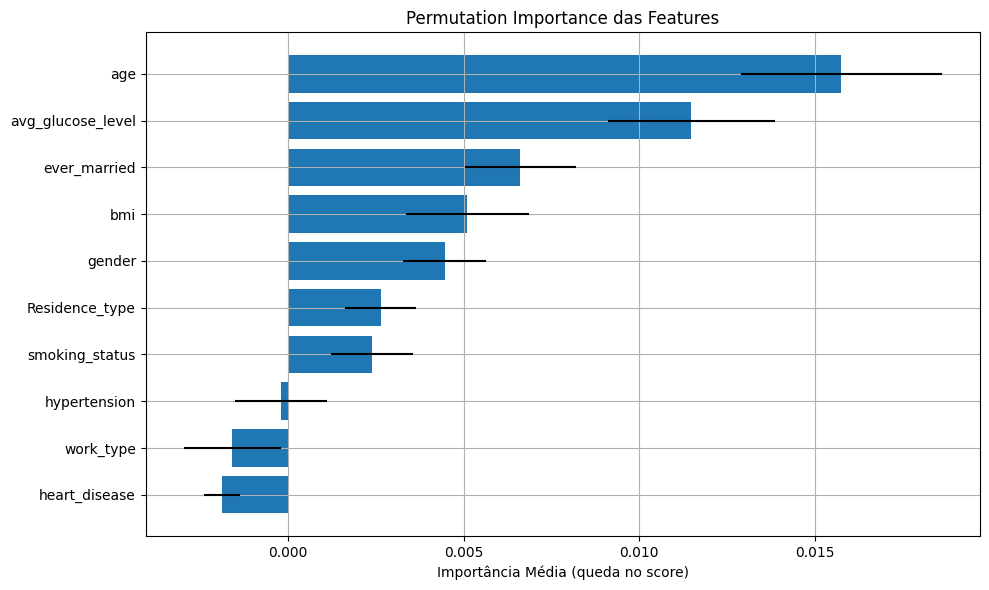

In [6]:
# ===  Permutation Importance Interpretabilidade  ===
# Instalar bibliotecas se necessário
!pip install scikit-learn openpyxl

# Bibliotecas
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Configurações
PATH_FILE_OUT = BASE_PATH          # salva diretamente na pasta base
NM_FILE_PFI = "XAI_PFI"            # nome do arquivo (sem extensão)

# === selecionar apenas features válidas (sem colunas excluídas) ===
feature_cols = [c for c in X.columns if c not in EXCLUDE_COLS]
X_feat = X_[feature_cols].copy()
Y = X['stroke'].copy()

# Calcula Permutation Importance
result = permutation_importance(
    model,
    X_feat,
    Y,
    n_repeats=30,
    random_state=42,
    scoring='accuracy'
)

# Organiza os resultados em DataFrame
df_pi = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

# Salva arquivo diretamente em BASE_PATH
os.makedirs(PATH_FILE_OUT, exist_ok=True)  # não cria subpasta adicional
df_pi.to_excel(f"{PATH_FILE_OUT}/{NM_FILE_PFI}.xlsx", index=False)
print(f"✅ Arquivo salvo em {PATH_FILE_OUT}/{NM_FILE_PFI}.xlsx")

# Visualização gráfica
plt.figure(figsize=(10, 6))
plt.barh(df_pi['feature'], df_pi['importance_mean'], xerr=df_pi['importance_std'])
plt.xlabel("Importância Média (queda no score)")
plt.title("Permutation Importance das Features")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()


Invalid -W option ignored: invalid action: 'but .* was fitted with feature names'
✅ Arquivo salvo em STROKE_PFI_RANDOM/XAI_PFI.xlsx


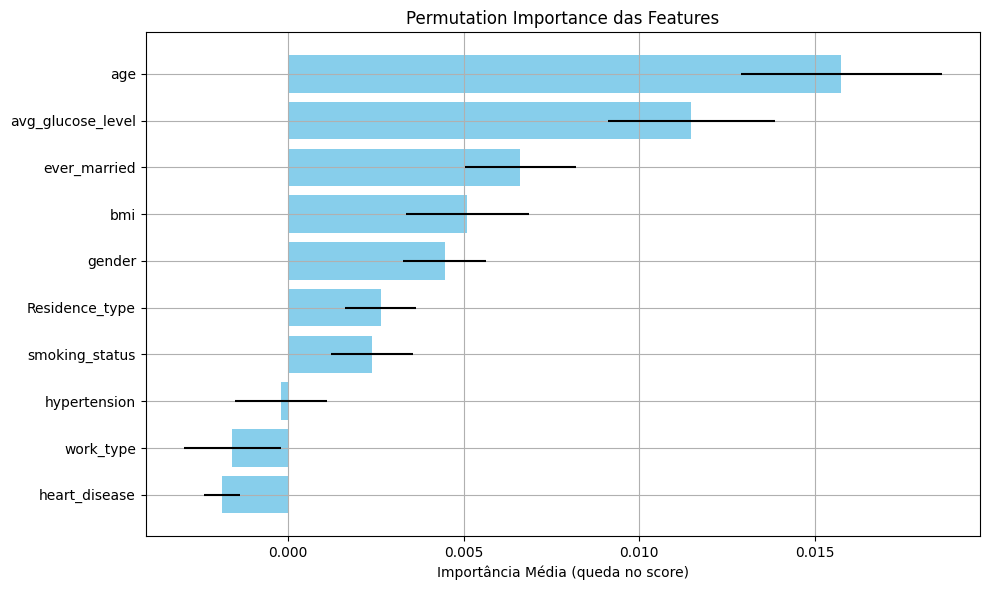

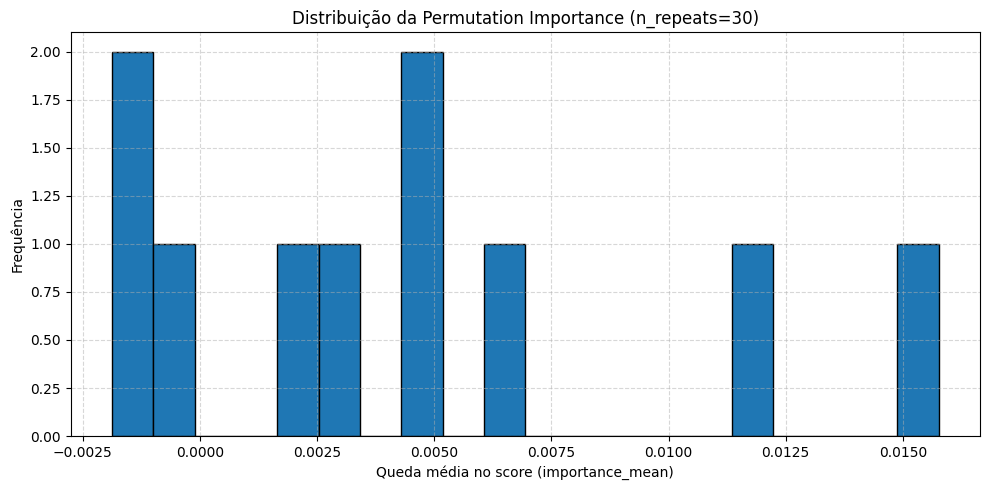

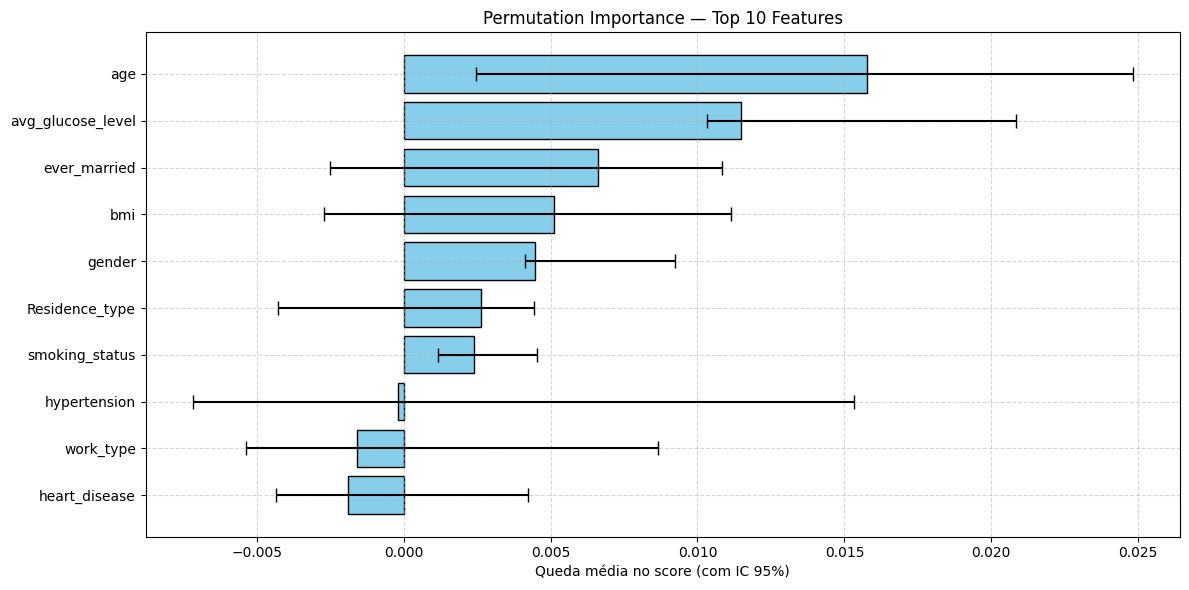

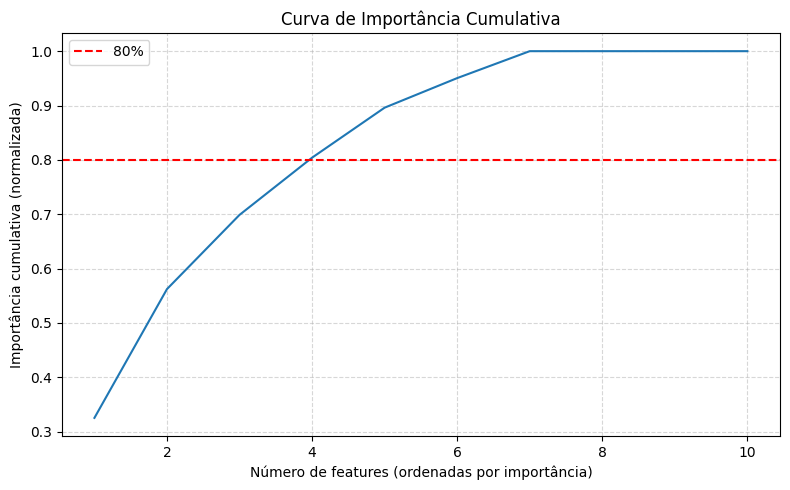

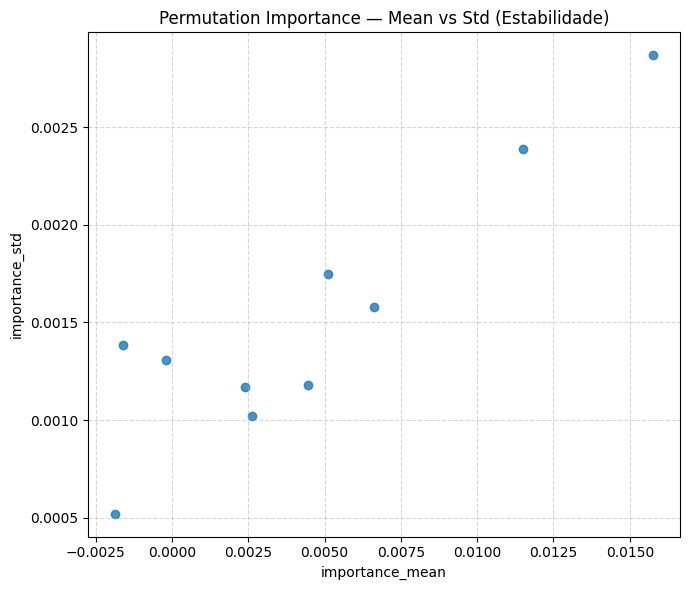

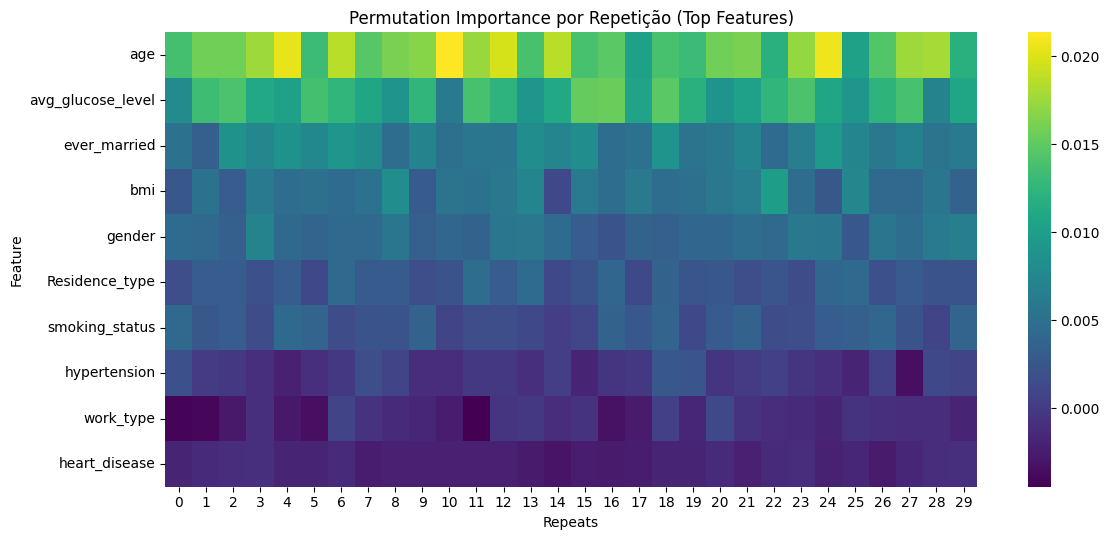

In [7]:
# ===  Permutation Importance Interpretabilidade [Avaliações Complementares]===
# Instalar bibliotecas se necessário
!pip install scikit-learn openpyxl

# Bibliotecas
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Configurações
PATH_FILE_OUT = BASE_PATH          # salva diretamente na pasta base
NM_FILE_PFI = "XAI_PFI"            # nome do arquivo (sem extensão)

# === selecionar apenas features válidas (sem colunas excluídas) ===
feature_cols = [c for c in X.columns if c not in EXCLUDE_COLS]
X_feat = X_[feature_cols].copy()

# Calcula Permutation Importance
result = permutation_importance(
    model,
    X_feat,
    Y,
    n_repeats=30,
    random_state=42,
    scoring='accuracy'  # f1 # roc_auc
)

# Organiza os resultados em DataFrame
df_pi = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

# Cria pasta de saída e salva arquivo
os.makedirs(PATH_FILE_OUT, exist_ok=True)
df_pi.to_excel(f"{PATH_FILE_OUT}/{NM_FILE_PFI}.xlsx", index=False)  # <-- usa NM_FILE_PFI corretamente
print(f"✅ Arquivo salvo em {PATH_FILE_OUT}/{NM_FILE_PFI}.xlsx")

# Visualização gráfica
plt.figure(figsize=(10, 6))
plt.barh(df_pi['feature'], df_pi['importance_mean'], xerr=df_pi['importance_std'], color='skyblue')
plt.xlabel("Importância Média (queda no score)")
plt.title("Permutation Importance das Features")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================
# Visualizações (análogas ao bloco do LIME) — ADIÇÃO
# ==========================

# Preparos extras (IC 95% por percentis e estabilidade)
imps = result.importances  # shape: (n_features, n_repeats)
df_pi['ci_low'] = np.percentile(imps, 2.5, axis=1)
df_pi['ci_high'] = np.percentile(imps, 97.5, axis=1)
df_pi['stability'] = 1 - (df_pi['importance_std'] / (np.abs(df_pi['importance_mean']) + 1e-12))
df_pi = df_pi.reset_index(drop=True)

# 1) Histograma das importâncias
plt.figure(figsize=(10, 5))
plt.hist(df_pi['importance_mean'], bins=20, edgecolor='black')
plt.title(f"Distribuição da Permutation Importance (n_repeats={imps.shape[1]})")
plt.xlabel("Queda média no score (importance_mean)")
plt.ylabel("Frequência")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2) Top-k barras com IC 95%
top_k = min(20, len(df_pi))
top_df = df_pi.head(top_k).copy()
yerr = np.vstack([
    (top_df['importance_mean'] - top_df['ci_low']).abs().to_numpy(),
    (top_df['ci_high'] - top_df['importance_mean']).abs().to_numpy()
])
plt.figure(figsize=(12, 6))
plt.barh(top_df['feature'], top_df['importance_mean'], xerr=yerr, capsize=5, color="skyblue", edgecolor="black")
plt.gca().invert_yaxis()
plt.xlabel("Queda média no score (com IC 95%)")
plt.title(f"Permutation Importance — Top {top_k} Features")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 3) Curva de importância cumulativa
plt.figure(figsize=(8, 5))
cum = np.cumsum(np.maximum(df_pi['importance_mean'].values, 0))
total = cum[-1] if cum[-1] > 0 else 1.0
plt.plot(np.arange(1, len(cum)+1), cum/total)
plt.axhline(0.8, linestyle='--', color='red', label='80%')
plt.xlabel("Número de features (ordenadas por importância)")
plt.ylabel("Importância cumulativa (normalizada)")
plt.title("Curva de Importância Cumulativa")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4) Estabilidade: dispersão mean vs std
plt.figure(figsize=(7, 6))
plt.scatter(df_pi['importance_mean'], df_pi['importance_std'], alpha=0.8)
plt.xlabel("importance_mean")
plt.ylabel("importance_std")
plt.title("Permutation Importance — Mean vs Std (Estabilidade)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 5) Heatmap dos repeats (top-k features)
use_seaborn = True
try:
    import seaborn as sns
except Exception:
    use_seaborn = False

top_feats = df_pi.head(top_k)['feature'].tolist()

# 🔧 Ajuste crucial: mapeie pelos índices de 'feature_cols' (a mesma ordem de 'imps')
feat_to_idx = {f: i for i, f in enumerate(feature_cols)}
rows = [feat_to_idx[f] for f in top_feats if f in feat_to_idx]

imps_top = imps[rows, :]

plt.figure(figsize=(12, 0.35*len(rows) + 2))
if use_seaborn:
    sns.heatmap(imps_top, cmap="viridis", cbar=True, yticklabels=top_feats[:len(rows)])
else:
    plt.imshow(imps_top, aspect='auto')
    plt.colorbar()
    plt.yticks(np.arange(len(rows)), top_feats[:len(rows)])
plt.xlabel("Repeats")
plt.ylabel("Feature")
plt.title("Permutation Importance por Repetição (Top Features)")
plt.tight_layout()
plt.show()


✅ Figura salva em: STROKE_PFI_RANDOM/heatmap_correlacao_full.png


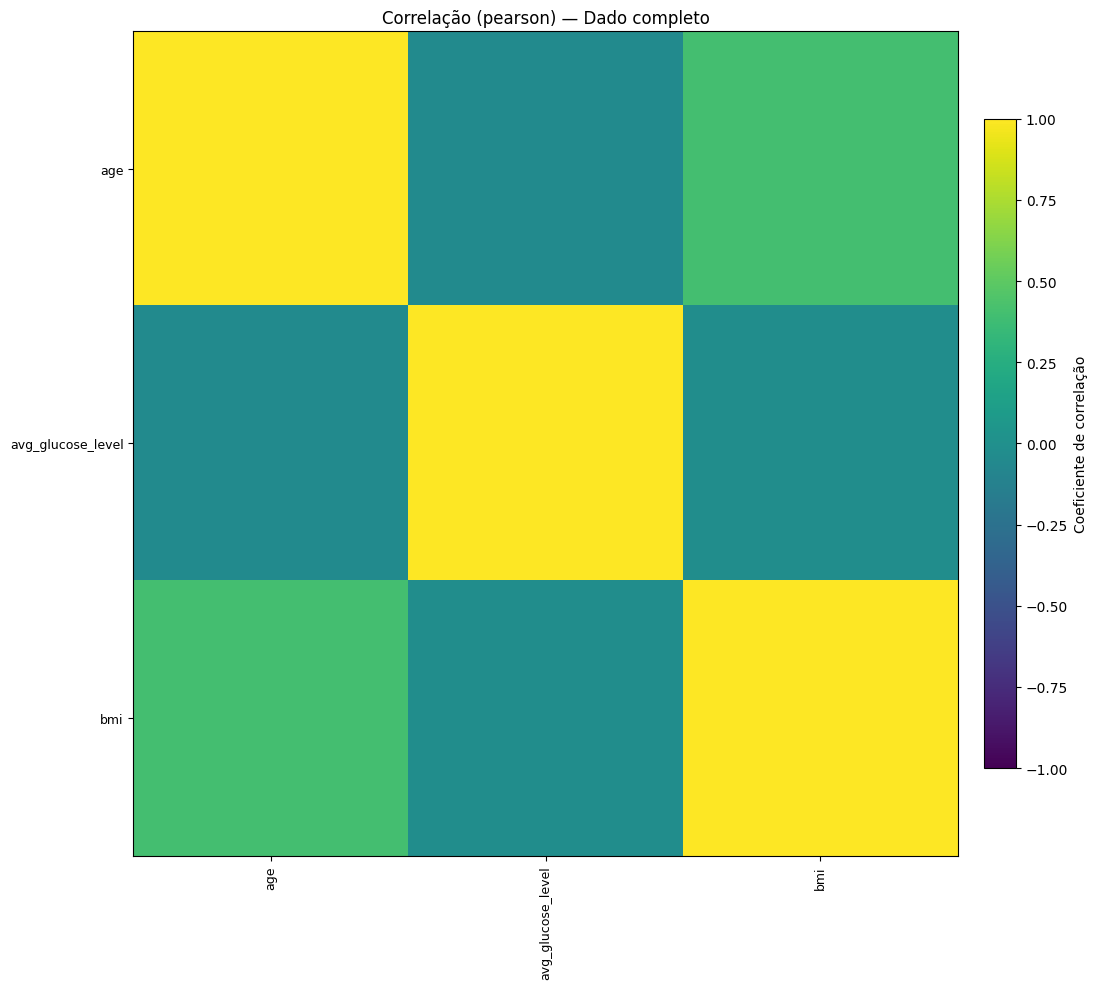

In [8]:
# ==== Heatmap de correlação: Dado completo (sem threshold) ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Parâmetros
CORR_METHOD = "pearson"   # 'pearson' ou 'spearman'
ANNOTATE = False          # True para escrever valores nas células (se poucas colunas)

def _drop_excluded(df: pd.DataFrame, excluded) -> pd.DataFrame:
    excluded = excluded if isinstance(excluded, (list, set, tuple)) else []
    return df.drop(columns=[c for c in excluded if c in df.columns], errors='ignore')

def _to_numeric_no_constant(df: pd.DataFrame) -> pd.DataFrame:
    df2 = df.copy()
    for c in df2.columns:
        if not pd.api.types.is_numeric_dtype(df2[c]):
            df2[c] = pd.to_numeric(df2[c], errors='coerce')
    df2 = df2.select_dtypes(include=[np.number])
    nun = df2.nunique(dropna=True)
    keep = nun[(nun > 1)].index
    return df2[keep]

def _corr(df: pd.DataFrame, method: str) -> pd.DataFrame:
    if df.shape[1] == 0:
        raise ValueError("Não há colunas numéricas não constantes para correlacionar.")
    return df.corr(method=method)

def _annotate_heatmap(ax, mat):
    n = mat.shape[0]
    for i in range(n):
        for j in range(n):
            v = mat[i, j]
            if not np.isfinite(v):
                continue
            txt = f"{v:.2f}"
            color = "white" if abs(v) > 0.5 else "black"
            ax.text(j, i, txt, ha="center", va="center", fontsize=6, color=color)

# --- Dado completo (use X para tudo; aqui mantido X_test por padrão) ---
SAFE_EXCLUDE = EXCLUDE_COLS if 'EXCLUDE_COLS' in globals() else []
X_full0 = _drop_excluded(X_test.copy(), SAFE_EXCLUDE)

X_full_num = _to_numeric_no_constant(X_full0)
C_full = _corr(X_full_num, CORR_METHOD)

cols = list(C_full.columns)

# Tamanho maior do heatmap
fig_w = max(14, 0.6*len(cols) + 10)
fig_h = max(10, 0.35*len(cols) + 4)

fig, ax = plt.subplots(1, 1, figsize=(fig_w, fig_h))
im = ax.imshow(C_full.values, vmin=-1, vmax=1, aspect='equal')

ax.set_title(f"Correlação ({CORR_METHOD}) — Dado completo")
ax.set_xticks(range(len(cols))); ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=90, fontsize=9)
ax.set_yticklabels(cols, fontsize=9)

if ANNOTATE and len(cols) <= 25:
    _annotate_heatmap(ax, C_full.values)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Coeficiente de correlação", rotation=90)

fig.tight_layout()

out_dir = PATH_FILE_OUT if 'PATH_FILE_OUT' in globals() else os.getcwd()
os.makedirs(out_dir, exist_ok=True)
fname = os.path.join(out_dir, "heatmap_correlacao_full.png")
plt.savefig(fname, dpi=300, bbox_inches='tight')
print(f"✅ Figura salva em: {fname}")

plt.show()


/tmp/ipykernel_105476/3997880825.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdBu_r').copy()


✅ Figura salva em: STROKE_PFI_RANDOM/heatmap_correlacao_threshold_full_pearson.png


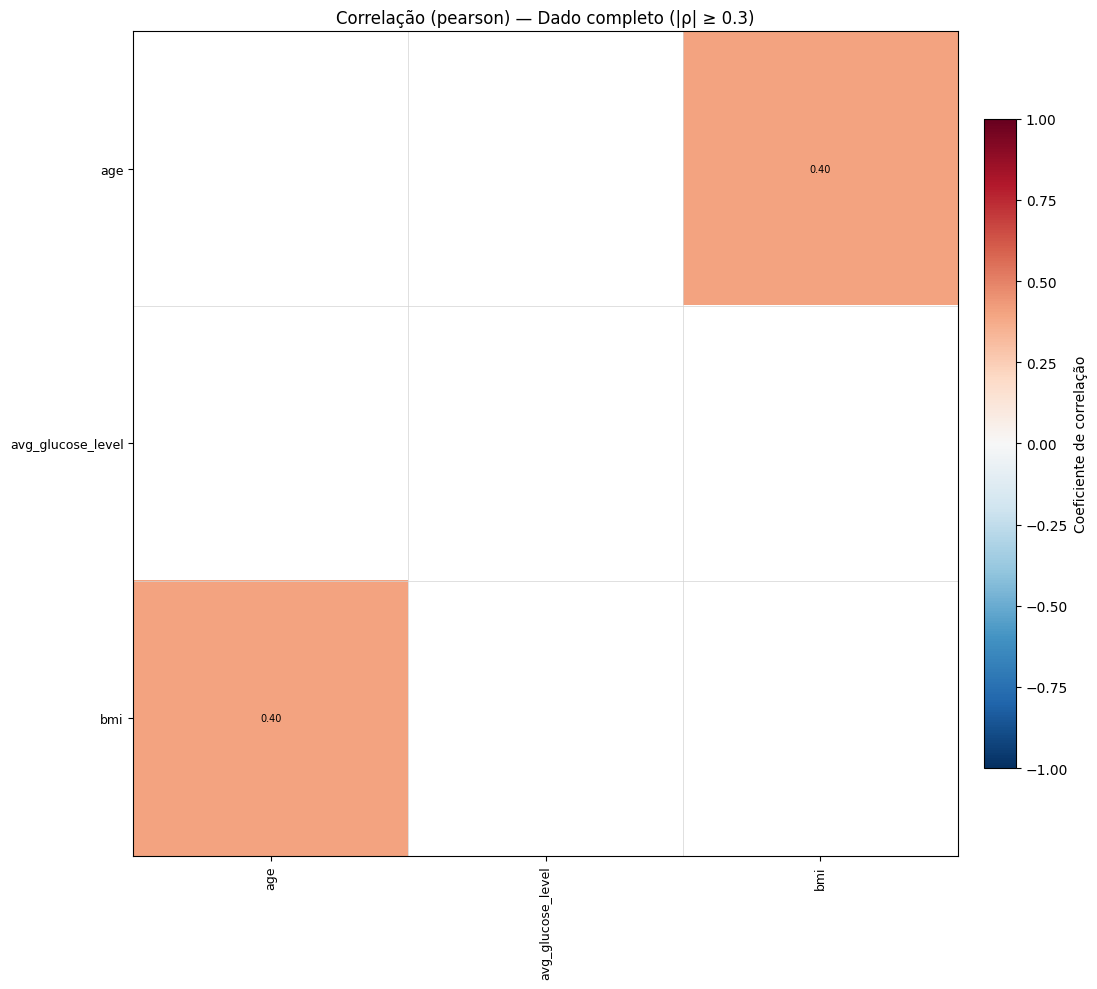

In [9]:
# ==== Heatmap de correlação (|ρ| ≥ 0.30): Dado completo ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Parâmetros
CORR_METHOD = "pearson"   # 'pearson' ou 'spearman'
THRESHOLD = 0.30

def _drop_excluded(df: pd.DataFrame, excluded) -> pd.DataFrame:
    excluded = excluded if isinstance(excluded, (list, set, tuple)) else []
    return df.drop(columns=[c for c in excluded if c in df.columns], errors='ignore')

def _to_numeric_no_constant(df: pd.DataFrame) -> pd.DataFrame:
    df2 = df.copy()
    for c in df2.columns:
        if not pd.api.types.is_numeric_dtype(df2[c]):
            df2[c] = pd.to_numeric(df2[c], errors='coerce')
    df2 = df2.select_dtypes(include=[np.number])
    nun = df2.nunique(dropna=True)
    keep = nun[(nun > 1)].index
    return df2[keep]

def _corr(df: pd.DataFrame, method: str) -> pd.DataFrame:
    if df.shape[1] == 0:
        raise ValueError("Não há colunas numéricas não constantes para correlacionar.")
    return df.corr(method=method)

def _render_heatmap_threshold(ax, C: pd.DataFrame, title: str, threshold: float, cmap):
    C = C.copy()
    n = C.shape[0]
    vals = C.values
    mask = (np.abs(vals) < threshold) | np.eye(n, dtype=bool) | ~np.isfinite(vals)
    M = np.ma.array(vals, mask=mask)

    im = ax.imshow(M, vmin=-1, vmax=1, cmap=cmap, aspect='equal', interpolation='nearest')
    ax.set_title(title)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(C.columns, rotation=90, fontsize=9)
    ax.set_yticklabels(C.index, fontsize=9)

    # anotações apenas onde passa do threshold
    for i in range(n):
        for j in range(n):
            if not mask[i, j]:
                val = vals[i, j]
                color = "white" if abs(val) >= 0.5 else "black"
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color=color)

    # grade discreta
    ax.set_xticks(np.arange(-.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n, 1), minor=True)
    ax.grid(which="minor", color="lightgray", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)
    return im

# --- Dado completo (use X para tudo; aqui mantido X_test por padrão) ---
SAFE_EXCLUDE = EXCLUDE_COLS if 'EXCLUDE_COLS' in globals() else []
X_full0 = _drop_excluded(X_test.copy(), SAFE_EXCLUDE)

X_full_num = _to_numeric_no_constant(X_full0)
C_full = _corr(X_full_num, CORR_METHOD)

cols = list(C_full.columns)

# Colormap com NaN/máscara em branco (robusto a versões)
try:
    cmap = plt.cm.get_cmap('RdBu_r').copy()
    cmap.set_bad(color='white')
except Exception:
    cmap = plt.cm.get_cmap('RdBu_r')
    try:
        cmap = cmap.with_extremes(bad='white')
    except Exception:
        try:
            cmap.set_bad(color='white')
        except Exception:
            pass

# Tamanho maior do heatmap
fig_w = max(14, 0.6*len(cols) + 10)
fig_h = max(10, 0.35*len(cols) + 4)

fig, ax = plt.subplots(1, 1, figsize=(fig_w, fig_h))
im = _render_heatmap_threshold(
    ax, C_full, f"Correlação ({CORR_METHOD}) — Dado completo (|ρ| ≥ {THRESHOLD})", THRESHOLD, cmap
)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Coeficiente de correlação", rotation=90)

fig.tight_layout()

out_dir = PATH_FILE_OUT if 'PATH_FILE_OUT' in globals() else os.getcwd()
os.makedirs(out_dir, exist_ok=True)
fname = os.path.join(out_dir, f"heatmap_correlacao_threshold_full_{CORR_METHOD}.png")
plt.savefig(fname, dpi=300, bbox_inches='tight')
print(f"✅ Figura salva em: {fname}")

plt.show()


In [10]:
# ===  Permutation Importance Interpretabilidade [Funções de Calculos das Métricas]===
# @title
from sklearn.inspection import permutation_importance
from sklearn.metrics import pairwise_distances
from sklearn.metrics import get_scorer
from itertools import combinations  # ✅ adicione isto antes da definição da função
from scipy.stats import spearmanr
import numpy as np
import pandas as pd
from sklearn.metrics import get_scorer
from joblib import parallel_backend
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
# ================================
# [GLOBAL] Configurações XAI (comuns a TODAS as métricas)
# ================================
METHOD            = "PERMUTATION"
SCORING           = "accuracy"      # 'accuracy' | 'neg_log_loss' | 'brier'
N_REPEATS         = 5              # repetições por (instância, feature)
K_NEIGHBORS_COND  = 0               # 0/1 = permutação marginal; >=2 = amostragem condicional k-NN
RANDOM_STATE      = 42
EPS               = 1e-12           # estabilidade numérica
PERC_LIST         = [0.01, 0.05, 0.10, 0.20]  # para Sufficiency PFI
INFID_OUTPUT      = "proba_true"    # 'proba_true' | 'proba_pred' | 'logit_true' | 'logit_pred'
# ================================
rng_global = np.random.default_rng(RANDOM_STATE)


def calcular_ic95_percentual(valores):
    # Média e desvio padrão
    media = np.mean(valores)
    std = np.std(valores, ddof=1)
    n = len(valores)
    # Erro padrão
    erro_padrao = std / np.sqrt(n)
    # IC 95% com distribuição normal (Z=1.96)
    ic_low = media - 1.96 * erro_padrao
    ic_high = media + 1.96 * erro_padrao
    return ic_low, ic_high

def calcular_ic95_percentual_median(valores):
    # Média e desvio padrão
    mediana = np.median(valores)
    std = np.std(valores, ddof=1)
    n = len(valores)
    # Erro padrão
    erro_padrao = std / np.sqrt(n)
    # IC 95% com distribuição normal (Z=1.96)
    ic_low = mediana - 1.96 * erro_padrao
    ic_high = mediana + 1.96 * erro_padrao
    return ic_low, ic_high

def formatar_ic_percentual(valor_central, limite_inferior, limite_superior):
    return f"{valor_central:.1f}% [{limite_inferior:.1f}%, {limite_superior:.1f}%]"

# import opcional, dependendo da versão do joblib
try:
    from joblib.externals.loky.process_executor import BrokenProcessPool
except Exception:
    class BrokenProcessPool(Exception):
        pass
    
# ================================
# Helpers
# ================================
def _ensure_row_df(x_row, cols):
    """Garante DataFrame (1xD) com colunas = cols."""
    if isinstance(x_row, pd.DataFrame):
        return x_row[cols].iloc[[0]]
    if isinstance(x_row, pd.Series):
        return pd.DataFrame([x_row.values], columns=cols)
    a = np.asarray(x_row, dtype=float).ravel()
    return pd.DataFrame([a], columns=cols)

def _predict_proba(model, X1row_df):
    """Retorna (proba, pred_label). lida com binário/multiclasse."""
    proba = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X1row_df)[0]  # (C,)
    yhat = model.predict(X1row_df)[0]
    return proba, yhat

def _loss_instance(y_true, proba, yhat, scoring, classes_):
    """
    Perda local por instância.
    - accuracy -> 0/1-loss = 0 se acertou; 1 se errou
    - neg_log_loss -> cross-entropy (usa prob da classe verdadeira)
    - brier -> Brier score (binário)
    """
    if scoring == "accuracy":
        return 0.0 if yhat == y_true else 1.0

    if scoring == "neg_log_loss":
        # achar índice da classe verdadeira
        if proba is None:
            # fallback: se não há predict_proba, usar 0/1-loss
            return 0.0 if yhat == y_true else 1.0
        # classes_ garante o alinhamento das colunas de predict_proba
        pos = np.where(classes_ == y_true)[0][0]
        p = np.clip(proba[pos], EPS, 1.0 - EPS)
        return -np.log(p)

    if scoring == "brier":
        # suportado plenamente para binário; para multi-classes vira 0/1-loss
        if proba is None or len(classes_) != 2:
            return 0.0 if yhat == y_true else 1.0
        pos = np.where(classes_ == y_true)[0][0]
        p = np.clip(proba[pos], 0.0, 1.0)
        y_bin = 1.0  # classe verdadeira
        return (p - y_bin) ** 2

    # fallback geral
    return 0.0 if yhat == y_true else 1.0

def _sample_conditional_z(j_col, x_i_1row, X_ref, k_neighbors, scaler_cache):
    """
    Amostra z (valor para a feature j) de forma:
      - marginal (se k_neighbors < 2)
      - condicional por vizinhança k-NN (se k_neighbors >= 2)
    """
        # Forçar a conversão para int, caso esteja vindo como tupla por engano
    #try:
    #    kn_int = int(k_neighbors)
    #except (ValueError, TypeError):
        # Se a conversão falhar, logue o erro e use um fallback seguro
    #    kn_int = 0 # Fallback para método marginal (seguro)
    #k_neighbors = kn_int
    if k_neighbors is None or k_neighbors < 2:
        # marginal: uma posição aleatória da coluna j em X_ref
        ridx = rng_global.integers(low=0, high=len(X_ref))
        return X_ref.iloc[ridx, j_col]

    # condicional k-NN no espaço de todas as features numéricas
    # cache de scaler & NN por performance
    if "nn" not in scaler_cache:
        scaler = StandardScaler(with_mean=True, with_std=True)
        Xref_scaled = scaler.fit_transform(X_ref.values)
        nn = NearestNeighbors(n_neighbors=min(k_neighbors, len(X_ref)), metric="euclidean")
        nn.fit(Xref_scaled)
        scaler_cache["scaler"] = scaler
        scaler_cache["Xref_scaled"] = Xref_scaled
        scaler_cache["nn"] = nn
    else:
        scaler = scaler_cache["scaler"]
        nn = scaler_cache["nn"]

    xi_scaled = scaler.transform(x_i_1row.values)
    neigh_dist, neigh_idx = nn.kneighbors(xi_scaled, return_distance=True)
    neigh_idx = neigh_idx[0]
    ridx = rng_global.choice(neigh_idx)
    return X_ref.iloc[ridx, j_col]

def compute_fidelity_pfi_instance(
    model, X, y, idx_instancia, X_ref=None, scoring="accuracy",
    n_repeats=30, k_neighbors=0, feat_subset=None, DEBUG=True
):
    """
    PFI 'local' por instância (id de índice): permuta uma feature de cada vez em x_i,
    calcula perda (L) e mede variação Δ = E[L_perm] - L_base.
    Retorna detalhes por feature e um resumo agregado para a instância.
    """
    if X_ref is None:
        X_ref = X

    # --- valida o ID/rótulo no índice
    if X[X['id'] == idx_instancia].empty:
        raise KeyError(f"ID '{idx_instancia}' não encontrado em X.id.")

    # --- pegue 1xD preservando o rótulo no índice
    x_i =  X[X['id'] == idx_instancia].copy()   # mantém o label no índice
    x_i =  x_i.drop(columns=EXCLUDE_COLS, errors='ignore')
    y_i =  X[X['id'] == idx_instancia]['y'].values[0]

    X = X.drop(columns=EXCLUDE_COLS, errors='ignore')

    # --- valida colunas
    cols = X.columns if feat_subset is None else list(feat_subset)
    pos_map = X.columns.get_indexer(cols)
    if (pos_map < 0).any():
        missing = [c for c, p in zip(cols, pos_map) if p < 0]
        raise ValueError(f"Colunas ausentes em X: {missing}")

    # --- (opcional) checa ordem esperada do modelo
    try:
        feat_in = list(getattr(model, "feature_names_in_", []))
        if feat_in:
            if list(X.columns) != feat_in:
                #if DEBUG:
                #    print("[WARN] Reordenando X/X_ref para feature_names_in_ do modelo.")
                X = X.loc[:, feat_in]
                X_ref = X_ref.loc[:, feat_in]
            cols = [c for c in cols if c in feat_in]
    except Exception:
        pass

    classes_ = getattr(model, "classes_", None)
    if classes_ is None:
        classes_ = np.unique(y.values)

    # --- perda base
    proba0, yhat0 = _predict_proba(model, x_i)
    loss_base = _loss_instance(y_i, proba0, yhat0, scoring, classes_)

    #if DEBUG:
    #    print("\n========== PFI-LOCAL DEBUG ==========")
    #    print(f"ID alvo: {idx_instancia}")
    #   print(f"X.shape={X.shape} | X_ref.shape={X_ref.shape}")
    #    print(f"n_repeats={n_repeats} | k_neighbors={k_neighbors} | scoring='{scoring}'")
    #    print(f"loss_base={loss_base}")
    #    print(f"cols usadas ({len(cols)}): {cols[:8]}{'...' if len(cols)>8 else ''}")

    details = []
    scaler_cache = {}
    dbg_rows = []

    for j_name in cols:
        j_col = X.columns.get_loc(j_name)
        losses_perm = []
        equal_z_count = 0

        orig_val = x_i.iat[0, j_col]

        for _ in range(n_repeats):
            # === amostra z e evita cair sistematicamente no mesmo valor ===
            # tenta até 5 vezes obter um z diferente do original (quando possível)
            z = None
            for _tries in range(5):
                z = _sample_conditional_z(j_col, x_i, X_ref, k_neighbors, scaler_cache)
                # considera "igual" mesmo tipo + valor; para NaN, aceita diferente
                if not ((pd.isna(z) and pd.isna(orig_val)) or z == orig_val):
                    break
            if (pd.isna(z) and pd.isna(orig_val)) or z == orig_val:
                equal_z_count += 1  # ainda caiu igual (provável coluna quase/totalmente constante)

            x_prime = x_i.copy()
            # atribuição POSICIONAL (evita mismatch de rótulo)
            x_prime.iat[0, j_col] = z

            proba_p, yhat_p = _predict_proba(model, x_prime)
            loss_p = _loss_instance(y_i, proba_p, yhat_p, scoring, classes_)
            losses_perm.append(loss_p)

        loss_perm_mean = float(np.mean(losses_perm)) if len(losses_perm) else loss_base
        delta = loss_perm_mean - loss_base
        ratio = (loss_perm_mean + EPS) / (loss_base + EPS)

        # percentual 0..1 (MAIOR=melhor)
        fid_percent = float(np.clip(1.0 - delta, 0.0, 1.0))

        details.append({
            "instancia": idx_instancia,           # guarda o ID (rótulo)
            "feature": j_name,
            "loss_base": loss_base,
            "loss_perm_mean": loss_perm_mean,
            "variation_abs": delta,
            "ratio": ratio,
            "fidelity_percent": fid_percent,
            "n_repeats": n_repeats,
            "scoring": scoring,
            "k_neighbors": k_neighbors,
            "equal_z_count": int(equal_z_count)
        })

        if DEBUG and (equal_z_count > 0 or n_repeats <= 5):
            dbg_rows.append((j_name, equal_z_count, loss_perm_mean, delta))

    df_details = pd.DataFrame(details).sort_values(by="variation_abs", ascending=False)

    agg = {
        "instancia": idx_instancia,
        "loss_base": loss_base,
        "variation_abs_mean": float(df_details["variation_abs"].mean()),
        "variation_abs_std":  float(df_details["variation_abs"].std(ddof=1) if len(df_details) > 1 else 0.0),
        "ratio_mean":         float(df_details["ratio"].mean()),
        "ratio_std":          float(df_details["ratio"].std(ddof=1) if len(df_details) > 1 else 0.0),
        "fidelity_percent_mean": float(df_details["fidelity_percent"].mean()),
        "fidelity_percent_std":  float(df_details["fidelity_percent"].std(ddof=1) if len(df_details) > 1 else 0.0),
        "n_features": len(df_details),
        "n_repeats": n_repeats,
        "scoring": scoring,
        "k_neighbors": k_neighbors
    }
    df_summary = pd.DataFrame([agg])

    #if DEBUG:
    #    print("\n--- Resumo por feature (apenas com z==orig em alguma repetição OU com poucos repeats) ---")
    #    for (f, eqc, lmean, dlt) in dbg_rows[:20]:
    ##        print(f"feat={f:>20s} | equal_z={eqc:>3d}/{n_repeats} | loss_perm_mean={lmean:.6f} | delta={dlt:.6f}")
    #    print("fidelity_percent_mean:", f"{df_summary['fidelity_percent_mean'].iloc[0]:.6f}")
    #    print("======================================\n")

    return {
        "summary": df_summary,
        "details": df_details,
        "loss_base": loss_base
    }

## == Infidelity =============================

# ============================
# Config global específica da Infidelity
# ============================
# Escalar de saída a usar em f(x): 'proba_true' | 'proba_pred' | 'logit_true' | 'logit_pred'
INFID_OUTPUT = "proba_true"
TAU = 1e-8   # evita divisão por zero em diferenças finitas

def _score_output(model, X1row_df, y_i, output_mode: str):
    """
    Retorna s(x) como escalar, conforme 'output_mode'.
    - proba_true: probabilidade da classe verdadeira
    - proba_pred: probabilidade da classe prevista
    - logit_*   : logit da probabilidade correspondente (binário ou 1-vs-rest)
    Fallbacks seguros se o modelo não tiver predict_proba/decision_function.
    """
    # Probabilidades (se disponíveis)
    proba = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X1row_df)[0]  # (C,)

    # Classe prevista / verdadeira e mapeamentos
    yhat = model.predict(X1row_df)[0]
    if proba is not None:
        classes_ = getattr(model, "classes_", None)
        if classes_ is None:
            classes_ = np.arange(len(proba))
        # índice da classe alvo
        if "true" in output_mode:
            target = y_i if y_i in classes_ else yhat
        else:
            target = yhat
        pos = int(np.where(classes_ == target)[0][0])

        if output_mode.startswith("proba"):
            return float(np.clip(proba[pos], TAU, 1.0 - TAU))

        # logit
        p = float(np.clip(proba[pos], TAU, 1.0 - TAU))
        return float(np.log(p / (1.0 - p)))

    # Sem predict_proba: tenta decision_function
    if hasattr(model, "decision_function"):
        df = model.decision_function(X1row_df)
        # binário -> escalar; multiclasse -> pega margem da classe prevista
        if np.ndim(df) == 0:
            return float(df)
        if np.ndim(df) == 1:
            return float(df[0 if "true" not in output_mode else (0 if y_i == yhat else 0)])
        # multiclasse (ovo): pega componente da classe prevista
        # (heurística simples; se quiser, mapeie por classes_)
        return float(df[np.argmax(df)])

    # Fallback final: 1.0 para classe prevista, 0.0 caso contrário
    return float(1.0 if (("true" in output_mode and yhat == y_i) or ("pred" in output_mode)) else 0.0)

def compute_infidelity_bybook_pfi_instance(
    model,
    X, y,
    idx_instancia,
    X_ref=None,
    feat_subset=None,
    output_mode=INFID_OUTPUT,
    n_repeats_phi=30,      # amostras para estimar φ_j(x)
    n_trials=50,           # amostras de máscaras I
    group_size=1,          # nº de features perturbadas por trial
    k_neighbors=0,         # 0/1=marginal; >=2=condicional k-NN
    random_state=42
):
    """
    Infidelity_i(Φ,f,x) = E_I [( I^T Φ(x) - ( s(x) - s(x - I) ) )^2 ],
    onde s(·) é um escalar de saída do modelo (prob/logit da classe-alvo).

    - Φ(x): vetor com φ_j(x) estimado por diferenças finitas:
        φ_j(x) ≈ E_z [ (s(x) - s(x^{(j<-z)})) / (x_j - z) ].
    - I: vetor de perturbação, com I_j = x_j - z_j (0 se j não foi escolhido no trial).
    - E_I[·]: média sobre 'n_trials' amostras de subsets (tamanho 'group_size') e draws z_j.
    """
    rng = np.random.default_rng(random_state)
    if X_ref is None:
        X_ref = X
    
    # --- valida o ID/rótulo no índice
    if X[X['id'] == idx_instancia].empty:
        raise KeyError(f"ID '{idx_instancia}' não encontrado em X.id.")

    # --- pegue 1xD preservando o rótulo no índice
    x_i =  X[X['id'] == idx_instancia].copy()   # mantém o label no índice
    x_i =  x_i.drop(columns=EXCLUDE_COLS, errors='ignore')
    y_i =  X[X['id'] == idx_instancia]['y'].values[0]

    X = X.drop(columns=EXCLUDE_COLS, errors='ignore')

    # Instância-alvo
    #x_i = _ensure_row_df(X.iloc[int(idx_instancia)], X.columns)
    #y_i = y.iloc[int(idx_instancia)]


    if feat_subset is None:
        feat_subset = list(X.columns)



    # s(x) base
    s_base = _score_output(model, x_i, y_i, output_mode)

    # ————— Estima φ_j(x) para todas as features (diferenças finitas) —————
    phi = {}
    scaler_cache = {}
    for j_name in feat_subset:
        j_col = X.columns.get_loc(j_name)
        acc = []
        for r in range(n_repeats_phi):
            z = _sample_conditional_z(j_col, x_i, X_ref, k_neighbors, scaler_cache)
            delta = float(x_i.iat[0, j_col] - z)
            # se delta muito pequeno, tente novo draw
            if abs(delta) < TAU:
                continue
            x_prime = x_i.copy()
            x_prime.iat[0, j_col] = z
            s_prime = _score_output(model, x_prime, y_i, output_mode)
            acc.append((s_base - s_prime) / delta)
        # média dos quocientes; se vazio (p.ex., feature constante), zera
        phi[j_name] = float(np.mean(acc)) if len(acc) else 0.0

    # ————— Monte Carlo sobre I (subsets de tamanho group_size) —————
    n_feat = len(feat_subset)
    g = int(max(1, min(group_size, n_feat)))
    trials = []
    for t in range(n_trials):
        S = rng.choice(feat_subset, size=g, replace=False)
        # constrói I e x' simultaneamente
        x_prime = x_i.copy()
        I_vals = {}
        for ftr in S:
            j_col = X.columns.get_loc(ftr)
            z = _sample_conditional_z(j_col, x_i, X_ref, k_neighbors, scaler_cache)
            I_vals[ftr] = float(x_i.iat[0, j_col] - z)   # I_j = x_j - z
            x_prime.iat[0, j_col] = z                    # x - I: troca por z

        # I^T Φ(x): soma dos produtos I_j * φ_j(x) nas features escolhidas
        pred_change = float(sum(I_vals[f]*phi.get(f, 0.0) for f in S))

        # variação real s(x) - s(x - I)
        s_prime = _score_output(model, x_prime, y_i, output_mode)
        real_change = float(s_base - s_prime)

        se = float((pred_change - real_change)**2)
        trials.append({
            "instancia": int(idx_instancia),
            "trial": t,
            "features_mask": ",".join(map(str, S)),
            "pred_change_I_phi": pred_change,
            "real_change": real_change,
            "squared_error": se
        })

    df_trials = pd.DataFrame(trials)
    infidelity = float(df_trials["squared_error"].mean()) if len(df_trials) else 0.0
    fidelity_from_infidelity = float(1.0 / (1.0 + infidelity))

    summary = pd.DataFrame([{
        "instancia": int(idx_instancia),
        "infidelity": infidelity,
        "fidelity_from_infidelity": fidelity_from_infidelity,
        "s_base": s_base,
        "n_trials": n_trials,
        "group_size": g,
        "k_neighbors": k_neighbors,
        "output_mode": output_mode
    }])

    return {"summary": summary, "details": df_trials, "phi": pd.Series(phi)}


TAU = 1e-8  # tolerância p/ evitar divisão por ~0

def compute_faithfulness_corr_pfi_instance(
    model,
    X, y,
    idx_instancia,                 # <- agora é ID/rótulo do índice
    X_ref=None,
    feat_subset=None,
    output_mode="proba_true",      # 'proba_true'|'proba_pred'|'logit_true'|'logit_pred'
    n_repeats=30,                  # draws z por feature
    k_neighbors=0,                 # 0/1=marginal; >=2=condicional k-NN
    corr="spearman",               # 'pearson'|'spearman'|'kendall'
    random_state=42
):
    """
    Faithfulness(Φ,f,x) = corr({φ_j(x)}_j, {E_z[s(x) - s(x^{(j<-z)})]}_j)
    — por instância (x = X.loc[idx_instancia]).
    Requer TAU definido no escopo global para descartar deltas ~0.
    """
    rng = np.random.default_rng(random_state)
    if X_ref is None:
        X_ref = X


    # --- valida o ID/rótulo no índice
    if X[X['id'] == idx_instancia].empty:
        raise KeyError(f"ID '{idx_instancia}' não encontrado em X.id.")
    # --- pegue 1xD preservando o rótulo no índice
    x_i =  X[X['id'] == idx_instancia].copy()   # mantém o label no índice
    x_i =  x_i.drop(columns=EXCLUDE_COLS, errors='ignore')
    y_i =  X[X['id'] == idx_instancia]['y'].values[0]

    X = X.drop(columns=EXCLUDE_COLS, errors='ignore')

    if feat_subset is None:
        feat_subset = list(X.columns)
    # --- validações mínimas
    # checa colunas
    miss = [c for c in feat_subset if c not in X.columns]
    if miss:
        raise ValueError(f"Colunas ausentes em X: {miss}")

    # score base s(x)
    s_base = _score_output(model, x_i, y_i, output_mode)

    scaler_cache = {}
    phi_vals, impact_vals, deltas_mean = [], [], []

    for j_name in feat_subset:
        j_col = X.columns.get_loc(j_name)  # ainda ok usar posicional para _amostra condicional_
        qs, reals, deltas = [], [], []

        for _ in range(n_repeats):
            z = _sample_conditional_z(j_col, x_i, X_ref, k_neighbors, scaler_cache)
            # delta no espaço da feature j (label-based)
            current_index_label = x_i.index[0] 
            # Use o rótulo do índice correto para acessar e modificar os dados
            d = float(x_i.at[current_index_label, j_name] - z)
            #d = float(x_i.at[idx_instancia, j_name] - z)
            if 'TAU' in globals():
                if abs(d) < TAU:
                    continue
            x_prime = x_i.copy()
            x_prime.at[current_index_label, j_name] = z   # substituição por rótulo+coluna

            s_prime = _score_output(model, x_prime, y_i, output_mode)
            # impacto real e quociente p/ φ_j
            reals.append(s_base - s_prime)
            qs.append((s_base - s_prime) / d)
            deltas.append(d)
        # estatísticas por feature (se não houver draws válidos, zera)
        phi_j    = float(np.mean(qs))     if len(qs)     else 0.0
        impact_j = float(np.mean(reals))  if len(reals)  else 0.0
        dmean_j  = float(np.mean(deltas)) if len(deltas) else 0.0
        phi_vals.append(phi_j)
        impact_vals.append(impact_j)
        deltas_mean.append(dmean_j)
    s_phi    = pd.Series(phi_vals,    index=feat_subset, name="phi")
    s_impact = pd.Series(impact_vals, index=feat_subset, name="impact")
    s_dmean  = pd.Series(deltas_mean, index=feat_subset, name="delta_mean")
    # correlação (se vetor constante, retorna NaN)
    if s_phi.nunique() <= 1 or s_impact.nunique() <= 1:
        rho = np.nan
    else:
        rho = float(s_phi.corr(s_impact, method=corr))
    summary = pd.DataFrame([{
        "instancia": idx_instancia,       # mantém o rótulo/ID
        "faithfulness_corr": rho,
        "corr_method": corr,
        "output_mode": output_mode,
        "n_repeats": n_repeats,
        "k_neighbors": k_neighbors,
        "n_features": len(feat_subset)
    }])
    details = pd.concat([s_phi, s_impact, s_dmean], axis=1).reset_index() \
                 .rename(columns={"index": "feature"})

    return {"summary": summary, "details": details}

def compute_simplicity_pfi_instance(
    idx_instancia,
    pfi_details=None,        # df 'details' do compute_fidelity_pfi_instance (mesma instância)
    model=None, X=None, y=None, X_ref=None,   # só necessários se pfi_details for None
    feat_subset=None,
    scoring=None,
    n_repeats=None,
    k_neighbors=None,
    tau=0.05,                # aceita 0.05 (5%) ou 5 (5)
    positive_only=True       # usa max(Δ,0)
):
    """
    Complexity_PFI(x): k_tau = #{ j : p_j > tau } com p_j = Δ_j^+ / sum Δ_k^+
    Simplicity_PFI(x) = 1 - k_tau / d̄
    Retorna summary (uma linha) e details (por feature).
    """
    EPS = 1e-12
    # Caso não tenha sido passado o 'details', calcula agora
    if pfi_details is None:
        if any(v is None for v in (model, X, y)):
            raise ValueError("Passe pfi_details ou (model, X, y) para calcular as variações.")
        tmp = compute_fidelity_pfi_instance(
            model=model,
            X=X,
            y=y,
            idx_instancia=idx_instancia,  # <<< NÃO converta para int; preserve o rótulo (loc)
            X_ref=(X_ref if X_ref is not None else X),
            scoring=(scoring if scoring is not None else SCORING),
            n_repeats=(n_repeats if n_repeats is not None else N_REPEATS),
            k_neighbors=(k_neighbors if k_neighbors is not None else K_NEIGHBORS_COND),
            feat_subset=feat_subset,
            DEBUG=False
        )
        pfi_details = tmp["details"]

    df = pfi_details.copy()
    if feat_subset is not None:
        df = df[df["feature"].isin(feat_subset)].copy()

    # Importância por feature: variação de perda (Δ). Usa apenas parte positiva (PFI não-negativo).
    vals = df["variation_abs"].astype(float).to_numpy()
    if positive_only:
        vals = np.maximum(vals, 0.0)

    d_bar = len(vals)
    if d_bar == 0:
        raise ValueError("Nenhuma feature disponível para simplicidade PFI.")

    l1_sum = float(vals.sum() + EPS)
    p_frac = vals / l1_sum               # fração de importância por feature

    tau_eff = float(tau)
    if tau_eff > 1.0:                    # aceita 5 => 0.05
        tau_eff = tau_eff / 100.0

    above = p_frac > tau_eff
    complexity_k   = int(above.sum())
    complexity_pct = 100.0 * complexity_k / d_bar
    simplicity_abs = 1.0 - (complexity_k / d_bar)
    simplicity_pct = 100.0 * simplicity_abs

    details = df.assign(
        pfi_importance=vals,
        p_mass=p_frac,
        above_tau_pct=above
    ).sort_values("p_mass", ascending=False).reset_index(drop=True)

    summary = pd.DataFrame([{
        "instancia": idx_instancia,                 # <<< mantém o rótulo original
        "complexity_k": complexity_k,
        "complexity_percent": float(f"{complexity_pct:.3f}"),
        "simplicity_abs": float(f"{simplicity_abs:.8f}"),
        "simplicity_percent": float(f"{simplicity_pct:.3f}"),
        "tau_input": float(tau),
        "tau_eff_fraction": float(tau_eff),
        "norm_kind": "pfi_loss_pct",
        "positive_only": bool(positive_only),
        "d_bar": int(d_bar)
    }])

    return {"summary": summary, "details": details}

# ================================
# Consistency para PFI (por instância)
# ================================
def compute_consistency_pfi_instance(
    model,
    X, y,
    idx_instancia,
    X_ref=None,
    feat_subset=None,
    scoring=None,              # usa seu SCORING global se None
    n_repeats=None,            # usa seu N_REPEATS global se None
    k_neighbors=None,          # usa seu K_NEIGHBORS_COND global se None
    R=10,                      # nº de runs (repetições do PFI local)
    corr="spearman",           # 'spearman' | 'kendall' | 'pearson'
    rank_by="abs",             # 'abs' (default) | 'raw'
    random_state=42
):
    """
    Consistency(x) = (2 / (R*(R-1))) * sum_{r1<r2} rho( Φ^(r1)(x), Φ^(r2)(x) )
    onde Φ^(r)(x) é o vetor de importâncias locais PFI (Δ de perda por feature)
    obtido no run r para a MESMA instância x.

    Acesso por ID (loc): idx_instancia deve ser um rótulo existente em X.index e y.index.
    MAIOR = melhor.
    """
    from scipy.stats import spearmanr, kendalltau, pearsonr

    # --- valida ID por rótulo
    if X[X['id'] == idx_instancia].empty:
        raise KeyError(f"ID '{idx_instancia}' não encontrado em X.id.")

    # defaults globais do seu pipeline
    if scoring is None:      scoring = SCORING
    if n_repeats is None:    n_repeats = N_REPEATS
    if k_neighbors is None:  k_neighbors = K_NEIGHBORS_COND
    if X_ref is None:        X_ref = X
    if feat_subset is None:  feat_subset = list(X.columns)

    # Preparar gerador para sementes por run
    base_rs = np.random.RandomState(random_state)

    # Coleta dos vetores Φ^(r)(x) = Δ de perda por feature (ordem = feat_subset)
    V = []      # (R, d)
    for r in range(int(R)):
        # controlar aleatoriedade do sampling de z dentro do compute_fidelity_pfi_instance
        #try:
        #    global rng_global
        #    rng_global = np.random.default_rng(int(base_rs.randint(0, 2**31-1)))
        #except NameError:
        #    pass

        res_r = compute_fidelity_pfi_instance(
            model=model,
            X=X,
            y=y,
            idx_instancia=idx_instancia,     # <<< usa rótulo, sem int()
            X_ref=X_ref,
            scoring=scoring,
            n_repeats=n_repeats,
            k_neighbors=k_neighbors,
            feat_subset=feat_subset
        )
        det = res_r["details"]  # tem 'feature' e 'variation_abs'

        # alinhar na ordem de feat_subset
        phi_r = det.set_index("feature")["variation_abs"].reindex(feat_subset).fillna(0.0).to_numpy()

        if str(rank_by).lower() == "abs":
            phi_r = np.abs(phi_r)

        V.append(phi_r)

    V = np.vstack(V)  # (R, d)

    # Correlação entre todos os pares (r1 < r2)
    rhos = []
    for i in range(R):
        for j in range(i+1, R):
            u, v = V[i], V[j]
            # se vetor for (quase) constante, define correlação 1 se iguais, senão 0
            if np.allclose(u, u[0]) or np.allclose(v, v[0]):
                rho = 1.0 if np.allclose(u, v) else 0.0
            else:
                if corr == "kendall":
                    rho, _ = kendalltau(u, v, variant="b")
                elif corr == "pearson":
                    rho, _ = pearsonr(u, v)
                else:  # spearman (padrão)
                    rho, _ = spearmanr(u, v)
                if not np.isfinite(rho):
                    rho = 1.0 if np.allclose(u, v) else 0.0
            rhos.append(float(rho))

    rhos = np.asarray(rhos, dtype=float)
    rho_mean = float(np.mean(rhos)) if rhos.size else 1.0
    rho_std  = float(np.std(rhos))  if rhos.size else 0.0
    rho_min  = float(np.min(rhos))  if rhos.size else 1.0
    rho_max  = float(np.max(rhos))  if rhos.size else 1.0

    # Mapeia de [-1,1] para [0,1] e para %
    consistency_abs = float(np.clip((rho_mean + 1.0) / 2.0, 0.0, 1.0))
    consistency_percent = float(f"{consistency_abs * 100.0:.3f}")  # MAIOR = melhor

    # Summary (1 linha) + details (matriz de Φ e correlações por par)
    summary = pd.DataFrame([{
        "instancia": idx_instancia,                # <<< mantém rótulo original
        "consistency_abs": consistency_abs,        # 0..1 (MAIOR = melhor)
        "consistency_percent": consistency_percent,# 0..100 (MAIOR = melhor)
        "rho_mean": rho_mean,
        "rho_std": rho_std,
        "rho_min": rho_min,
        "rho_max": rho_max,
        "R": int(R),
        "pairs": int(R*(R-1)//2),
        "corr_method": corr,
        "rank_by": str(rank_by).lower(),
        "scoring": scoring,
        "n_repeats": int(n_repeats),
        "k_neighbors": int(k_neighbors)
    }])

    # details “longo” (run x feature) e pares de correlação
    df_phi = (
        pd.DataFrame(V, columns=feat_subset)
        .assign(run=np.arange(R))
        .melt(id_vars="run", var_name="feature", value_name="phi_value")
        .sort_values(["run","phi_value"], ascending=[True, False])
        .reset_index(drop=True)
    )
    pair_rows = []
    k = 0
    for i in range(R):
        for j in range(i+1, R):
            pair_rows.append({"r1": i, "r2": j, "rho": rhos[k]})
            k += 1
    df_pairs = pd.DataFrame(pair_rows)

    details = {"phi_runs_long": df_phi, "pairwise_corrs": df_pairs}
    return {"summary": summary, "details": details}


def compute_robustness_pfi_instance(
    model,
    X, y,
    idx_instancia,                 # rótulo em X.index / y.index (loc)
    X_ref: pd.DataFrame,           # para bounds e amostragem condicional
    drop_cols=('classe','y'),
    n_trials: int = 200,
    epsilon: float = 0.05,
    epsilon_mode: str = "relative_range",   # 'relative_range' | 'absolute'
    norm: str = "l2",                        # 'l2' | 'l1'
    strategy: str = "all",                   # 'all' | 'one' (perturbar 1 feature por trial)
    features_to_test=None,                   # colunas a perturbar (None=todas efetivas)
    cat_flip_prob: float = 0.10,
    random_state: int = 42,
    # opções PFI local (mantém globais coerentes)
    scoring=None,
    n_repeats=None,
    k_neighbors=None,
    feat_subset=None,                        # colunas usadas em Φ (None=todas efetivas)
    # métricas derivadas (mesmo estilo dos seus códigos)
    topk_delta: int = 8,
    score_mode: str = "relative",            # 'relative' | 'cosine' | 'exp'
    score_alpha: float = None,               # só p/ 'exp'
    # --------- DEBUG ----------
    DEBUG: bool = False
):
    """
    Robustness_PFI(x) = max_{||x'−x||<ε} || Φ(x) − Φ(x') ||, com Φ = vetor de Δ(perda) por feature.
    Retorna: robust_max, robust_mean, robust_std, details(dict).

    Acesso por rótulo (loc): idx_instancia deve existir em X.index e y.index.
    - robust_score: MAIOR = mais robusto (melhor)
    - robust_max/mean/std (distâncias): MENORES = melhores (menos variação sob perturbação)
    """
    rng = np.random.default_rng(random_state)
    # ===== valida rótulo =====
    if X[X['id'] == idx_instancia].empty:
        raise KeyError(f"ID '{idx_instancia}' não encontrado em X.id.")
    # ===== colunas efetivas e subset =====
    feat_cols_eff = [c for c in X_ref.columns if c not in set(drop_cols)]
    if feat_subset is None:
        feat_subset = feat_cols_eff

    # ===== instância x e target (por rótulo/loc) =====
    # já restringe às colunas efetivas para manter alinhamento por nome
    x_row_df = X[X['id'] == idx_instancia].loc[:, feat_cols_eff].copy()
    #y_i = y.loc[idx_instancia]
    
    # ===== parâmetros PFI (usa globais se None) =====
    if scoring is None:     scoring = SCORING
    if n_repeats is None:   n_repeats = N_REPEATS
    if k_neighbors is None: k_neighbors = K_NEIGHBORS_COND
    
    #print(f'Valor passado do SCORING é: {scoring}')
    #print(f'Valor passado do N_REPEATS é: {n_repeats}')
    #print(f'Valor passado do K_NEIGHBORS_COND é: {k_neighbors}')
    #print('--------------------------------------------------------------------')
    #print('--------------------------------------------------------------------')
    #print('--------------------------------------------------------------------')
    # ===== Φ(x): PFI local base =====
    base = compute_fidelity_pfi_instance(
        model=model, X=X, y=y, idx_instancia=idx_instancia,
        X_ref=X_ref, scoring=scoring, n_repeats=n_repeats,
        k_neighbors=k_neighbors, feat_subset=feat_subset
    )
    det0 = base["details"]  # tem 'feature' e 'variation_abs'
    phi0 = det0.set_index("feature")["variation_abs"].reindex(feat_subset).fillna(0.0).to_numpy()

    # ===== preparar tipos/bounds p/ perturbar =====
    num_idx, cat_idx = [], []
    for j, c in enumerate(feat_cols_eff):
        if pd.api.types.is_numeric_dtype(X_ref[c]):
            num_idx.append(j)
        else:
            cat_idx.append(j)

    bounds = {}
    for j in num_idx:
        col = feat_cols_eff[j]
        v = X_ref[col].to_numpy()
        bounds[j] = (float(np.nanmin(v)), float(np.nanmax(v)))

    # utilitário de perturbação x -> x' (opera por NOME de coluna)
    def _perturb_row(x1: pd.DataFrame) -> pd.DataFrame:
        xprime = x1.copy()
        targets = list(features_to_test) if features_to_test else list(feat_cols_eff)
        if strategy == "one" and targets:
            targets = [rng.choice(targets)]
        current_index_label = x1.index[0] 
        # numéricas
        for col in [c for c in targets if c in feat_cols_eff and pd.api.types.is_numeric_dtype(X_ref[c])]:
            j = feat_cols_eff.index(col)
            # Substitua todas as ocorrências de idx_instancia por current_index_label
            lo, hi = bounds.get(j, (float(x1.loc[current_index_label, col]), float(x1.loc[current_index_label, col])))
            if epsilon_mode == "relative_range":
                radius = epsilon * max(1e-12, hi - lo)
            else:  # 'absolute'
                radius = float(epsilon)
            val = float(x1.loc[current_index_label, col]) + rng.uniform(-radius, radius)
            if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
                val = min(max(val, lo), hi)
            xprime.loc[current_index_label, col] = val
        # categóricas
        for col in [c for c in targets if c in feat_cols_eff and not pd.api.types.is_numeric_dtype(X_ref[c])]:
            if rng.random() < cat_flip_prob:
                cats = pd.Series(X_ref[col].dropna().unique()).tolist()
                if len(cats) > 1:
                    cur = x1.loc[current_index_label, col] # Substitua aqui também
                    choices = [c for c in cats if c != cur]
                    if choices:
                        xprime.loc[current_index_label, col] = rng.choice(choices) # Substitua aqui também
        return xprime

    # ===== busca adversarial simples =====
    dists = []
    best = {"dist": -np.inf, "xprime": None, "phi_prime": None}
    for t in range(int(n_trials)):
        x_p = _perturb_row(x_row_df)
        # cria uma cópia de X onde a linha idx_instancia é substituída por x'
        #X_tmp = X.copy()
        #X_tmp.loc[idx_instancia, feat_cols_eff] = x_p.loc[idx_instancia, feat_cols_eff].values
        outp = compute_fidelity_pfi_instance(
            model=model, X=X, y=y, idx_instancia=idx_instancia,
            X_ref=X_ref, scoring=scoring, n_repeats=n_repeats,
            k_neighbors=k_neighbors, feat_subset=feat_subset
        )
        phi_p = outp["details"].set_index("feature")["variation_abs"]\
                               .reindex(feat_subset).fillna(0.0).to_numpy()

        if norm.lower() == "l2":
            dist = float(np.linalg.norm(phi0 - phi_p))
        else:
            dist = float(np.linalg.norm(phi0 - phi_p, ord=1))
        dists.append(dist)

        if dist > best["dist"]:
            best["dist"] = dist
            best["xprime"] = x_p.copy()
            best["phi_prime"] = phi_p.copy()

    robust_max  = float(np.max(dists)) if dists else 0.0
    robust_mean = float(np.mean(dists)) if dists else 0.0
    robust_std  = float(np.std(dists, ddof=1)) if len(dists) > 1 else 0.0

    # ===== escores derivados =====
    eps = 1e-12
    if norm.lower() == "l2":
        base_norm = float(np.linalg.norm(phi0))
        p_norm    = float(np.linalg.norm(best["phi_prime"])) if best["phi_prime"] is not None else base_norm
    else:
        base_norm = float(np.linalg.norm(phi0, ord=1))
        p_norm    = float(np.linalg.norm(best["phi_prime"], ord=1)) if best["phi_prime"] is not None else base_norm

    if score_mode == "relative":
        ratio = robust_max / (base_norm + eps)
        robust_score = 100.0 * max(0.0, 1.0 - min(1.0, float(ratio)))   # MAIOR = mais robusto
    elif score_mode == "cosine":
        dot = float(np.dot(phi0, (best["phi_prime"] if best["phi_prime"] is not None else phi0)))
        denom = (np.linalg.norm(phi0) * (np.linalg.norm(best["phi_prime"]) if best["phi_prime"] is not None else np.linalg.norm(phi0)) + eps)
        cos_sim = float(dot / denom)
        robust_score = 100.0 * (cos_sim + 1.0) / 2.0                    # 0..100 (MAIOR = melhor)
    elif score_mode == "exp":
        if score_alpha is None:
            med = float(np.median(dists)) if len(dists) else 0.0
            score_alpha = np.log(2.0) / (med + eps) if med > 0 else 1.0
        robust_score = 100.0 * float(np.exp(-score_alpha * robust_max))  # MAIOR = melhor
    else:
        raise ValueError("score_mode deve ser 'relative', 'cosine' ou 'exp'.")

    # Top-K diferenças de Φ (diagnóstico)
    delta = np.abs(phi0 - (best["phi_prime"] if best["phi_prime"] is not None else phi0))
    topk_idx = np.argsort(-delta)[:min(topk_delta, delta.size)]
    top_weights_delta = [
        {
            "feature": feat_subset[j],
            "phi_x": float(phi0[j]),
            "phi_xprime": float((best["phi_prime"][j] if best["phi_prime"] is not None else phi0[j])),
            "abs_delta": float(delta[j]),
        }
        for j in topk_idx
    ]
    details = {
        "norm": norm,
        "epsilon": float(epsilon),
        "epsilon_mode": epsilon_mode,
        "strategy": strategy,
        "n_trials": int(n_trials),
        "tested_features": ",".join(features_to_test) if features_to_test else "ALL",
        "dists": dists,
        "top_weights_delta": top_weights_delta,
        "robust_score": float(robust_score),      # MAIOR = melhor
        "score_mode": score_mode,
        "score_alpha": score_alpha if score_mode == "exp" else None,
        "base_norm_phi0": base_norm,
        "phi_prime_norm": p_norm,
    }
    return robust_max, robust_mean, robust_std, details

def compute_completeness_pfi_instance(
    model,
    X, y,
    idx_instancia,
    X_ref=None,                 # para amostrar z (marginal ou k-NN condicional)
    pfi_details=None,           # opcional: details do compute_fidelity_pfi_instance p/ a MESMA instância
    feat_subset=None,           # quais colunas considerar (None = todas)
    scoring=None,               # usa SCORING global se None
    n_repeats=None,             # repetições para variação por feature (usa N_REPEATS se None)
    n_repeats_all=None,         # repetições para "todas as features" (default: n_repeats)
    k_neighbors=None,           # 0/1 = marginal; >=2 = condicional k-NN
    positive_only=True,         # soma só Δ positivos (PFI clássico é não-negativo)
    random_state=None
):
    """
    Completeness_PFI(x) = sum_j PFI_j(x)  ≈  Δ_all(x)
      - PFI_j(x): Δ de perda média ao permutar a feature j (já calculado no PFI local)
      - Δ_all(x): Δ de perda média ao permutar TODAS as features simultaneamente
    Retorna: summary (1 linha) e details (por feature + debug da permutação "all").
    MAIOR = melhor para completeness_abs / completeness_percent.
    """
    import numpy as np
    import pandas as pd

    EPS = 1e-12

    # ---- defaults globais
    if scoring       is None: scoring = SCORING
    if n_repeats     is None: n_repeats = N_REPEATS
    if n_repeats_all is None: n_repeats_all = n_repeats
    if k_neighbors   is None: k_neighbors = K_NEIGHBORS_COND
    if random_state  is None: random_state = RANDOM_STATE
    if X_ref         is None: X_ref = X


    rng = np.random.default_rng(random_state)

    # --- valida ID por rótulo
    if X[X['id'] == idx_instancia].empty:
        raise KeyError(f"ID '{idx_instancia}' não encontrado em X.id.")

    x_i =  X[X['id'] == idx_instancia].copy()   # mantém o label no índice
    x_i =  x_i.drop(columns=EXCLUDE_COLS, errors='ignore')
    y_i =  X[X['id'] == idx_instancia]['y'].values[0]


    # ---- obter variações por feature (PFI_j) se não forem fornecidas
    if pfi_details is None:
        res = compute_fidelity_pfi_instance(
            model=model, X=X, y=y, idx_instancia=idx_instancia,
            X_ref=X_ref, scoring=scoring, n_repeats=n_repeats,
            k_neighbors=k_neighbors, feat_subset=feat_subset
        )
        pfi_details = res["details"]
        loss_base = res["loss_base"]
    else:
        # garantir ordem/colunas
        X = X.drop(columns=EXCLUDE_COLS, errors='ignore')
        if feat_subset is not None:
            pfi_details = pfi_details[pfi_details["feature"].isin(feat_subset)].copy()
        # perda base (constante para a instância) — pegue de qualquer linha do details
        loss_base = float(pfi_details["loss_base"].iloc[0]) if "loss_base" in pfi_details.columns else None

    if feat_subset is None:
        feat_subset = list(pfi_details["feature"].tolist())

    # ---- soma dos PFI_j (Δ por feature)
    deltas = pfi_details.set_index("feature")["variation_abs"].reindex(feat_subset).fillna(0.0).to_numpy()
    if positive_only:
        deltas = np.maximum(deltas, 0.0)
    sum_pfij = float(np.sum(deltas))
    n_feat   = int(len(feat_subset))

    # ---- Δ_all(x): permutar TODAS as features simultaneamente
    scaler_cache = {}
    all_losses = []
    for r in range(int(n_repeats_all)):
        x_prime = x_i.copy()
        if k_neighbors >= 2:
            # escolhe 1 vizinho condicional e usa todos os valores dele
            if "scaler" not in scaler_cache:
                from sklearn.preprocessing import StandardScaler
                from sklearn.neighbors import NearestNeighbors
                scaler = StandardScaler().fit(X_ref.values)
                Xs = scaler.transform(X_ref.values)
                nn = NearestNeighbors(n_neighbors=min(k_neighbors, len(X_ref)), metric="euclidean").fit(Xs)
                scaler_cache.update({"scaler": scaler, "Xs": Xs, "nn": nn})
            xi_scaled = scaler_cache["scaler"].transform(x_i.values)
            neigh_idx = scaler_cache["nn"].kneighbors(xi_scaled, return_distance=False)[0]
            ridx = rng.choice(neigh_idx)
            z_row = X_ref.iloc[[ridx]]
            x_prime.loc[:, feat_subset] = z_row[feat_subset].values
        else:
            # marginal: sorteia z por coluna
            for col in feat_subset:
                ridx = rng.integers(0, len(X_ref))
                x_prime.at[x_prime.index[0], col] = X_ref.iloc[ridx][col]

        proba, yhat = _predict_proba(model, x_prime)
        classes_ = getattr(model, "classes_", None)
        if classes_ is None:
            classes_ = np.unique(y.values)
        loss_p = _loss_instance(y_i, proba, yhat, scoring, classes_)
        all_losses.append(loss_p)

    loss_all_mean = float(np.mean(all_losses)) if all_losses else 0.0
    if loss_base is None:
        proba0, yhat0 = _predict_proba(model, x_i)
        classes_ = getattr(model, "classes_", None)
        if classes_ is None:
            classes_ = np.unique(y.values)
        loss_base = _loss_instance(y_i, proba0, yhat0, scoring, classes_)

    delta_all = float(loss_all_mean - loss_base)

    # ---- métricas de "completude"
    gap = float(delta_all - sum_pfij)                        # quanto a soma difere do Δ_all
    denom = float(abs(delta_all) + EPS)
    completeness_abs = float(np.clip(1.0 - min(1.0, abs(gap) / denom), 0.0, 1.0))  # 0..1 (MAIOR=melhor)
    completeness_percent = float(f"{completeness_abs * 100.0:.3f}")
    completeness_ratio = float((sum_pfij + EPS) / (delta_all + EPS))               # ~1 ideal

    # ---- montar saídas
    summary = pd.DataFrame([{
        "instancia": idx_instancia,                 # mantém o rótulo original
        "sum_pfij": sum_pfij,
        "delta_all": delta_all,
        "gap": gap,
        "completeness_abs": completeness_abs,           # 0..1 (maior = melhor)
        "completeness_percent": completeness_percent,   # 0..100 (maior = melhor)
        "completeness_ratio": completeness_ratio,       # ~1 ideal
        "n_features": n_feat,
        "scoring": scoring,
        "n_repeats_feat": int(n_repeats),
        "n_repeats_all": int(n_repeats_all),
        "k_neighbors": int(k_neighbors),
        "positive_only": bool(positive_only)
    }])

    details = {
        "per_feature": pfi_details.sort_values("feature").reset_index(drop=True),
        "all_perm_losses": all_losses
    }
    return {"summary": summary, "details": details}

def compute_selectivity_pfi_instance(
    *,
    model,
    X, y,
    idx_instancia,
    X_ref: pd.DataFrame,
    pfi_details: pd.DataFrame = None,   # details do compute_fidelity_pfi_instance (MESMA instância)
    feat_subset=None,                   # colunas usadas no ranking/máscara
    K: int = None,                      # nº de passos (k=1..K). None => min(10, d)
    ranking: str = "pfi_variation",     # apenas para semântica; ordena por 'variation_abs' desc
    positive_only: bool = True,         # usa max(Δ,0)
    masking: str = "permute",           # 'permute' | 'mean_mode' | 'median_mode' | 'zero' | 'sample'
    baseline_values: dict = None,       # para mean/median/zero (opcional)
    output_mode: str = "proba_true",    # 'proba_true' | 'proba_pred' | 'logit_true' | 'logit_pred'
    random_state: int = 42
):
    """
    Selectivity(x) = (1/K) * mean_{k=1..K} [ s(x) - s(x \\ S_k) ]
      - s(·): saída escalar do modelo (prob/logit, conforme output_mode)
      - S_k: top-k features por importância PFI local (variation_abs)
      - x \\ S_k: x com S_k mascaradas (baseline/permute)
    Retorna: summary (1 linha) e details (ranking + passos k).
    MAIOR = melhor (maior queda média ao mascarar as Top-K).
    """
    import numpy as np
    import pandas as pd

    rng = np.random.default_rng(random_state)
    eps = 1e-12

    # --- valida ID por rótulo
    if X[X['id'] == idx_instancia].empty:
        raise KeyError(f"ID '{idx_instancia}' não encontrado em X.id.")

    x_i =  X[X['id'] == idx_instancia].copy()   # mantém o label no índice
    x_i =  x_i.drop(columns=EXCLUDE_COLS, errors='ignore')
    y_i =  X[X['id'] == idx_instancia]['y'].values[0]

    X = X.drop(columns=EXCLUDE_COLS, errors='ignore')

    cols_all = list(X.columns)
    if feat_subset is None:
        feat_subset = cols_all

    fx = _score_output(model, x_i, y_i, output_mode)

    # --- ranking por PFI local (variation_abs) ---
    if pfi_details is None:
        raise ValueError("Passe pfi_details= res['details'] do compute_fidelity_pfi_instance para a mesma instância.")
    det = pfi_details.copy()
    det = det[det["feature"].isin(feat_subset)]
    imp = det.set_index("feature")["variation_abs"].reindex(feat_subset).fillna(0.0)
    if positive_only:
        imp = imp.clip(lower=0.0)

    ranked = imp.sort_values(ascending=False)
    d = len(ranked)
    if d == 0:
        raise ValueError("Nenhuma feature válida para Selectivity PFI.")
    K_used = int(min(K if K is not None else 10, d))

    ranking_table = (
        pd.DataFrame({"feature": ranked.index, "pfi_variation": ranked.values})
        .assign(rank=lambda df: np.arange(1, len(df)+1))
    )

    # --- baselines p/ máscara (quando não for permute/sample) ---
    if baseline_values is None:
        baseline_values = {}
    if masking in ("mean_mode", "median_mode", "zero"):
        for c in feat_subset:
            if c in baseline_values:
                continue
            s = X_ref[c]
            if pd.api.types.is_numeric_dtype(s):
                if masking == "mean_mode":
                    baseline_values[c] = float(s.mean())
                elif masking == "median_mode":
                    baseline_values[c] = float(s.median())
                else:
                    baseline_values[c] = 0.0
            else:
                baseline_values[c] = s.mode().iloc[0] if not s.mode().empty else s.dropna().iloc[0]
    elif masking in ("permute", "sample"):
        pass
    else:
        raise ValueError("masking deve ser 'permute', 'mean_mode', 'median_mode', 'zero' ou 'sample'.")

    # --- passos k = 1..K
    deltas = []
    steps = []
    x_vec = x_i.values.reshape(-1)  # 1D em ordem de cols_all

    for k in range(1, K_used + 1):
        S_k_feats = ranking_table["feature"].iloc[:k].tolist()
        x_mask = x_vec.copy()

        for f in S_k_feats:
            j = cols_all.index(f)
            if masking == "permute":
                vals = X_ref[f].dropna().values
                val = rng.choice(vals) if len(vals) else x_mask[j]
            elif masking == "sample":
                vals = X_ref[f].dropna().values
                val = rng.choice(vals) if len(vals) else x_mask[j]
            else:
                val = baseline_values[f]
            x_mask[j] = val

        x_mask_df = pd.DataFrame([x_mask], columns=cols_all)
        fx_mask = _score_output(model, x_mask_df, y_i, output_mode)
        delta = fx - fx_mask
        deltas.append(delta)
        steps.append({
            "k": k,
            "features_masked": S_k_feats,
            "f_x": float(fx),
            "f_x_minus_Sk": float(fx_mask),
            "delta": float(delta)
        })

    # --- agregados (MAIOR = melhor) ---
    selectivity_abs = float(np.mean(deltas)) if deltas else 0.0
    # percent: normaliza pela escala de s(x)
    if output_mode.startswith("proba"):
        denom = max(fx, eps)
    else:
        denom = max(abs(fx), 1.0)
    selectivity_percent = float(np.clip(100.0 * (selectivity_abs / (denom + eps)), 0.0, 100.0))

    summary = pd.DataFrame([{
        "instancia": idx_instancia,                  # mantém rótulo (loc)
        "selectivity_abs": selectivity_abs,          # MAIOR = melhor
        "selectivity_percent": float(f"{selectivity_percent:.3f}"),  # 0..100 (MAIOR = melhor)
        "fx": float(fx),
        "K_used": int(K_used),
        "ranking": ranking,
        "masking": masking,
        "positive_only": bool(positive_only),
        "output_mode": output_mode
    }])

    details = {
        "ranking_table": ranking_table,
        "steps": pd.DataFrame(steps)
    }
    return {"summary": summary, "details": details}

def compute_soundness_pfi_instance(
    *,
    idx_instancia,
    pfi_details: pd.DataFrame,    # res["details"] do compute_fidelity_pfi_instance (MESMA instância)
    feat_subset=None,             # colunas a considerar (None = todas do details)
    U_mode: str = "auto_pfi",     # "auto_pfi" | "given"
    U_cols=None,                  # usado quando U_mode="given"
    tau: float = 0.01,            # limiar p/ auto_pfi (0.01=1% ou 1=1%)
    positive_only: bool = True,   # usa max(Δ,0) antes do |·|
):
    """
    Soundness(x) = 1 - ( sum_{j∈U} |Φ_j(x)| ) / ( sum_{i=1..M} |Φ_i(x)| ),
    com Φ_j(x) = PFI local da feature j (variation_abs no PFI por instância).
    MAIOR = melhor.
    """
    EPS = 1e-12
    df = pfi_details.copy()
    if feat_subset is not None:
        df = df[df["feature"].isin(feat_subset)].copy()
    if df.empty:
        raise ValueError("pfi_details está vazio para as features selecionadas.")

    # Φ_j(x): variação de perda local por feature (PFI local)
    phi = df.set_index("feature")["variation_abs"].astype(float)
    if positive_only:
        phi = phi.clip(lower=0.0)

    abs_phi = phi.abs()
    denom = float(abs_phi.sum() + EPS)  # Σ|Φ_i(x)|

    # -------- definir U --------
    if U_mode == "given":
        U_cols = U_cols or []
        U_used = [c for c in U_cols if c in abs_phi.index]
        numer = float(abs_phi.loc[U_used].sum()) if U_used else 0.0
        in_U_flags = abs_phi.index.isin(U_used)
        tau_eff = None  # não se aplica
    elif U_mode == "auto_pfi":
        tau_eff = float(tau)
        if tau_eff > 1.0:             # aceita 1 => 0.01
            tau_eff = tau_eff / 100.0
        p_mass = abs_phi / denom      # fração de massa atribuicional
        in_U_flags = (p_mass <= tau_eff)
        numer = float(abs_phi[in_U_flags].sum())
    else:
        raise ValueError("U_mode deve ser 'auto_pfi' ou 'given'.")

    # -------- métrica --------
    soundness_abs = float(np.clip(1.0 - (numer / denom), 0.0, 1.0))
    soundness_percent = float(f"{soundness_abs * 100.0:.3f}")  # 0..100 (MAIOR = melhor)

    details = (
        pd.DataFrame({
            "feature": abs_phi.index,
            "phi": phi.values,
            "abs_phi": abs_phi.values,
            "p_mass": (abs_phi / denom).values,
            "in_U": in_U_flags.astype(bool),
        })
        .sort_values("p_mass", ascending=False)
        .reset_index(drop=True)
    )

    summary = pd.DataFrame([{
        "instancia": idx_instancia,                 # preserva o rótulo (loc)
        "soundness_abs": soundness_abs,             # 0..1 (MAIOR = melhor)
        "soundness_percent": soundness_percent,     # 0..100 (MAIOR = melhor)
        "denom_sum_abs_phi": denom,
        "numer_sum_abs_phi_U": numer,
        "U_mode": U_mode,
        "U_cols_used": ", ".join([c for c in (U_cols or []) if c in abs_phi.index]) if U_mode=="given" else None,
        "tau_input": float(tau),
        "tau_eff_fraction": float(tau_eff) if U_mode=="auto_pfi" else None,
        "positive_only": bool(positive_only),
        "n_features": int(len(abs_phi)),
    }])

    return {"summary": summary, "details": details}

def compute_directional_soundness_pfi_instance(
    *,
    model,
    X, y,
    idx_instancia,
    X_ref: pd.DataFrame,
    pfi_details: pd.DataFrame = None,     # details do compute_fidelity_pfi_instance p/ MESMA instância
    feat_subset=None,

    # ---- definição de R e do GT (direção esperada) ----
    direcao_esperada: dict | None = None, # {"feat": -1|0|+1}
    R_mode: str = "given",                # 'given' | 'topk_pfi' | 'auto_local'
    topk: int = 10,                       # se 'topk_pfi'
    tau: float = 0.01,                    # limiar p/ 'auto_local'
    tau_mode: str = "abs",                # 'abs' | 'rel_fx'
    masking: str = "mean_mode",           # p/ medir delta em f(x) ao mascarar
    baseline_values: dict | None = None,

    # ---- como extrair o sinal de Φ (PFI local) ----
    n_repeats_sign: int | None = None,    # se precisar estimar sinal (fallback)
    scoring: str | None = None,           # usa seu SCORING global se None
    k_neighbors: int | None = None,       # idem K_NEIGHBORS_COND
    sign_eps_rel: float = 0.01,           # até 1% de |Φ|max conta como 0
    count_zero_matches: bool = True,      # se GT=0 e Φ≈0 conta como acerto

    # ---- saída do modelo p/ medir GT via masking ----
    output_mode: str = "proba_true",      # 'proba_true' | 'proba_pred' | 'logit_true' | 'logit_pred'
    random_state: int = 42
):
    """
    Directional-Soundness(x) = (1/|R|) * Σ_{i∈R} 1{ sign(Φ_i(x)) = sign(GT_i) }.
    MAIOR = melhor (0..100%).
    """
    rng = np.random.default_rng(random_state)
    eps = 1e-12

    # ---- defaults globais do seu pipeline
    if scoring is None:     scoring = SCORING
    if k_neighbors is None: k_neighbors = K_NEIGHBORS_COND
    if n_repeats_sign is None:
        n_repeats_sign = max(10, N_REPEATS)
        
    cols_all = list(X.columns)
    if feat_subset is None:
        feat_subset = cols_all

    # --- valida ID por rótulo
    if X[X['id'] == idx_instancia].empty:
        raise KeyError(f"ID '{idx_instancia}' não encontrado em X.id.")

    x_i =  X[X['id'] == idx_instancia].copy()   # mantém o label no índice
    x_i =  x_i.drop(columns=EXCLUDE_COLS, errors='ignore')
    y_i =  X[X['id'] == idx_instancia]['y'].values[0]

    X = X.drop(columns=EXCLUDE_COLS, errors='ignore')

    fx = _score_output(model, x_i, y_i, output_mode)

    # ---- Φ(x) por feature (PFI local) — precisamos do VALOR ASSINADO
    if pfi_details is None:
        raise ValueError("Passe pfi_details = res['details'] do compute_fidelity_pfi_instance para a MESMA instância.")
    det = pfi_details.copy()
    det = det[det["feature"].isin(feat_subset)]
    det = det.set_index("feature")

    # tenta usar a coluna assinada se existir; caso contrário, estima sinal por MC
    if "variation_signed" in det.columns:
        phi_signed = det["variation_signed"].astype(float).copy()
    elif "delta_mean" in det.columns:
        phi_signed = det["delta_mean"].astype(float).copy()
    else:
        # fallback: estima sinal (média de loss_perm - loss_base) com n_repeats_sign
        phi_vals = {}
        scaler_cache = {}
        proba0, yhat0 = _predict_proba(model, x_i)
        classes_ = getattr(model, "classes_", None)
        if classes_ is None:
            classes_ = np.unique(y.values)
        loss_base = _loss_instance(y_i, proba0, yhat0, scoring, classes_)
        for f in det.index:
            j_col = X.columns.get_loc(f)  # usado apenas p/ sampler condicional
            deltas = []
            for _ in range(n_repeats_sign):
                z = _sample_conditional_z(j_col, x_i, X_ref, k_neighbors, scaler_cache)
                x_p = x_i.copy()
                # atribuição por RÓTULO de coluna e de índice
                x_p.at[x_p.index[0], f] = z
                proba_p, yhat_p = _predict_proba(model, x_p)
                loss_p = _loss_instance(y_i, proba_p, yhat_p, scoring, classes_)
                deltas.append(loss_p - loss_base)
            phi_vals[f] = float(np.mean(deltas)) if deltas else 0.0
        phi_signed = pd.Series(phi_vals, name="phi_signed")

    # garante ordem e completa faltas
    phi_signed = phi_signed.reindex(feat_subset).fillna(0.0)
    abs_phi = phi_signed.abs()
    abs_max_phi = float(abs_phi.max()) if len(abs_phi) else 0.0

    # ---- utilitário p/ masking (derivar GT)
    def _mask_value_for(col: str):
        if baseline_values and col in baseline_values:
            return baseline_values[col]
        s = X_ref[col]
        if pd.api.types.is_numeric_dtype(s):
            if masking == "mean_mode":
                return float(s.mean())
            elif masking == "median_mode":
                return float(s.median())
            elif masking == "zero":
                return 0.0
            elif masking == "sample":
                vals = s.dropna().values
                return float(rng.choice(vals)) if len(vals) else 0.0
        # categóricas
        if masking == "sample":
            vals = s.dropna().values
            if len(vals):
                return rng.choice(vals)
        mode = s.mode()
        return mode.iloc[0] if not mode.empty else (s.dropna().iloc[0] if s.dropna().size else None)

    # ---- definir R e GT
    R_feats, GT_dir = [], {}

    if R_mode == "given":
        if not direcao_esperada:
            raise ValueError("R_mode='given' requer direcao_esperada={'feat': -1|0|+1}.")
        for feat, gt in direcao_esperada.items():
            if feat in feat_subset:
                R_feats.append(feat)
                GT_dir[feat] = int(np.sign(gt)) if gt in (-1, 0, 1) else int(np.sign(gt))

    elif R_mode == "topk_pfi":
        ranked = abs_phi.sort_values(ascending=False)
        R_feats = ranked.index[:min(topk, len(ranked))].tolist()
        # deriva GT via masking
        for feat in R_feats:
            x_mask = x_i.copy()
            x_mask.at[x_mask.index[0], feat] = _mask_value_for(feat)
            fx_mask = _score_output(model, x_mask, y_i, output_mode)
            delta = fx - fx_mask
            GT_dir[feat] = 1 if delta > 0 else (-1 if delta < 0 else 0)

    elif R_mode == "auto_local":
        for feat in feat_subset:
            x_mask = x_i.copy()
            x_mask.at[x_mask.index[0], feat] = _mask_value_for(feat)
            fx_mask = _score_output(model, x_mask, y_i, output_mode)
            delta = fx - fx_mask
            thr = (tau * fx if tau_mode == "rel_fx" else tau)
            if abs(delta) > thr:
                R_feats.append(feat)
                GT_dir[feat] = 1 if delta > 0 else -1
    else:
        raise ValueError("R_mode deve ser 'given', 'topk_pfi' ou 'auto_local'.")

    # ---- comparar sinais
    def _sign_from_phi(val: float) -> int:
        if abs_max_phi <= eps:
            return 0
        if abs(val) <= sign_eps_rel * abs_max_phi:
            return 0
        return 1 if val > 0 else -1

    per_feat_rows = []
    matches = 0
    considered = 0

    for feat in R_feats:
        phi_v = float(phi_signed.get(feat, 0.0))
        sign_phi = _sign_from_phi(phi_v)
        sign_gt  = int(GT_dir.get(feat, 0))
        if sign_phi == 0 or sign_gt == 0:
            ok = (sign_phi == 0 and sign_gt == 0 and count_zero_matches)
        else:
            ok = (sign_phi == sign_gt)
        considered += 1
        if ok:
            matches += 1

        per_feat_rows.append({
            "feature": feat,
            "phi_signed": phi_v,
            "sign_phi": int(sign_phi),
            "sign_expected": int(sign_gt),
            "match": bool(ok)
        })

    frac = (matches / considered) if considered > 0 else np.nan
    score_percent = float(frac * 100.0) if considered > 0 else np.nan

    summary = pd.DataFrame([{
        "instancia": idx_instancia,                      # preserva rótulo (loc)
        "directional_soundness_fraction": frac,          # 0..1 (MAIOR = melhor)
        "directional_soundness_percent": score_percent,  # 0..100 (MAIOR = melhor)
        "R_size": int(considered),
        "R_mode": R_mode,
        "topk": int(topk) if R_mode == "topk_pfi" else None,
        "tau": float(tau) if R_mode == "auto_local" else None,
        "tau_mode": tau_mode if R_mode == "auto_local" else None,
        "masking": masking if R_mode != "given" else None,
        "output_mode": output_mode,
        "sign_eps_rel": float(sign_eps_rel),
        "count_zero_matches": bool(count_zero_matches)
    }])

    details = pd.DataFrame(per_feat_rows)

    return {"summary": summary, "details": details, "R_feats": R_feats}


def compute_stability_pfi_instance(
    *,
    model,
    X, y,
    idx_instancia,
    X_ref: pd.DataFrame,                 # p/ bounds & categorias
    feat_subset=None,                    # features usadas no Φ; None => todas de X
    n_trials: int = 200,                 # nº de vizinhos x+δ
    norm: str = "l2",                    # 'l2' | 'l1'

    # --- ruído para numéricas ---
    sigma_mode: str = "relative_range",  # 'relative_range' | 'absolute' | 'adaptive'
    sigma: float = 0.05,                 # se 'relative_range': fração do range; se 'absolute': desvio fixo
    alpha: float = 0.02,                 # 'adaptive': fração do range
    beta: float = 0.10,                  # 'adaptive': fração do std

    # --- ruído para categóricas ---
    p_flip: float = 0.05,                # prob. de flip de categoria

    # --- opções do PFI local (mantém globais coerentes) ---
    scoring=None,                        # usa SCORING global se None
    n_repeats=None,                      # usa N_REPEATS global se None
    k_neighbors=None,                    # usa K_NEIGHBORS_COND se None
    random_state: int = 42,
):
    """
    Stability_PFI(x) = E[ || Φ(x) − Φ(x+δ) || ].
    Retorna: stability_mean (↓ melhor), stability_std (↓), stability_score 0–100 (↑ melhor), details(dict).
    """
    rng = np.random.default_rng(random_state)
    EPS = 1e-12

    # ---- defaults globais do seu pipeline ----
    if scoring is None:     scoring = SCORING
    if n_repeats is None:   n_repeats = N_REPEATS
    if k_neighbors is None: k_neighbors = K_NEIGHBORS_COND



    # --- valida ID por rótulo
    if X[X['id'] == idx_instancia].empty:
        raise KeyError(f"ID '{idx_instancia}' não encontrado em X.id.")

    x_i =  X[X['id'] == idx_instancia].copy()   # mantém o label no índice
    x_i =  x_i.drop(columns=EXCLUDE_COLS, errors='ignore')

    # substitui a linha do ID numa cópia de X e recomputa Φ(x')
    X_tmp = X.copy()

    X = X.drop(columns=EXCLUDE_COLS, errors='ignore')

    # ---- colunas efetivas / subset ----
    cols_all = list(X.columns)
    if feat_subset is None:
        feat_subset = cols_all

    # ---- helpers simples p/ tipos e bounds ----
    num_cols, cat_cols = [], []
    for c in cols_all:
        (num_cols if pd.api.types.is_numeric_dtype(X_ref[c]) else cat_cols).append(c)

    bounds = {}
    for c in num_cols:
        s = X_ref[c].to_numpy()
        bounds[c] = (float(np.nanmin(s)), float(np.nanmax(s)))
    std_map = X_ref[num_cols].std(ddof=0).to_dict()

    def _sigma_for(col: str, x_val: float) -> float:
        lo, hi = bounds.get(col, (x_val, x_val))
        rng_span = max(0.0, hi - lo)
        if sigma_mode == "relative_range":
            return float(sigma * (rng_span if rng_span > 0 else 1.0))
        elif sigma_mode == "absolute":
            return float(sigma)
        elif sigma_mode == "adaptive":
            cands = []
            if rng_span > 0: cands.append(alpha * rng_span)
            if std_map.get(col, 0) > 0: cands.append(beta * float(std_map[col]))
            return float(max(1e-9, min(cands) if cands else 1e-3))
        else:
            raise ValueError("sigma_mode deve ser 'relative_range', 'absolute' ou 'adaptive'.")


    base = compute_fidelity_pfi_instance(
        model=model, X=X_tmp, y=y, idx_instancia=idx_instancia,
        X_ref=X_ref, scoring=scoring, n_repeats=n_repeats,
        k_neighbors=k_neighbors, feat_subset=feat_subset
    )
    det0 = base["details"]
    phi0 = det0.set_index("feature")["variation_abs"].reindex(feat_subset).fillna(0.0).to_numpy()

    # norma de referência (p/ score)
    if norm.lower() == "l2":
        base_norm = float(np.linalg.norm(phi0))
    else:
        base_norm = float(np.linalg.norm(phi0, ord=1))

    # ---- gera vizinhos x+δ, recalcula Φ e mede distâncias ----
    dists = []
    accum_abs_delta = np.zeros_like(phi0)
    
    for _ in range(int(n_trials)):
        xprime = x_i.copy()
        current_index_label = x_i.index[0]
        # numéricas: jitter gaussiano pequeno (loc)
        for c in set(num_cols).intersection(feat_subset):
            x_val = float(x_i.at[current_index_label, c])
            sig = _sigma_for(c, x_val)
            cand = float(x_val + rng.normal(0.0, sig))
            lo, hi = bounds.get(c, (cand, cand))
            if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
                cand = min(max(cand, lo), hi)
            xprime.at[current_index_label, c] = cand

        # categóricas: flip eventual (loc)
        for c in set(cat_cols).intersection(feat_subset):
            if rng.random() < p_flip:
                cats = pd.Series(X_ref[c].dropna().unique()).tolist()
                if len(cats) > 1:
                    cur = x_i.at[current_index_label, c]
                    others = [v for v in cats if v != cur]
                    if others:
                        xprime.at[current_index_label, c] = rng.choice(others)

        outp = compute_fidelity_pfi_instance(
            model=model, X=X_tmp, y=y, idx_instancia=idx_instancia,
            X_ref=X_ref, scoring=scoring, n_repeats=n_repeats,
            k_neighbors=k_neighbors, feat_subset=feat_subset
        )
        phi_p = outp["details"].set_index("feature")["variation_abs"].reindex(feat_subset).fillna(0.0).to_numpy()

        if norm.lower() == "l2":
            dist = float(np.linalg.norm(phi0 - phi_p))
        else:
            dist = float(np.linalg.norm(phi0 - phi_p, ord=1))
        dists.append(dist)
        accum_abs_delta += np.abs(phi0 - phi_p)

    # ---- agregados ----
    stability_mean = float(np.mean(dists)) if dists else 0.0   # MENOR = melhor
    stability_std  = float(np.std(dists, ddof=1)) if len(dists) > 1 else 0.0

    # score 0–100 (MAIOR = mais estável)
    ratio = stability_mean / (base_norm + EPS)
    stability_score = 100.0 * max(0.0, 1.0 - min(1.0, ratio))

    # top features que mais variaram em média
    mean_abs_delta = accum_abs_delta / max(1, n_trials)
    topk = min(8, mean_abs_delta.size)
    top_idx = np.argsort(-mean_abs_delta)[:topk]
    top_changes = [
        {"feature": feat_subset[j], "mean_abs_delta_phi": float(mean_abs_delta[j]),
         "phi0": float(phi0[j])}
        for j in top_idx
    ]

    details = {
        "norm": norm,
        "n_trials": int(n_trials),
        "sigma_mode": sigma_mode,
        "sigma": float(sigma),
        "alpha": float(alpha),
        "beta": float(beta),
        "p_flip": float(p_flip),
        "dists": dists,                      # distribuição das distâncias
        "base_norm_phi0": base_norm,
        "top_changes": top_changes
    }
    return stability_mean, stability_std, stability_score, details


def compute_sufficiency_pfi_instance(
    *,
    model,
    X, y,
    idx_instancia,
    X_ref: pd.DataFrame,
    pfi_details: pd.DataFrame,          # res["details"] do compute_fidelity_pfi_instance (MESMA instância)
    feat_subset=None,                    # quais colunas considerar (None=todas)
    percent_list=(0.01, 0.05, 0.10, 0.20),
    ranking: str = "abs",               # 'abs' (|PFI|) ou 'signed' (PFI assinado)
    positive_only: bool = True,         # zera Δ<0 antes do ranking (PFI clássico)
    masking: str = "median_mode",       # 'median_mode'|'mean_mode'|'zero'|'permute'|'sample'
    baseline_values: dict | None = None,
    output_mode: str = "proba_true",    # 'proba_true'|'proba_pred'|'logit_true'|'logit_pred'
    random_state: int = 42
):
    """
    Retorna:
      {
        'summary': DataFrame(1 linha) com AOPC_suff_raw (↓ melhor) e AOPC_suff_percent (↑ melhor),
        'per_percent': DataFrame por percent com K, fx_Sk, drop, score_percent,
        'details': {'ranking_table': df, 'topK_features': {pct: [..]}, 'fx': fx}
      }
    """
    rng = np.random.default_rng(random_state)
    eps = 1e-12

    cols_all = list(X.columns)
    if feat_subset is None:
        feat_subset = cols_all

    # --- valida ID por rótulo
    if X[X['id'] == idx_instancia].empty:
        raise KeyError(f"ID '{idx_instancia}' não encontrado em X.id.")

    x_i =  X[X['id'] == idx_instancia].copy()   # mantém o label no índice
    x_i =  x_i.drop(columns=EXCLUDE_COLS, errors='ignore')
    y_i =  X[X['id'] == idx_instancia]['y'].values[0]

    X = X.drop(columns=EXCLUDE_COLS, errors='ignore')


    fx = _score_output(model, x_i, y_i, output_mode)

    # -------- ranking por PFI local --------
    det = pfi_details.copy()
    det = det[det["feature"].isin(feat_subset)]
    # tenta usar sinal se existir
    if ranking == "signed":
        if "variation_signed" in det.columns:
            series_imp = det.set_index("feature")["variation_signed"].astype(float)
        elif "delta_mean" in det.columns:
            series_imp = det.set_index("feature")["delta_mean"].astype(float)
        else:
            series_imp = det.set_index("feature")["variation_abs"].astype(float)
    else:  # 'abs'
        series_imp = det.set_index("feature")["variation_abs"].astype(float)

    if positive_only and ranking == "abs":
        series_imp = series_imp.clip(lower=0.0)

    # vetor para ordenação
    order = series_imp.abs().sort_values(ascending=False) if ranking == "abs" \
            else series_imp.sort_values(ascending=False)

    ranking_table = (
        pd.DataFrame({"feature": order.index, "pfi_value": order.values})
        .assign(rank=lambda df: np.arange(1, len(df)+1))
    )

    d = len(order)
    if d == 0:
        raise ValueError("Nenhuma feature válida para Sufficiency PFI.")

    # -------- baselines p/ masking --------
    if baseline_values is None:
        baseline_values = {}

    def _baseline_for(col: str):
        if col in baseline_values:
            return baseline_values[col]
        s = X_ref[col]
        if pd.api.types.is_numeric_dtype(s):
            if masking == "median_mode":
                return float(s.median())
            elif masking == "mean_mode":
                return float(s.mean())
            elif masking == "zero":
                return 0.0
            elif masking in ("permute", "sample"):
                vals = s.dropna().values
                return float(rng.choice(vals)) if len(vals) else 0.0
        # categóricas
        if masking in ("permute", "sample"):
            vals = s.dropna().values
            return rng.choice(vals) if len(vals) else (s.mode().iloc[0] if not s.mode().empty else None)
        else:
            mode = s.mode()
            return mode.iloc[0] if not mode.empty else (s.dropna().iloc[0] if s.dropna().size else None)

    # -------- laço de K (percent_list) --------
    labels, K_list, fx_Sk, drops, S_lists, scores = [], [], [], [], [], []
    for p in percent_list:
        p_eff = float(p) / 100.0 if float(p) > 1.0 else float(p)
        K = int(np.ceil(max(1, p_eff * d)))
        S_feats = order.index[:K].tolist()

        # x | S_K(x): mantém S, mascara o resto (via LOC)
        xS = x_i.copy()
        keep = set(S_feats)
        for col in feat_subset:
            if col not in keep:
                xS.at[xS.index[0], col] = _baseline_for(col)

        fxS = _score_output(model, xS, y_i, output_mode)
        drop = fx - fxS

        # score 0–100 (maior=melhor; queda menor => suficiente)
        denom = max(fx, eps) if output_mode.startswith("proba") else max(abs(fx), 1.0)
        score = 100.0 * (1.0 - np.clip(drop / denom, 0.0, 1.0))

        lbl = f"{int(round(p_eff*100))}%"
        labels.append(lbl)
        K_list.append(K)
        fx_Sk.append(float(fxS))
        drops.append(float(drop))
        S_lists.append(S_feats)
        scores.append(float(score))

    # -------- AOPC-Suff --------
    aopc_raw = float(np.mean(drops)) if drops else 0.0             # ↓ melhor
    denom_aopc = max(fx, eps) if output_mode.startswith("proba") else max(abs(fx), 1.0)
    aopc_score = 100.0 * (1.0 - np.clip(aopc_raw / denom_aopc, 0.0, 1.0))  # ↑ melhor

    per_percent = pd.DataFrame({
        "percent": labels,
        "K": K_list,
        "f_x": [float(fx)]*len(labels),
        "f_x_given_Sk": fx_Sk,
        "suff_raw_drop": drops,           # f(x)-f(x|S_k)  (MENOR = melhor)
        "suff_score_percent": scores      # 0..100         (MAIOR = melhor)
    })

    summary = pd.DataFrame([{
        "instancia": int(idx_instancia),
        "AOPC_suff_raw": aopc_raw,              # MENOR = melhor
        "AOPC_suff_percent": float(aopc_score), # MAIOR = melhor
        "output_mode": output_mode,
        "masking": masking,
        "ranking": ranking,
        "positive_only": bool(positive_only)
    }])

    details = {
        "ranking_table": ranking_table,
        "topK_features": {lbl: feats for lbl, feats in zip(labels, S_lists)},
        "fx": float(fx)
    }
    return {"summary": summary, "per_percent": per_percent, "details": details}


In [11]:
# ===  Permutation Importance [Calculo das Metricas]===
from sklearn.metrics import mean_squared_error, r2_score
import re
import numpy as np
import pandas as pd
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# --- Correção global para evitar BrokenProcessPool (joblib) ---
import os, atexit, time
from joblib import Parallel, delayed, parallel_backend

# Listas de linhas (mantidas como no seu pipeline)
rows      = []   # debug/geral
rows_inf  = []
rows_faith = []
rows_simplicity = []
rows_consistency = []
rows_completeness = []
rows_robustness  = []
rows_selectivity = []
rows_soundness   = []
rows_dirsound    = []
rows_stability   = []
rows_suff        = []
rows_suff_debug  = []

inicio = time.time()
PI_TABLE_METRICS         = []
PI_FIDELITY_VALUES       = []
PI_INFIDELITY_VALUES     = []
PI_FAITHFULLNESS_VALUES  = []
PI_CALIBRATION_VALUES    = []
PI_SELECTIVITY_VALUES    = []
PI_SOUNDNESS_VALUES      = []
PI_RELEVANCE_VALUES      = []
PI_SIMPLICITY_VALUES     = []
PI_ROBUSTENESS_VALUES    = []
PI_ROBUSTENESS_ADV_VALUES= []
PI_STABILITY_VALUES      = []
PI_MONOTONIA_VALUES      = []
PI_COMPLETENESS_VALUES   = []
PI_SUFFICIENCY_VALUES    = []
PI_CONSISTENCY_VALUES    = []
PI_CLASS_CONSISTENCY_VALUES = []
PI_DISCRIMINABILITY_VALUES =[]
PI_DISPARITY_VALUES = []
PI_SUFFICIENCY_1_VALUES  =  []
PI_SUFFICIENCY_5_VALUES  =  []
PI_SUFFICIENCY_10_VALUES  = []
PI_SUFFICIENCY_20_VALUES  = []
PI_DIR_SOUNDNESS_VALUES  = []

# ================================
# [GLOBAL] Configurações XAI (comuns a TODAS as métricas)
# ================================
METHOD            = "PERMUTATION"
SCORING           = "neg_log_loss"      # 'accuracy' | 'neg_log_loss' | 'brier' log_loss
N_REPEATS         = 15                  # repetições por (instância, feature)
K_NEIGHBORS_COND  = 0                   # 0/1 = permutação marginal; >=2 = amostragem condicional k-NN
RANDOM_STATE      = 42
EPS               = 1e-12               # estabilidade numérica
K                 = 1                   # nº de features perturbadas simultaneamente na Infidelity
N_TRIALS          = 5                   # nº de amostras de I na Infidelity, por instância
PERC_LIST         = [0.01, 0.05, 0.10, 0.20]  # para Sufficiency PFI
INFID_OUTPUT      = "proba_true"        # 'proba_true' | 'proba_pred' | 'logit_true' | 'logit_pred'

# ================================
# Atenção: ENTRADAS_SELECIONADAS deve conter POSIÇÕES em X/Y
all_summaries = []
all_details   = []

# ---- alinhar X às features do modelo (ordem e nomes) ----
feat_cols_eff = list(model.feature_names_in_)  # usa exatamente as colunas vistas no fit
X_eff = X_.loc[:, feat_cols_eff].copy()

# (opcional, mas recomendado) garantir que Y esteja alinhado a X_eff
Y_eff = Y.copy()

# ==========================================
# Função auxiliar: processa UMA instância
# ==========================================
N_INSTANCIAS = len(ENTRADAS_SELECIONADAS)  # só para prints bonitinhos

def _process_instance_pfi(pos, idx_instancia):
    """
    Processa todas as métricas PFI para uma única instância.
    Retorna um dicionário com tudo o que precisamos agregar depois.
    """
    # garantir tipo int
    time_inicio = time.time()
    idx_instancia = int(idx_instancia)    
    
    
    # --- FIDELITY PFI, por instância ---
    res = compute_fidelity_pfi_instance(
        model=model,
        X=X_,
        y=Y,
        idx_instancia=idx_instancia,
        X_ref=X_eff,                  # ref amostral com mesmas colunas
        scoring=SCORING,
        n_repeats=N_REPEATS,
        k_neighbors=K_NEIGHBORS_COND,
        feat_subset=feat_cols_eff     # garante interseção/ordem correta
    )

    df_sum  = res["summary"]
    df_det  = res["details"]

    # -- valor "principal" (percentual) para a instância
    fidelity_percent = float(df_sum["fidelity_percent_mean"].iloc[0])

    row_main = {
        "method": "PFI_FIDELITY",
        "instancia": idx_instancia,
        "loss_base": float(df_sum["loss_base"].iloc[0]),
        "variation_abs_mean": float(df_sum["variation_abs_mean"].iloc[0]),
        "ratio_mean": float(df_sum["ratio_mean"].iloc[0]),
        "fidelity_percent_mean": fidelity_percent,
        "scoring": SCORING,
        "n_repeats": N_REPEATS,
        "k_neighbors": K_NEIGHBORS_COND
    }
    fidelity_percent_old = fidelity_percent * 100.0  # para ficar em %
    fidelity_percent_min = df_det["fidelity_percent"].min() * 100.0  # min p/ ser conservador

    # --- INFIDELITY "by the book" ---
    K_safe = int(max(1, min(len(feat_cols_eff), K)))  # garante 1 <= group_size <= d

    inf_book = compute_infidelity_bybook_pfi_instance(
        model=model,
        X=X_,                        # <- usa apenas as colunas do treino
        y=Y,
        idx_instancia=idx_instancia,
        X_ref=X_eff,                    # <- referência com mesmas colunas
        feat_subset=feat_cols_eff,      # <- exatamente as features do fit
        output_mode=INFID_OUTPUT,       # 'proba_true' recomendado
        n_repeats_phi=N_REPEATS,
        n_trials=N_TRIALS,
        group_size=K_safe,              # <- clamp seguro
        k_neighbors=K_NEIGHBORS_COND,
        random_state=RANDOM_STATE
    )

    df_inf_sum_book = inf_book["summary"]
    df_inf_det_book = inf_book["details"]
    phi_local       = inf_book["phi"]     # φ_j(x) estimados (útil para inspeção)

    row_inf = {
        "method": "PFI_INFIDELITY_BYBOOK",
        "instancia": idx_instancia,
        "infidelity": float(df_inf_sum_book["infidelity"].iloc[0]),
        "fidelity_from_infidelity": float(df_inf_sum_book["fidelity_from_infidelity"].iloc[0]),
        "group_size": K,
        "n_trials": N_TRIALS,
        "k_neighbors": K_NEIGHBORS_COND,
        "output_mode": INFID_OUTPUT
    }


    I = float(df_inf_sum_book["infidelity"].iloc[0])
    I = max(0.0, I)                  # clip por segurança contra ruído numérico
    eps = 1e-12
    infidelity_percent = 100.0 * (I / (1.0 + I + eps)) # maior = pior


    # --- FAITHFULNESS ---
    faith_res = compute_faithfulness_corr_pfi_instance(
        model=model,
        X=X_,                      # <- somente features vistas no fit
        y=Y,
        idx_instancia=idx_instancia,
        X_ref=X_eff,                  # <- referência com as MESMAS colunas
        feat_subset=feat_cols_eff,    # <- ordem/colunas do fit
        output_mode=INFID_OUTPUT,
        n_repeats=N_REPEATS,
        k_neighbors=K_NEIGHBORS_COND,
        corr="spearman"
    )

    df_faith_sum = faith_res["summary"]
    df_faith_det = faith_res["details"]

    row_faith = {
        "method": "PFI_FAITHFULNESS_CORR",
        "instancia": idx_instancia,
        "faithfulness_corr": float(df_faith_sum["faithfulness_corr"].iloc[0]),
        "corr_method": df_faith_sum["corr_method"].iloc[0],
        "output_mode": df_faith_sum["output_mode"].iloc[0],
        "n_repeats": int(df_faith_sum["n_repeats"].iloc[0]),
        "k_neighbors": int(df_faith_sum["k_neighbors"].iloc[0]),
    }

    faithfulness_percent = 100.0 * abs(df_faith_sum["faithfulness_corr"].iloc[0])


    # --- SIMPLICITY ---
    simp_res = compute_simplicity_pfi_instance(
        idx_instancia=idx_instancia,
        pfi_details=df_det,          # evita recalcular
        model=model,
        X=X_,                    # <- somente as features do treino (ordem idêntica)
        y=Y,
        X_ref=X_eff,                # <- referência com as MESMAS colunas do fit        
        feat_subset=feat_cols_eff,   # mesmas colunas
        tau=0.05,                    # 5% (pode passar 5 também)
        positive_only=True
    )

    df_simp_sum = simp_res["summary"]
    df_simp_det = simp_res["details"]

    row_simp = {
        "method": "PFI_SIMPLICITY",
        "instancia": idx_instancia,
        "simplicity_percent": float(df_simp_sum["simplicity_percent"].iloc[0]),
        "complexity_k": int(df_simp_sum["complexity_k"].iloc[0]),
        "complexity_percent": float(df_simp_sum["complexity_percent"].iloc[0]),
        "tau_input": float(df_simp_sum["tau_input"].iloc[0]),
        "tau_eff_fraction": float(df_simp_sum["tau_eff_fraction"].iloc[0]),
        "norm_kind": df_simp_sum["norm_kind"].iloc[0],
        "positive_only": bool(df_simp_sum["positive_only"].iloc[0]),
        "d_bar": int(df_simp_sum["d_bar"].iloc[0])
    }

    simplicity_percent = float(df_simp_sum["simplicity_percent"].iloc[0])


    # --- CONSISTENCY ---
    cons_res = compute_consistency_pfi_instance(
        model=model,
        X=X_,                    # <- somente as features do treino (ordem idêntica)
        y=Y,
        idx_instancia=idx_instancia,
        X_ref=X_eff,                # <- referência com as MESMAS colunas do fit
        feat_subset=feat_cols_eff,  # <- mesmas colunas/ordem
        scoring=SCORING,
        n_repeats=N_REPEATS,
        k_neighbors=K_NEIGHBORS_COND,
        R=10,
        corr="spearman",
        rank_by="abs",
        random_state=RANDOM_STATE
    )

    df_cons_sum = cons_res["summary"]
    df_cons_det = cons_res["details"]["phi_runs_long"]      # (run, feature, phi_value)
    df_cons_pairs = cons_res["details"]["pairwise_corrs"]   # (r1, r2, rho)

    row_cons = {
        "method": "PFI_CONSISTENCY",
        "instancia": idx_instancia,
        "consistency_percent": float(df_cons_sum["consistency_percent"].iloc[0]),
        "consistency_abs": float(df_cons_sum["consistency_abs"].iloc[0]),
        "rho_mean": float(df_cons_sum["rho_mean"].iloc[0]),
        "rho_std": float(df_cons_sum["rho_std"].iloc[0]),
        "rho_min": float(df_cons_sum["rho_min"].iloc[0]),
        "rho_max": float(df_cons_sum["rho_max"].iloc[0]),
        "R": int(df_cons_sum["R"].iloc[0]),
        "pairs": int(df_cons_sum["pairs"].iloc[0]),
        "corr_method": df_cons_sum["corr_method"].iloc[0],
        "rank_by": df_cons_sum["rank_by"].iloc[0],
        "scoring": df_cons_sum["scoring"].iloc[0],
        "n_repeats": int(df_cons_sum["n_repeats"].iloc[0]),
        "k_neighbors": int(df_cons_sum["k_neighbors"].iloc[0]),
    }

    consistency_percent = float(df_cons_sum["consistency_percent"].iloc[0])

    # --- ROBUSTNESS ---
    rob_max, rob_mean, rob_std, rob_det = compute_robustness_pfi_instance(
        model=model,
        X=X_,                        # <- somente features usadas no fit (mesma ordem)
        y=Y,
        idx_instancia=idx_instancia,
        X_ref=X_eff,                    # <- referência com as MESMAS colunas
        drop_cols=(),                   # <- X_eff já não tem 'y'/'classe'
        n_trials=N_TRIALS,
        epsilon=0.1,
        epsilon_mode="relative_range",  # ou "absolute"
        norm="l2",                      # 'l2' ou 'l1'
        strategy="all",                 # ou "one"
        features_to_test=None,
        cat_flip_prob=0.10,
        random_state=RANDOM_STATE,
        scoring=SCORING,
        n_repeats=N_REPEATS,
        k_neighbors=K_NEIGHBORS_COND,
        feat_subset=feat_cols_eff,
        topk_delta=8,
        score_mode="relative"           # 'relative' | 'cosine' | 'exp'
    )

    row_rob = {
        "method": "PFI_ROBUSTNESS",
        "instancia": idx_instancia,
        "robust_max": float(rob_max),
        "robust_mean": float(rob_mean),
        "robust_std": float(rob_std),
        "robust_score": float(rob_det["robust_score"]),
        "norm": rob_det["norm"],
        "epsilon": rob_det["epsilon"],
        "epsilon_mode": rob_det["epsilon_mode"],
        "strategy": rob_det["strategy"],
        "n_trials": rob_det["n_trials"],
        "tested_features": rob_det["tested_features"],
        "score_mode": rob_det["score_mode"],
        "score_alpha": rob_det["score_alpha"],
    }

    robustez_percent = float(rob_det["robust_score"])


    # --- COMPLETENESS ---
    comp_res = compute_completeness_pfi_instance(
        model=model,
        X=X_,                       # <- somente features usadas no fit (mesma ordem)
        y=Y,                       # <- rótulos alinhados a X_eff
        idx_instancia=idx_instancia,
        X_ref=X_eff,                   # <- referência com as MESMAS colunas do fit
        pfi_details=df_det,            # <- details do PFI da MESMA instância
        feat_subset=feat_cols_eff,     # <- mesmas colunas
        scoring=SCORING,
        n_repeats=N_REPEATS,           # Δ por feature
        n_repeats_all=N_REPEATS,       # Δ_all
        k_neighbors=K_NEIGHBORS_COND,
        positive_only=True,
        random_state=RANDOM_STATE
    )

    df_comp_sum = comp_res["summary"]
    df_comp_det = comp_res["details"]["per_feature"]

    row_comp = {
        "method": "PFI_COMPLETENESS",
        "instancia": idx_instancia,
        "completeness_percent": float(df_comp_sum["completeness_percent"].iloc[0]),
        "completeness_abs": float(df_comp_sum["completeness_abs"].iloc[0]),
        "completeness_ratio": float(df_comp_sum["completeness_ratio"].iloc[0]),
        "sum_pfij": float(df_comp_sum["sum_pfij"].iloc[0]),
        "delta_all": float(df_comp_sum["delta_all"].iloc[0]),
        "gap": float(df_comp_sum["gap"].iloc[0]),
        "n_features": int(df_comp_sum["n_features"].iloc[0]),
        "scoring": df_comp_sum["scoring"].iloc[0],
        "n_repeats_feat": int(df_comp_sum["n_repeats_feat"].iloc[0]),
        "n_repeats_all": int(df_comp_sum["n_repeats_all"].iloc[0]),
        "k_neighbors": int(df_comp_sum["k_neighbors"].iloc[0]),
        "positive_only": bool(df_comp_sum["positive_only"].iloc[0])
    }

    completude_percentual = float(df_comp_sum["completeness_percent"].iloc[0])

    # --- SELECTIVITY ---
    sel_res = compute_selectivity_pfi_instance(
        model=model,
        X=X_,
        y=Y,
        idx_instancia=idx_instancia,
        X_ref=X_eff,
        pfi_details=df_det,
        feat_subset=feat_cols_eff,
        K=K,
        ranking="abs",
        positive_only=True,
        masking="permute",
        output_mode=INFID_OUTPUT,
        random_state=RANDOM_STATE
    )

    df_sel_sum = sel_res["summary"]
    df_sel_det = sel_res["details"]["steps"]
    df_sel_rank = sel_res["details"]["ranking_table"]

    row_sel = {
        "method": "PFI_SELECTIVITY",
        "instancia": idx_instancia,
        "selectivity_percent": float(df_sel_sum["selectivity_percent"].iloc[0]),
        "selectivity_abs": float(df_sel_sum["selectivity_abs"].iloc[0]),
        "K_used": int(df_sel_sum["K_used"].iloc[0]),
        "masking": df_sel_sum["masking"].iloc[0],
        "positive_only": bool(df_sel_sum["positive_only"].iloc[0]),
        "output_mode": df_sel_sum["output_mode"].iloc[0],
    }

    selectivity_percent = float(df_sel_sum["selectivity_percent"].iloc[0])

    # --- SOUNDNESS ---
    snd_res = compute_soundness_pfi_instance(
        idx_instancia=idx_instancia,
        pfi_details=df_det,
        feat_subset=feat_cols_eff,
        U_mode="auto_pfi",
        U_cols=None,
        tau=0.01,
        positive_only=True
    )

    df_snd_sum = snd_res["summary"]
    df_snd_det = snd_res["details"]

    row_snd = {
        "method": "PFI_SOUNDNESS",
        "instancia": int(df_snd_sum["instancia"].iloc[0]),
        "soundness_percent": float(df_snd_sum["soundness_percent"].iloc[0]),
        "soundness_abs": float(df_snd_sum["soundness_abs"].iloc[0]),
        "U_mode": df_snd_sum["U_mode"].iloc[0],
        "tau_input": float(df_snd_sum["tau_input"].iloc[0]),
        "tau_eff_fraction": float(df_snd_sum["tau_eff_fraction"].iloc[0]) if pd.notnull(df_snd_sum["tau_eff_fraction"].iloc[0]) else None,
        "n_features": int(df_snd_sum["n_features"].iloc[0]),
    }
    soundness_percent = float(df_snd_sum["soundness_percent"].iloc[0])

    # --- DIRECTIONAL SOUNDNESS ---
    dirsnd = compute_directional_soundness_pfi_instance(
        model=model,
        X=X_,
        y=Y,
        idx_instancia=idx_instancia,
        X_ref=X_eff,
        pfi_details=df_det,
        feat_subset=feat_cols_eff,
        R_mode="topk_pfi",
        topk=10,
        tau=0.01,
        tau_mode="abs",
        masking="mean_mode",
        baseline_values=None,
        n_repeats_sign=max(3, int(N_REPEATS)),
        scoring=SCORING,
        k_neighbors=int(K_NEIGHBORS_COND),
        sign_eps_rel=0.01,
        count_zero_matches=True,
        output_mode=INFID_OUTPUT,
        random_state=RANDOM_STATE
    )
    df_dirsnd_sum = dirsnd["summary"]
    df_dirsnd_det = dirsnd["details"]

    row_dirsnd = {
        "method": "PFI_DIRECTIONAL_SOUNDNESS",
        "instancia": int(df_dirsnd_sum["instancia"].iloc[0]),
        "directional_soundness_percent": float(df_dirsnd_sum["directional_soundness_percent"].iloc[0]),
        "directional_soundness_fraction": float(df_dirsnd_sum["directional_soundness_fraction"].iloc[0]),
        "R_size": int(df_dirsnd_sum["R_size"].iloc[0]),
        "R_mode": df_dirsnd_sum["R_mode"].iloc[0],
        "topk": (None if pd.isna(df_dirsnd_sum["topk"].iloc[0]) else int(df_dirsnd_sum["topk"].iloc[0])),
        "tau": (None if pd.isna(df_dirsnd_sum["tau"].iloc[0]) else float(df_dirsnd_sum["tau"].iloc[0])),
        "tau_mode": (None if pd.isna(df_dirsnd_sum["tau_mode"].iloc[0]) else df_dirsnd_sum["tau_mode"].iloc[0]),
        "masking": (None if pd.isna(df_dirsnd_sum["masking"].iloc[0]) else df_dirsnd_sum["masking"].iloc[0]),
        "output_mode": df_dirsnd_sum["output_mode"].iloc[0],
        "sign_eps_rel": float(df_dirsnd_sum["sign_eps_rel"].iloc[0]),
        "count_zero_matches": bool(df_dirsnd_sum["count_zero_matches"].iloc[0]),
    }

    dir_soundness_percent = float(df_dirsnd_sum["directional_soundness_percent"].iloc[0])

    # --- STABILITY ---
    stab_mean, stab_std, stab_score, stab_det = compute_stability_pfi_instance(
        model=model,
        X=X_,
        y=Y,
        idx_instancia=idx_instancia,
        X_ref=X_eff,
        feat_subset=feat_cols_eff,
        n_trials=3,
        norm="l2",
        sigma_mode="relative_range",
        sigma=0.05,
        alpha=0.02,
        beta=0.10,
        p_flip=0.05,
        scoring=SCORING,
        n_repeats=N_REPEATS,
        k_neighbors=K_NEIGHBORS_COND,
        random_state=RANDOM_STATE
    )

    row_stab = {
        "method": "PFI_STABILITY",
        "instancia": idx_instancia,
        "stability_mean": float(stab_mean),
        "stability_std": float(stab_std),
        "stability_score": float(stab_score),
        "norm": stab_det["norm"],
        "n_trials": stab_det["n_trials"],
        "sigma_mode": stab_det["sigma_mode"],
        "sigma": stab_det["sigma"],
        "alpha": stab_det["alpha"],
        "beta": stab_det["beta"],
        "p_flip": stab_det["p_flip"],
    }

    stability_percent = float(stab_score)
 
    # --- SUFFICIENCY ---
    suff_res = compute_sufficiency_pfi_instance(
        model=model,
        X=X_,
        y=Y,
        idx_instancia=idx_instancia,
        X_ref=X_eff,
        pfi_details=df_det,
        feat_subset=feat_cols_eff,
        percent_list=PERC_LIST,
        ranking="abs",
        positive_only=True,
        masking="median_mode",
        baseline_values=None,
        output_mode=INFID_OUTPUT,
        random_state=RANDOM_STATE
    )

    df_suff_sum   = suff_res["summary"]
    df_suff_steps = suff_res["per_percent"]
    df_suff_rank  = suff_res["details"]["ranking_table"]

    row_suff = {
        "method": "PFI_SUFFICIENCY",
        "instancia": int(df_suff_sum["instancia"].iloc[0]),
        "AOPC_suff_percent": float(df_suff_sum["AOPC_suff_percent"].iloc[0]),
        "AOPC_suff_raw": float(df_suff_sum["AOPC_suff_raw"].iloc[0]),
        "output_mode": df_suff_sum["output_mode"].iloc[0],
        "masking": df_suff_sum["masking"].iloc[0],
        "ranking": df_suff_sum["ranking"].iloc[0],
        "positive_only": bool(df_suff_sum["positive_only"].iloc[0]),
    }

    # debug detalhado por %K
    rows_suff_debug_local = []
    for _, r in df_suff_steps.iterrows():
        rows_suff_debug_local.append({
            "method": "PFI_SUFFICIENCY_STEP",
            "instancia": int(df_suff_sum["instancia"].iloc[0]),
            "percent": r["percent"],
            "K": int(r["K"]),
            "f_x": float(r["f_x"]),
            "f_x_given_Sk": float(r["f_x_given_Sk"]),
            "suff_raw_drop": float(r["suff_raw_drop"]),
            "suff_score_percent": float(r["suff_score_percent"]),
        })

    lab = {0.01: "1%", 0.05: "5%", 0.10: "10%", 0.20: "20%"}
    sufficiency_percent_s1  = float(df_suff_steps.loc[df_suff_steps["percent"]==lab[0.01], "suff_score_percent"].iloc[0])
    sufficiency_percent_s5  = float(df_suff_steps.loc[df_suff_steps["percent"]==lab[0.05], "suff_score_percent"].iloc[0])
    sufficiency_percent_s10 = float(df_suff_steps.loc[df_suff_steps["percent"]==lab[0.10], "suff_score_percent"].iloc[0])
    sufficiency_percent_s20 = float(df_suff_steps.loc[df_suff_steps["percent"]==lab[0.20], "suff_score_percent"].iloc[0])

    print('#===============================================================================================================#')
    print('#===============================================================================================================#')
    print('#===============================================================================================================#')
    print('#===============================================================================================================#')
    print(f'Instância {pos+1}/{N_INSTANCIAS} (ID={idx_instancia}) processada. Tempo: {time.time() - time_inicio:.2f} segundos.')
    print('#===============================================================================================================#')
    print('#===============================================================================================================#')
    print('#===============================================================================================================#')
    print('#===============================================================================================================#')


    # linha da tabela final (por instância)
    pi_row = {
        'instancia': idx_instancia,
        'fidelity(%)': f"{fidelity_percent_min:.3f}",   # usando o min conservador que você já usava
        'infidelity(%)': f"{infidelity_percent:.3f}",
        'faithfulness(%)': f"{faithfulness_percent:.3f}",
        'simplicity(%)': f"{simplicity_percent:.3f}",
        'consistency(%)': f"{consistency_percent:.3f}",
        'robustez(%)': f"{robustez_percent:.3f}",
        'completeness(%)': f"{completude_percentual}",
        'selectivity(%)': f"{selectivity_percent:.3f}",
        'soundness(%)': f"{soundness_percent:.3f}",
        'directional soundness(%)': f"{dir_soundness_percent:.3f}",
        'stability(%)': f"{stability_percent:.3f}",
        'sufficiency-1(%)': f"{sufficiency_percent_s1:.3f}",
        'sufficiency-5(%)': f"{sufficiency_percent_s5:.3f}",
        'sufficiency-10(%)': f"{sufficiency_percent_s10:.3f}",
        'sufficiency-20(%)': f"{sufficiency_percent_s20:.3f}",
    }

    pi_scalars = {
        "fidelity": fidelity_percent_min,
        "infidelity": infidelity_percent,
        "faithfulness": faithfulness_percent,
        "simplicity": simplicity_percent,
        "consistency": consistency_percent,
        "robustez": robustez_percent,
        "completude": completude_percentual,
        "selectivity": selectivity_percent,
        "soundness": soundness_percent,
        "dir_soundness": dir_soundness_percent,
        "stability": stability_percent,
        "suff_1": sufficiency_percent_s1,
        "suff_5": sufficiency_percent_s5,
        "suff_10": sufficiency_percent_s10,
        "suff_20": sufficiency_percent_s20
    }

    return {
        "idx_instancia": idx_instancia,
        "df_sum": df_sum,
        "df_det": df_det,
        "row_main": row_main,
        "row_inf": row_inf,
        "row_faith": row_faith,
        "row_simp": row_simp,
        "row_cons": row_cons,
        "row_comp": row_comp,
        "row_rob": row_rob,
        "row_sel": row_sel,
        "row_snd": row_snd,
        "row_dirsnd": row_dirsnd,
        "row_stab": row_stab,
        "row_suff": row_suff,
        "rows_suff_debug": rows_suff_debug_local,
        "pi_row": pi_row,
        "pi_scalars": pi_scalars
    }

# ==========================================
# Executa TODAS as instâncias em paralelo
# ==========================================
# escolha razoável pro seu i5 8ª geração
#N_JOBS = min(4, os.cpu_count() or 1)
import psutil, multiprocessing, os

RAM_GB   = psutil.virtual_memory().total / 1024**3
MAX_CPU  = multiprocessing.cpu_count()

NOTEBOOKS_RODANDO = 1   # <<< ALTERE AQUI

N_JOBS = max(1, int((RAM_GB // 4) // NOTEBOOKS_RODANDO))

with parallel_backend("loky"):
    results = Parallel(n_jobs=N_JOBS, batch_size=1)(
        delayed(_process_instance_pfi)(pos, idx)
        for pos, idx in enumerate(ENTRADAS_SELECIONADAS)
    )

# ==========================================
# Agregação dos resultados
# ==========================================
for res in results:
    # dfs para summaries globais
    all_summaries.append(res["df_sum"])
    all_details.append(res["df_det"])

    # rows principais
    rows.append(res["row_main"])
    rows_inf.append(res["row_inf"])
    rows_faith.append(res["row_faith"])
    rows_simplicity.append(res["row_simp"])
    rows_consistency.append(res["row_cons"])
    rows_completeness.append(res["row_comp"])
    rows_robustness.append(res["row_rob"])
    rows_selectivity.append(res["row_sel"])
    rows_soundness.append(res["row_snd"])
    rows_dirsound.append(res["row_dirsnd"])
    rows_stability.append(res["row_stab"])
    rows_suff.append(res["row_suff"])
    rows_suff_debug.extend(res["rows_suff_debug"])

    # tabela de métricas por instância
    PI_TABLE_METRICS.append(res["pi_row"])

    # vetores numéricos para IC e média/mediana
    pi = res["pi_scalars"]
    PI_FIDELITY_VALUES.append(pi["fidelity"])
    PI_INFIDELITY_VALUES.append(pi["infidelity"])
    PI_FAITHFULLNESS_VALUES.append(pi["faithfulness"])
    PI_SIMPLICITY_VALUES.append(pi["simplicity"])
    PI_CONSISTENCY_VALUES.append(pi["consistency"])
    PI_ROBUSTENESS_VALUES.append(pi["robustez"])
    PI_COMPLETENESS_VALUES.append(pi["completude"])
    PI_SELECTIVITY_VALUES.append(pi["selectivity"])
    PI_SOUNDNESS_VALUES.append(pi["soundness"])
    PI_DIR_SOUNDNESS_VALUES.append(pi["dir_soundness"])
    PI_STABILITY_VALUES.append(pi["stability"])
    PI_SUFFICIENCY_1_VALUES.append(pi["suff_1"])
    PI_SUFFICIENCY_5_VALUES.append(pi["suff_5"])
    PI_SUFFICIENCY_10_VALUES.append(pi["suff_10"])
    PI_SUFFICIENCY_20_VALUES.append(pi["suff_20"])

# ==========================================
# Linhas de MÉDIA e MEDIANA (como antes)
# ==========================================
fidelity_ic_low, fidelity_ic_high = calcular_ic95_percentual(PI_FIDELITY_VALUES)
infidelity_ic_low, infidelity_ic_high = calcular_ic95_percentual(PI_INFIDELITY_VALUES)
faithfulness_ic_low, faithfulness_ic_high = calcular_ic95_percentual(PI_FAITHFULLNESS_VALUES)
simplicity_ic_low, simplicity_ic_high = calcular_ic95_percentual(PI_SIMPLICITY_VALUES)
consistency_ic_low, consistency_ic_high = calcular_ic95_percentual(PI_CONSISTENCY_VALUES)
robustez_ic_low, robustness_ic_high = calcular_ic95_percentual(PI_ROBUSTENESS_VALUES)
completeness_ic_low = calcular_ic95_percentual(PI_COMPLETENESS_VALUES)
selectivity_ic_low, selectivity_ic_high = calcular_ic95_percentual(PI_SELECTIVITY_VALUES)
soundness_ic_low, soundness_ic_high = calcular_ic95_percentual(PI_SOUNDNESS_VALUES)
dir_soundness_percent_ic_low, dir_soundness_percent_ic_high = calcular_ic95_percentual(PI_DIR_SOUNDNESS_VALUES)
stability_percent_ic_low, stability_percent_ic_high = calcular_ic95_percentual(PI_STABILITY_VALUES)
sufficiency_1_ic_low, sufficiency_1_ic_high = calcular_ic95_percentual(PI_SUFFICIENCY_1_VALUES)
sufficiency_5_ic_low, sufficiency_5_ic_high = calcular_ic95_percentual(PI_SUFFICIENCY_5_VALUES)
sufficiency_10_ic_low, sufficiency_10_ic_high = calcular_ic95_percentual(PI_SUFFICIENCY_10_VALUES)
sufficiency_20_ic_low, sufficiency_20_ic_high = calcular_ic95_percentual(PI_SUFFICIENCY_20_VALUES)

PI_TABLE_METRICS.append({
    'instancia': 'MÉDIA',
    'fidelity(%)': formatar_ic_percentual(np.mean(PI_FIDELITY_VALUES), *calcular_ic95_percentual(PI_FIDELITY_VALUES)),
    'infidelity(%)': formatar_ic_percentual(np.mean(PI_INFIDELITY_VALUES), *calcular_ic95_percentual(PI_INFIDELITY_VALUES)),
    'faithfulness(%)': formatar_ic_percentual(np.mean(PI_FAITHFULLNESS_VALUES), *calcular_ic95_percentual(PI_FAITHFULLNESS_VALUES)),
    'simplicity(%)': formatar_ic_percentual(np.mean(PI_SIMPLICITY_VALUES), *calcular_ic95_percentual(PI_SIMPLICITY_VALUES)),
    'consistency(%)': formatar_ic_percentual(np.mean(PI_CONSISTENCY_VALUES), *calcular_ic95_percentual(PI_CONSISTENCY_VALUES)),
    'robustez(%)': formatar_ic_percentual(np.mean(PI_ROBUSTENESS_VALUES), *calcular_ic95_percentual(PI_ROBUSTENESS_VALUES)),
    'completeness(%)': formatar_ic_percentual(np.mean(PI_COMPLETENESS_VALUES), *calcular_ic95_percentual(PI_COMPLETENESS_VALUES)),
    'selectivity(%)': formatar_ic_percentual(np.mean(PI_SELECTIVITY_VALUES), *calcular_ic95_percentual(PI_SELECTIVITY_VALUES)),
    'soundness(%)': formatar_ic_percentual(np.mean(PI_SOUNDNESS_VALUES), *calcular_ic95_percentual(PI_SOUNDNESS_VALUES)),
    'directional soundness(%)': formatar_ic_percentual(np.mean(PI_DIR_SOUNDNESS_VALUES), *calcular_ic95_percentual(PI_DIR_SOUNDNESS_VALUES)),
    'stability(%)': formatar_ic_percentual(np.mean(PI_STABILITY_VALUES), *calcular_ic95_percentual(PI_STABILITY_VALUES)),
    'sufficiency-1(%)': formatar_ic_percentual(np.mean(PI_SUFFICIENCY_1_VALUES), *calcular_ic95_percentual(PI_SUFFICIENCY_1_VALUES)),
    'sufficiency-5(%)': formatar_ic_percentual(np.mean(PI_SUFFICIENCY_5_VALUES), *calcular_ic95_percentual(PI_SUFFICIENCY_5_VALUES)),
    'sufficiency-10(%)': formatar_ic_percentual(np.mean(PI_SUFFICIENCY_10_VALUES), *calcular_ic95_percentual(PI_SUFFICIENCY_10_VALUES)),
    'sufficiency-20(%)': formatar_ic_percentual(np.mean(PI_SUFFICIENCY_20_VALUES), *calcular_ic95_percentual(PI_SUFFICIENCY_20_VALUES)),
})

PI_TABLE_METRICS.append({
    'instancia': 'MEDIANA',
    'fidelity(%)': formatar_ic_percentual(np.median(PI_FIDELITY_VALUES), *calcular_ic95_percentual_median(PI_FIDELITY_VALUES)),
    'infidelity(%)': formatar_ic_percentual(np.median(PI_INFIDELITY_VALUES), *calcular_ic95_percentual_median(PI_INFIDELITY_VALUES)),
    'faithfulness(%)': formatar_ic_percentual(np.median(PI_FAITHFULLNESS_VALUES), *calcular_ic95_percentual_median(PI_FAITHFULLNESS_VALUES)),
    'simplicity(%)': formatar_ic_percentual(np.median(PI_SIMPLICITY_VALUES), *calcular_ic95_percentual_median(PI_SIMPLICITY_VALUES)),
    'consistency(%)': formatar_ic_percentual(np.median(PI_CONSISTENCY_VALUES), *calcular_ic95_percentual_median(PI_CONSISTENCY_VALUES)),
    'robustez(%)': formatar_ic_percentual(np.median(PI_ROBUSTENESS_VALUES), *calcular_ic95_percentual_median(PI_ROBUSTENESS_VALUES)),
    'completeness(%)': formatar_ic_percentual(np.median(PI_COMPLETENESS_VALUES), *calcular_ic95_percentual_median(PI_COMPLETENESS_VALUES)),
    'selectivity(%)': formatar_ic_percentual(np.median(PI_SELECTIVITY_VALUES), *calcular_ic95_percentual_median(PI_SELECTIVITY_VALUES)),
    'soundness(%)': formatar_ic_percentual(np.mean(PI_SOUNDNESS_VALUES), *calcular_ic95_percentual(PI_SOUNDNESS_VALUES)),
    'directional soundness(%)': formatar_ic_percentual(np.mean(PI_DIR_SOUNDNESS_VALUES), *calcular_ic95_percentual(PI_DIR_SOUNDNESS_VALUES)),
    'stability(%)': formatar_ic_percentual(np.mean(PI_STABILITY_VALUES), *calcular_ic95_percentual(PI_STABILITY_VALUES)),
    'sufficiency-1(%)': formatar_ic_percentual(np.mean(PI_SUFFICIENCY_1_VALUES), *calcular_ic95_percentual(PI_SUFFICIENCY_1_VALUES)),
    'sufficiency-5(%)': formatar_ic_percentual(np.mean(PI_SUFFICIENCY_5_VALUES), *calcular_ic95_percentual(PI_SUFFICIENCY_5_VALUES)),
    'sufficiency-10(%)': formatar_ic_percentual(np.mean(PI_SUFFICIENCY_10_VALUES), *calcular_ic95_percentual(PI_SUFFICIENCY_10_VALUES)),
    'sufficiency-20(%)': formatar_ic_percentual(np.mean(PI_SUFFICIENCY_20_VALUES), *calcular_ic95_percentual(PI_SUFFICIENCY_20_VALUES)),
})

fim = time.time()
print(f"Tempo de execução: {fim - inicio:.4f} segundos")

df_permutation_metrics = pd.DataFrame(PI_TABLE_METRICS)

output_file = f"{BASE_PATH}/{BASE_PATH}_pfi_completo.xlsx"
df_permutation_metrics.to_excel(output_file, index=False)
print(f"✅ Arquivo salvo com sucesso em: {output_file}")
df_permutation_metrics.to_csv(f'{BASE_PATH}/PFI_MEPERMUTATION_METRICS.csv')
df_permutation_metrics


Invalid -W option ignored: invalid action: 'but .* was fitted with feature names'
Invalid -W option ignored: invalid action: 'but .* was fitted with feature names'
Invalid -W option ignored: invalid action: 'but .* was fitted with feature names'
Invalid -W option ignored: invalid action: 'but .* was fitted with feature names'
Invalid -W option ignored: invalid action: 'but .* was fitted with feature names'
Invalid -W option ignored: invalid action: 'but .* was fitted with feature names'
Invalid -W option ignored: invalid action: 'but .* was fitted with feature names'
Invalid -W option ignored: invalid action: 'but .* was fitted with feature names'
Invalid -W option ignored: invalid action: 'but .* was fitted with feature names'


KeyboardInterrupt: 

In [ ]:
#FUnção de apio para plots do PFI 

def pfi_local_core_instance(
    *,
    model,
    X: pd.DataFrame,
    y: pd.Series,
    idx_instancia,
    X_ref: pd.DataFrame | None = None,
    scoring: str | None = None,
    n_repeats: int | None = None,
    k_neighbors: int | None = None,
    feat_subset=None,
    top_k: int | None = None,
    DEBUG: bool = True,
):
    """
    Motor PFI LOCAL por instância (idx_instancia = valor real da coluna 'id').

    - Fixa a instância com id == idx_instancia.
    - Para cada feature, amostra valores de X_ref (marginal ou condicional k-NN)
      e mede o aumento médio de perda (loss_perm_mean - loss_base).
    - NÃO calcula fidelity/infidelity/robustness; apenas devolve os deltas.

    Retorna:
      {
        "details":   df_details (todas as features, ordenadas por variation_abs desc),
        "topk":      df_topk    (TOP_K mais importantes ou todas se top_k=None),
        "loss_base": loss_base,
      }
    """

    # ----------------- defaults vindos das configs globais -----------------
    if scoring is None:
        scoring = SCORING
    if n_repeats is None:
        n_repeats = N_REPEATS
    if k_neighbors is None:
        k_neighbors = K_NEIGHBORS_COND

    # ----------------- garante X_ref ---------------------------------------
    if X_ref is None:
        X_ref = X

    # ----------------- checa se existe coluna 'id' -------------------------
    if "id" not in X.columns:
        raise KeyError("Coluna 'id' não encontrada em X.")

    # ----------------- valida ID e extrai instância-alvo -------------------
    if X[X["id"] == idx_instancia].empty:
        raise KeyError(f"ID '{idx_instancia}' não encontrado em X.id.")

    # 1xD com a linha alvo (mantém índice original)
    x_i_full = X[X["id"] == idx_instancia].copy()
    idx_label = x_i_full.index[0]

    # target único dessa instância
    y_i = x_i_full["y"].values[0]

    # remove colunas excluídas para o espaço de features
    X_feats = X.drop(columns=EXCLUDE_COLS, errors="ignore")
    X_ref_feats = X_ref.drop(columns=EXCLUDE_COLS, errors="ignore")
    x_i = x_i_full.drop(columns=EXCLUDE_COLS, errors="ignore")

    # ----------------- valida conjunto de colunas --------------------------
    if feat_subset is None:
        cols = list(X_feats.columns)
    else:
        cols = list(feat_subset)

    pos_map = X_feats.columns.get_indexer(cols)
    if (pos_map < 0).any():
        missing = [c for c, p in zip(cols, pos_map) if p < 0]
        raise ValueError(f"Colunas ausentes em X_feats: {missing}")

    # ----------------- checa ordem esperada pelo modelo --------------------
    try:
        feat_in = list(getattr(model, "feature_names_in_", []))
        if feat_in:
            if list(X_feats.columns) != feat_in:
                #if DEBUG:
                #    print("[WARN] Reordenando X/X_ref/x_i para feature_names_in_ do modelo.")
                X_feats = X_feats.loc[:, feat_in]
                X_ref_feats = X_ref_feats.loc[:, feat_in]
                x_i = x_i.loc[:, feat_in]
            # restringe cols às que realmente existem no modelo
            cols = [c for c in cols if c in feat_in]
    except Exception:
        pass

    # ----------------- classes para cálculo de loss ------------------------
    classes_ = getattr(model, "classes_", None)
    if classes_ is None:
        classes_ = np.unique(y.values)

    # ----------------- perda base para a instância-alvo --------------------
    proba0, yhat0 = _predict_proba(model, x_i)
    loss_base = _loss_instance(y_i, proba0, yhat0, scoring, classes_)

    #if DEBUG:
    #    print("\n========== PFI-LOCAL CORE DEBUG ==========")
    #    print(f"ID alvo: {idx_instancia}")
    #    print(f"X_feats.shape={X_feats.shape} | X_ref_feats.shape={X_ref_feats.shape}")
    #    print(f"n_repeats={n_repeats} | k_neighbors={k_neighbors} | scoring='{scoring}'")
    #    print(f"loss_base={loss_base}")
    #    print(f"cols usadas ({len(cols)}): {cols[:8]}{'...' if len(cols) > 8 else ''}")

    # ----------------- loop por feature ------------------------------------
    details = []
    scaler_cache = {}
    dbg_rows = []

    for j_name in cols:
        j_col = X_feats.columns.get_loc(j_name)
        losses_perm = []
        equal_z_count = 0

        orig_val = x_i.iat[0, j_col]

        for _ in range(n_repeats):
            # === amostra z (marginal ou condicional k-NN) ===================
            z = None
            for _tries in range(5):
                z = _sample_conditional_z(
                    j_col=j_col,
                    x_i=x_i,
                    X_ref=X_ref_feats,
                    k_neighbors=k_neighbors,
                    scaler_cache=scaler_cache,
                )
                # evita cair sistematicamente no mesmo valor quando possível
                if not ((pd.isna(z) and pd.isna(orig_val)) or z == orig_val):
                    break

            if (pd.isna(z) and pd.isna(orig_val)) or z == orig_val:
                equal_z_count += 1

            # cria cópia 1xD e altera apenas a feature j
            x_prime = x_i.copy()
            x_prime.iat[0, j_col] = z

            proba_p, yhat_p = _predict_proba(model, x_prime)
            loss_p = _loss_instance(y_i, proba_p, yhat_p, scoring, classes_)
            losses_perm.append(loss_p)

        loss_perm_mean = float(np.mean(losses_perm)) if len(losses_perm) else loss_base
        delta = loss_perm_mean - loss_base
        ratio = (loss_perm_mean + EPS) / (loss_base + EPS)

        details.append({
            "instancia": idx_instancia,
            "feature": j_name,
            "loss_base": loss_base,
            "loss_perm_mean": loss_perm_mean,
            "variation_abs": delta,
            "ratio": ratio,
            "n_repeats": n_repeats,
            "scoring": scoring,
            "k_neighbors": k_neighbors,
            "equal_z_count": int(equal_z_count),
        })

        if DEBUG and (equal_z_count > 0 or n_repeats <= 5):
            dbg_rows.append((j_name, equal_z_count, loss_perm_mean, delta))

    df_details = pd.DataFrame(details).sort_values(
        by="variation_abs", ascending=False
    )

    # aplica TOP_K apenas na saída "topk" (não altera df_details completo)
    if top_k is not None and top_k > 0:
        df_topk = df_details.head(top_k).copy()
    else:
        df_topk = df_details.copy()

    #if DEBUG:
    #    print("\n--- Debug resumido para features com equal_z>0 ou poucos repeats ---")
    #    for (f, eqc, lmean, dlt) in dbg_rows[:20]:
    #        print(
    #            f"feat={f:>20s} | equal_z={eqc:>3d}/{n_repeats} | "
    #            f"loss_perm_mean={lmean:.6f} | delta={dlt:.6f}"
    #        )
    #    print("========================================\n")

    return {
        "details": df_details,   # todas as features
        "topk": df_topk,         # TOP_K mais importantes (ou todas)
        "loss_base": loss_base,
    }


In [ ]:
X_

In [ ]:
# ===================== contribuições PFI + Tabela de métricas (instância / média / mediana) =====================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# --------------------------------- utils básicos ---------------------------------
def _coerce_binary_series(s):
    s = pd.Series(s).copy()
    map_true  = {"1", 1, True, "true", "True", "sim", "Sim", "yes", "Yes", "y", "Y", "positivo", "Positivo"}
    map_false = {"0", 0, False, "false", "False", "nao", "não", "Nao", "Não", "no", "No", "n", "N", "negativo", "Negativo"}
    def _m(v):
        sv = str(v).strip()
        if sv in map_true:  return 1
        if sv in map_false: return 0
        return v
    s = s.map(_m)
    s = pd.to_numeric(s, errors="coerce")
    return s

THRESHOLD = 0.5  # caso derive y a partir de probabilidade

TOP_K_LIME = 10  # número de features a exibir no plot

def _infer_y_from_X(Xdf, threshold=0.5):
    """
    Extrai y de colunas em X:
      (1) alvo explícito (y/target/label/classe/...),
      (2) probabilidade única (y_proba/proba_1/score_pos/...),
      (3) fallback: coluna ~[0,1] vira proba->y (>= threshold).
    Retorna (y_series, cols_to_drop).
    """
    TARGET_CANDIDATES = ['y','classe','target','label','y_true','diagnosis','outcome']
    PROBA_CANDIDATES  = ['y_proba','proba','proba_1','p1','prob_1','prob_pos','score','score_pos','pred_proba_1']

    # 1) alvo explícito
    for col in TARGET_CANDIDATES:
        if col in Xdf.columns:
            y_raw = Xdf[col]
            y_bin = _coerce_binary_series(y_raw).rename('y')
            return y_bin, [col]

    # 2) probabilidade em única coluna
    for col in PROBA_CANDIDATES:
        if col in Xdf.columns:
            y_bin = (pd.to_numeric(Xdf[col], errors='coerce') >= threshold).astype('Int64').rename('y')
            return y_bin, [col]

    # 3) fallback: heurística p/ coluna [0,1]
    for col in Xdf.columns:
        s = pd.to_numeric(Xdf[col], errors='coerce')
        if s.notna().mean() > 0.9 and (s.between(0, 1, inclusive='both').mean() > 0.9):
            y_bin = (s >= threshold).astype('Int64').rename('y')
            return y_bin, [col]

    raise ValueError("Não encontrei y nem y_proba dentro de X para alinhar o alvo.")

# --------------------------------- preparo do X (remove alvos e probas) ---------------------------------
try:
    EXCLUDE_COLUMNS
except NameError:
    EXCLUDE_COLUMNS = []

y_inferido, y_cols_to_drop = _infer_y_from_X(X)

TARGET_LIKE = ['y','classe','target','label','y_true','diagnosis','outcome']
PROBA_LIKE  = ['y_proba','proba','proba_0','proba_1','prob_0','prob_1','p0','p1',
               'score','score_pos','score_neg','pred_proba_0','pred_proba_1']

cols_drop   = [c for c in (EXCLUDE_COLUMNS + TARGET_LIKE + PROBA_LIKE + y_cols_to_drop) if c in X.columns]
X_feat_full = X.drop(columns=list(set(cols_drop)), errors='ignore').copy()

# --- alinhamento com o modelo: mesmas colunas e ordem que o modelo usou no treino ---
if hasattr(model, "feature_names_in_"):
    feat_cols_eff = [c for c in model.feature_names_in_.tolist() if c in X_feat_full.columns]
    missing = [c for c in model.feature_names_in_.tolist() if c not in X_feat_full.columns]
    if len(missing) > 0:
        raise ValueError(f"As seguintes colunas esperadas pelo modelo não estão em X: {missing}")
    X_feat = X_feat_full.loc[:, feat_cols_eff].copy()
else:
    if hasattr(model, "n_features_in_"):
        n_expected = int(model.n_features_in_)
        if X_feat_full.shape[1] > n_expected:
            X_feat = X_feat_full.iloc[:, :n_expected].copy()
        elif X_feat_full.shape[1] == n_expected:
            X_feat = X_feat_full.copy()
        else:
            raise ValueError(
                f"X tem {X_feat_full.shape[1]} features, mas o modelo espera {n_expected}. "
                f"Adicione as colunas faltantes ou informe feature_names_in_."
            )
    else:
        X_feat = X_feat_full.copy()

# y alinhado
y_alinhado = pd.Series(y_inferido).reindex(X_feat.index).astype('Int64').rename('y')

# --------------------------------- split 8/1/1 consistente ---------------------------------
# Se já vieram do pipeline 8/1/1, apenas reutilize e garanta as colunas corretas:
if all(name in globals() for name in ["X_train", "X_test", "y_train", "y_test"]):
    X_train = X_train.loc[:, X_feat.columns]
    X_test  = X_test.loc[:,  X_feat.columns]
    X_train_real, X_test_real = X_train, X_test
else:
    # Reconstrói 8/1/1 localmente (estratificado)
    # 1) separa 10% para teste
    idx_trval, idx_tst = train_test_split(
        X_feat.index, test_size=0.10, stratify=y_alinhado, random_state=42
    )
    # 2) dos 90% restantes, separa 1/9 (~10%) para validação => sobra ~80% treino
    y_trval = y_alinhado.loc[idx_trval]
    idx_tr, idx_val = train_test_split(
        idx_trval, test_size=(1/9), stratify=y_trval, random_state=42
    )

    X_train = X_feat.loc[idx_tr].copy()          # ~80%
    y_train = y_alinhado.loc[idx_tr].copy()
    X_val   = X_feat.loc[idx_val].copy()         # ~10% (não usado aqui, mas preservado)
    y_val   = y_alinhado.loc[idx_val].copy()
    X_test  = X_feat.loc[idx_tst].copy()         # ~10%
    y_test  = y_alinhado.loc[idx_tst].copy()

    X_train_real, X_test_real = X_train, X_test

# --------------------------------- nomes de classes ---------------------------------
unique_classes = sorted(pd.unique(y_alinhado.dropna()))
if len(unique_classes) == 2 and set(unique_classes) <= {0,1}:
    class_names = ['Risco Baixo','Risco Alto']
else:
    class_names = [f'Classe {c}' for c in unique_classes]

# --------------------------------- métricas: helpers ---------------------------------
METRIC_COLS = [
    'fidelity(%)','infidelity(%)','faithfulness(%)','simplicity(%)','consistency(%)',
    'robustez(%)','stability(%)','selectivity(%)','soundness(%)','directional soundness(%)',
    'sufficiency-1(%)','sufficiency-5(%)','sufficiency-10(%)','sufficiency-20(%)','completeness(%)'
]

_num_regex = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")

def _to_float_or_nan(x):
    if pd.isna(x): return np.nan
    if isinstance(x,(int,float,np.number)): return float(x)
    s = str(x)
    m = _num_regex.search(s)
    return float(m.group(0)) if m else np.nan

def get_metrics_instance_mean_median(df_metrics, inst_idx):
    row_inst = df_metrics.loc[df_metrics['instancia'] == inst_idx]
    row_mean = df_metrics.loc[df_metrics['instancia'].astype(str).str.upper().eq('MÉDIA')]
    row_medi = df_metrics.loc[df_metrics['instancia'].astype(str).str.upper().eq('MEDIANA')]

    if row_mean.empty or row_medi.empty:
        tmp = df_metrics.copy()
        for c in METRIC_COLS:
            if c in tmp.columns:
                tmp[c] = tmp[c].map(_to_float_or_nan)
        only_num = tmp.loc[pd.to_numeric(tmp['instancia'], errors='coerce').notna(), METRIC_COLS]
        mean_vals = only_num.mean(numeric_only=True)
        medi_vals = only_num.median(numeric_only=True)
    else:
        mean_vals = row_mean.iloc[0][METRIC_COLS].map(_to_float_or_nan)
        medi_vals = row_medi.iloc[0][METRIC_COLS].map(_to_float_or_nan)

    inst_vals = pd.Series({c: np.nan for c in METRIC_COLS})
    if not row_inst.empty:
        inst_vals = row_inst.iloc[0][METRIC_COLS].map(_to_float_or_nan)

    out = pd.DataFrame({
        "metric": METRIC_COLS,
        "inst":  [inst_vals.get(c, np.nan) for c in METRIC_COLS],
        "mean":  [mean_vals.get(c, np.nan) for c in METRIC_COLS],
        "median":[medi_vals.get(c, np.nan) for c in METRIC_COLS],
    })
    return out


from sklearn.inspection import permutation_importance

def plot_pfi_with_real_values_and_metrics(inst_id, df_metrics, n_permut=30):
    """
    inst_id: valor da coluna 'id' (chave externa) — usado somente dentro da função
    df_metrics: DataFrame com métricas por instância (coluna 'instancia' com id externo)
    n_permut: nº de perturbações por feature (clones da instância)
    """
    rng = np.random.default_rng(42)
    # --- checar se existe coluna id ---
    if 'id' not in X.columns:
        raise KeyError("Coluna 'id' não encontrada em X.")

    # --- localizar a linha correspondente ao inst_id ---
    mask = (X['id'] == inst_id)
    n_rows = mask.sum()

    if n_rows == 0:
        raise ValueError(f"inst_id={inst_id} não encontrado em X['id'].")
    if n_rows > 1:
        raise ValueError(f"inst_id={inst_id} aparece {n_rows} vezes em X['id'] (esperado 1).")

    # DataFrame 1xD com TODAS as colunas dessa instância
    x_row_full = X_[X_['id'] == inst_id].drop(columns=EXCLUDE_COLS, errors='ignore') # X.loc[mask].copy()          # shape (1, D)
    idx_label  = x_row_full.index[0]
    # <<< REMOVIDO: X normalmente não tem coluna 'y' explícita aqui
    # y_row = x_row_full['y']

    # Somente features (remoção das colunas excluídas)
    x_row_feats = x_row_full.drop(columns=EXCLUDE_COLS, errors='ignore')
    feature_cols = list(x_row_feats.columns)

    # espaço de referência (todas as linhas, mesmas features)
    #X_ref_feats = X.drop(columns=EXCLUDE_COLS, errors='ignore')

    # --- probabilidade original da classe predita (da instância fixa) ---
   
    probs0 = model.predict_proba(x_row_feats)[0]
    classes = list(model.classes_)
    pred_idx = int(np.argmax(probs0))
    p0 = float(probs0[pred_idx])

    # <<< NOVO: prob. de classe 0 (Risco Baixo) e 1 (Risco Alto), se existirem
    if 0 in classes:
        p_neg = float(probs0[classes.index(0)])
    else:
        p_neg = float(probs0.min())

    if 1 in classes:
        p_pos = float(probs0[classes.index(1)])
    else:
        p_pos = float(probs0.max())

    import_means = []
    import_stds  = []
    # =========================
    # PFI LOCAL POR FEATURE
    # =========================
    for feat in feature_cols:
        # valores de referência da coluna (exceto a própria linha, se quiser)
        col_vals = X_.loc[X_.index != idx_label, feat]   #X_[X_['id'] != inst_id].drop(columns=EXCLUDE_COLS, errors='ignore')      #X_ref_feats.loc[X_ref_feats.index != idx_label, feat]

        if col_vals.empty or col_vals.nunique() <= 1:
            # nada para permutar de fato
            import_means.append(0.0)
            import_stds.append(0.0)
            continue

        # amostrar valores para permutar
        replace = (len(col_vals) < n_permut)
        sampled_vals = rng.choice(col_vals.values, size=n_permut, replace=replace)

        # criar n_permut cópias da instância fixa
        X_pert = pd.DataFrame(
            np.repeat(x_row_feats.values, n_permut, axis=0),
            columns=feature_cols
        )

        # permutar SOMENTE a feature atual
        X_pert[feat] = sampled_vals
        # previsões após perturbação
        probs_pert = model.predict_proba(X_pert)[:, pred_idx]

        # queda na probabilidade da classe predita
        deltas = p0 - probs_pert  # se >0, a feature "prejudica" a confiança
        import_means.append(np.mean(deltas))
        import_stds.append(np.std(deltas, ddof=1))

    # monta DataFrame de importância LOCAL para esta instância
    df_pi = pd.DataFrame({
        'feature': feature_cols,
        'importance_mean': import_means,
        'importance_std': import_stds,
    }).sort_values(by='importance_mean', ascending=False)

    # <<< REMOVIDO: plot extra separado do PFI (já teremos o plot dentro da figura composta)
    # plt.figure(figsize=(10, 6))
    # plt.barh(df_pi['feature'], df_pi['importance_mean'], xerr=df_pi['importance_std'])
    # plt.xlabel("Queda média na prob. da classe predita")
    # plt.title(f"PFI local (instância id={inst_id})")
    # plt.gca().invert_yaxis()
    # plt.grid(True, axis='x', alpha=0.3)
    # plt.tight_layout()
    # plt.show()

    # <<< NOVO: valores reais da instância para as features
    row_real = x_row_feats.iloc[0]

    # Preparar variáveis para o plot (mantendo lógica original)
    TOP_K = 15
    df_top = df_pi.head(TOP_K).copy()
    labels_txt = df_top['feature'].tolist()
    weights = df_top['importance_mean'].values.astype(float)
    stds    = df_top['importance_std'].values.astype(float)
    feat_names = feature_cols
    feat_idx_order = [feat_names.index(f) if f in feat_names else feature_cols.index(f) for f in labels_txt]
    real_values = [row_real.get(f, np.nan) for f in labels_txt]
    m = len(labels_txt)
    R = 1.05 * (np.abs(weights).max() if len(weights) else 1.0)

    # --- métricas por id externo ---
    mt = get_metrics_instance_mean_median(df_metrics, inst_id)

    # --- plot (mantive todo o layout original, só substituí dados) ---
    fig = plt.figure(figsize=(12.5, 6.0), dpi=120)
    gs = fig.add_gridspec(1, 3, width_ratios=[3.0, 2.0, 2.2], wspace=0.24)

    fig.suptitle(
        f"Explicações – Instância id: {inst_id}",
        fontsize=22,
        fontweight="bold",
        x=0.02,
        ha="left",
        y=0.96
    )

    txt_p_neg = f"{p_neg:.2f}".replace(".", ",")
    txt_p_pos = f"{p_pos:.2f}".replace(".", ",")

    fig.text(0.60, 0.94, "Risco Baixo",
             fontsize=15, fontweight="bold",
             color="#1f77ff", ha="center", va="bottom")
    fig.text(0.60, 0.89, txt_p_neg,
             fontsize=20, fontweight="bold",
             color="#1f77ff", ha="center", va="top")

    fig.text(0.82, 0.94, "Risco Alto",
             fontsize=15, fontweight="bold",
             color="#ff7f0e", ha="center", va="bottom")
    fig.text(0.82, 0.89, txt_p_pos,
             fontsize=20, fontweight="bold",
             color="#ff7f0e", ha="center", va="top")

    # 1) Barras (PFI local)
    ax = fig.add_subplot(gs[0, 0])
    ax.set_title("Contribuição (PFI local)", fontsize=13, pad=10)

    pad_px = 24
    ax.tick_params(axis='y', which='major', pad=pad_px)
    ax.spines['left'].set_position(('outward', pad_px))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    y = np.arange(m)

    # usamos o módulo do efeito (PFI costuma ser não-negativo)
    abs_w = np.abs(weights)
    R = 1.05 * (abs_w.max() if len(abs_w) else 1.0)

    ax.axvline(0, linestyle="--", linewidth=0.8, color="#cccccc", alpha=0.9, zorder=1)

    # <<< AQUI: barras azuis com barrinha de variância (xerr = stds)
    ax.barh(
        y,
        abs_w,
        xerr=stds,
        color="#1f77b4",        # azul padrão do matplotlib (PFI)
        edgecolor="none",
        alpha=0.95,
        height=0.9,             # <<< barra mais grossa
        ecolor="#333333",       # cor da barrinha de erro (desvio)
        capsize=3,              # tamanho da “ponteirinha” do erro
        linewidth=2.5,          # <<< contorno da barra um pouco mais forte
        zorder=2,
    )

    # rótulo numérico com o valor original (com sinal), ACIMA da barra
    for yi, v, av in zip(y, weights, abs_w):
        y_txt = yi - 0.12       # ligeiramente acima da barra (lembrando que o eixo Y é invertido)
        ax.text(
            av,          # posição x na ponta da barra
            y_txt,              # posição y um pouco acima
            f"{v:+.3f}",
            va="bottom",
            ha="center",
            fontsize=8,
            fontweight="bold",
            color="#000",
        )

    ax.set_xlim(0, R)
    #xlim_atual = ax.get_xlim()
    #novo_xlim_max = max(xlim_atual[1], max(abs_w) + 0.05)
    #ax.set_xlim(xlim_atual[0], novo_xlim_max)
    ax.set_yticks(y)
    ax.set_yticklabels(labels_txt, fontsize=9)
    ax.invert_yaxis()
    ax.grid(axis="x", linestyle=":", linewidth=0.6, alpha=0.5)
    ax.set_xlabel("Queda média na prob da classe (pos) — PFI local", fontsize=10)

    # 2) Tabela de valores reais (coluna central)
    axr = fig.add_subplot(gs[0, 1])
    axr.axis("off")

    axr.text(0.00, 0.98, "Feature", fontsize=11, fontweight="bold",
             ha="left", va="top")
    axr.text(0.88, 0.98, "Valor (real)", fontsize=11, fontweight="bold",
             ha="right", va="top")

    def _fmt_val(v):
        try:
            return f"{float(v):.2f}".replace(".", ",")
        except Exception:
            return str(v)

    y0, dy = 0.92, 0.055
    for k, idx_f in enumerate(feat_idx_order):
        if y0 - k*dy < 0.05:
            break
        fname = feat_names[idx_f] if idx_f < len(feat_names) else labels_txt[k]
        fval = real_values[k]

        axr.text(0.00, y0 - k*dy, fname, ha="left", va="top", fontsize=9)
        axr.text(0.88, y0 - k*dy, _fmt_val(fval), ha="right", va="top", fontsize=9)

    # 3) Tabela de métricas (coluna direita)
    axm = fig.add_subplot(gs[0, 2])
    axm.axis("off")

    from matplotlib.lines import Line2D

    bbox_val = axr.get_position()
    bbox_met = axm.get_position()
    x_sep = (bbox_val.x1 + bbox_met.x0) / 2.0

    linha_sep = Line2D(
        [x_sep, x_sep],
        [0.10, 0.90],
        transform=fig.transFigure,
        color="#cccccc",
        linewidth=1.0,
        alpha=0.8
    )
    fig.add_artist(linha_sep)

    x_feat   = 0.00
    x_inst   = 1.00
    x_media  = 1.38
    x_mediana= 1.78

    axm.text(x_feat,    0.98, "Métrica",   fontsize=11, fontweight="bold", ha="left",  va="top")
    axm.text(x_inst,    0.98, "Valor",     fontsize=11, fontweight="bold", ha="right", va="top")
    axm.text(x_media,   0.98, "Média",     fontsize=11, fontweight="bold", ha="right", va="top")
    axm.text(x_mediana, 0.98, "Mediana",   fontsize=11, fontweight="bold", ha="right", va="top")

    def _fmt_metric(v):
        return "0,00" if pd.isna(v) else f"{float(v):.3f}".replace(".", ",")

    y0, dy = 0.92, 0.055
    for i, row in mt.iterrows():
        if y0 - i*dy < 0.05:
            break

        axm.text(x_feat,  y0 - i*dy, row['metric'],             ha="left",  va="top", fontsize=9)
        axm.text(x_inst,  y0 - i*dy, _fmt_metric(row['inst']),   ha="right", va="top", fontsize=9)
        axm.text(x_media, y0 - i*dy, _fmt_metric(row['mean']),   ha="right", va="top", fontsize=9)
        axm.text(x_mediana, y0 - i*dy, _fmt_metric(row['median']), ha="right", va="top", fontsize=9)

    plt.subplots_adjust(top=0.82)
    plt.show()





# ----------------- rodar para as suas instâncias -----------------
try:
    ENTRADAS_SELECIONADAS
except NameError:
    ENTRADAS_SELECIONADAS = [0]

ENTRADAS_SELECIONADAS = np.asarray(list(ENTRADAS_SELECIONADAS), dtype=int)
# ENTRADAS_SELECIONADAS = ENTRADAS_SELECIONADAS[
#     (ENTRADAS_SELECIONADAS >= 0) & (ENTRADAS_SELECIONADAS < len(X_test))
# ]

# df_lime_metrics deve existir; se não existir, cria um placeholder vazio só para o plot não quebrar
# if 'df_lime_metrics' not in globals():
#     df_lime_metrics = pd.DataFrame({"instancia": [], **{c:[] for c in METRIC_COLS}})

for idx_pos in ENTRADAS_SELECIONADAS:
    plot_pfi_with_real_values_and_metrics(int(idx_pos), df_permutation_metrics, 30)


In [ ]:
# ===  PFI Interpretabilidade [Heatmap das Métricas] ===
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Filtra instâncias (remove linhas de resumo)
df_pfi_metrics_filter = df_permutation_metrics[
    (~df_permutation_metrics["instancia"].astype(str).str.upper().eq("MÉDIA")) &
    (~df_permutation_metrics["instancia"].astype(str).str.upper().eq("MEDIANA"))
].copy()

# 2) (opcional) Remover alguma coluna específica que não entra no heatmap
df_pfi_metrics_filter = df_pfi_metrics_filter.drop(columns=["class_consistency()"], errors='ignore')

# 3) Remover colunas constantes (100% ou 0%) — exceto 'instancia'
cols_to_remove = []
for col in df_pfi_metrics_filter.columns:
    if col == "instancia":
        continue
    vals = df_pfi_metrics_filter[col]
    if vals.nunique() == 1 and (vals.iloc[0] in ('100.0%', '0.0%', 100.0, 0.0)):
        cols_to_remove.append(col)

# 4) Dropar 'instancia' e (se quiser) 'completeness(%)'
df_pfi_metrics_filter = df_pfi_metrics_filter.drop(
    columns=cols_to_remove + ['instancia', 'completeness(%)'],
    errors='ignore'
)

# 5) Converter percentuais para número
df_pfi_metrics_filter = (
    df_pfi_metrics_filter.replace('%', '', regex=True)
                         .apply(pd.to_numeric, errors='ignore')
)

# 6) Correlação (Pearson)
corr_matrix = df_pfi_metrics_filter.corr(method='pearson')

# 7) Manter só correlações > 0.3 ou < -0.3
keep = (corr_matrix > 0.3) | (corr_matrix < -0.3)

# 8) Ordenação das variáveis (por importância de correlação absoluta)
order = corr_matrix.abs().sum().sort_values(ascending=False).index

# 9) Reordenar matriz e máscara
ordered_corr = corr_matrix.loc[order, order]
mask = ~keep.loc[order, order]
np.fill_diagonal(mask.values, True)  # esconde diagonal

# 10) Plot
plt.figure(figsize=(14, 10))
sns.heatmap(
    ordered_corr, annot=True, fmt=".2f", cmap="coolwarm",
    mask=mask, vmin=-1, vmax=1, linewidths=0.5
)
plt.title("PFI — Heatmap de Correlação (Pearson) entre Métricas — somente |r| > 0.3")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/heatmap_metricas_pfi_filtradas.png")
plt.show()


In [ ]:
# === PFI — Dendrograma das Métricas (robusto a NaN/Inf) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

# ----- 1) Filtrar instâncias válidas -----
df = df_permutation_metrics.copy()  # ou df_pfi_metrics
df = df[~df["instancia"].astype(str).str.upper().isin(["MÉDIA", "MEDIANA"])].copy()

# ----- 2) Remover colunas que não entram -----
drop_cols = ["instancia", "class_consistency()", "completeness(%)"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

# ----- 3) Converter percentuais para float -----
def _to_float(col: pd.Series) -> pd.Series:
    s = col.astype(str).str.replace("%", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

for c in df.columns:
    df[c] = _to_float(df[c])

# ----- 4) Remover colunas problemáticas (constantes / poucos válidos) -----
valid_cols = [c for c in df.columns if (df[c].count() >= 2 and df[c].std(skipna=True) > 0)]
df = df[valid_cols].copy()

if df.shape[1] < 2:
    print("Não há colunas suficientes para montar dendrograma após limpeza.")
else:
    # ----- 5) Correlação (pairwise complete) e sanitização -----
    corr_matrix = df.corr(method="pearson")
    corr_matrix = corr_matrix.replace([np.inf, -np.inf], np.nan)
    np.fill_diagonal(corr_matrix.values, 1.0)   # garante diagonal = 1
    corr_matrix = corr_matrix.fillna(0.0)       # NaN off-diagonal -> 0 de correlação

    # ----- 6) Distância e linkage -----
    use_abs = True  # True => distância = 1 - |corr| ; False => 1 - corr
    C = corr_matrix.to_numpy()
    C = np.abs(C) if use_abs else C
    D = 1.0 - C
    np.fill_diagonal(D, 0.0)
    D = np.clip(D, 0.0, 2.0)  # garante finito

    # linkage exige formato "condensed"
    condensed_D = squareform(D, checks=False)

    # fallback extra: se ainda assim tiver não finito (muito raro após os passos acima)
    if not np.isfinite(condensed_D).all():
        # remove qualquer coluna/linha que ainda produz distância não finita
        good_idx = []
        for i in range(D.shape[0]):
            if np.isfinite(D[i, :]).all():
                good_idx.append(i)
        corr_matrix = corr_matrix.iloc[good_idx, good_idx]
        C = np.abs(corr_matrix.to_numpy()) if use_abs else corr_matrix.to_numpy()
        D = 1.0 - C
        np.fill_diagonal(D, 0.0)
        condensed_D = squareform(D, checks=False)

    Z = hierarchy.linkage(condensed_D, method="average", optimal_ordering=True)

    # ----- 7) Plot do dendrograma -----
    fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
    dn = hierarchy.dendrogram(
        Z, labels=corr_matrix.columns.tolist(), leaf_rotation=90, ax=ax
    )
    ax.set_title(f"PFI — Dendrograma das métricas (distância = 1 - {'|corr|' if use_abs else 'corr'})")
    ax.set_ylabel("Distância")
    plt.savefig(f"{BASE_PATH}/pfi_dendrogram_metricas.png", dpi=150)
    plt.show()

    # ----- 8) Ordem sugerida p/ usar no heatmap -----
    order = [corr_matrix.columns[i] for i in dn["leaves"]]
    print("Ordem sugerida p/ heatmaps:", order)

    # (opcional) Replotar o heatmap usando a ordem do dendrograma
    plt.figure(figsize=(14, 10))
    sns.heatmap(
        corr_matrix.loc[order, order],
        vmin=-1, vmax=1, cmap="coolwarm", annot=True, fmt=".2f",
        linewidths=0.5
    )
    plt.title("PFI — Heatmap de Correlação (ordenado pelo dendrograma)")
    plt.tight_layout()
    plt.savefig(f"{BASE_PATH}/pfi_heatmap_metricas_ordenado.png", dpi=150)
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.spatial.distance import squareform

def venn_from_corr_mds_labels(
    corr_matrix,
    radius=1.0,               # raio (mesmo para todos)
    epsilon_frac=0.06,        # ε aplicado SÓ quando r>0: d <- d + ε*R
    sign_mode="both",         # "both" | "positive" | "negative"
    use_abs=False,            # se True, ignora sinais (sign_mode fica sem efeito)
    random_state=42,
    n_init=8,
    max_iter=600,
    figsize=(8,8),
    face_alpha=0.30,
    edge_lw=1.5,
    label_fontsize=8,         # fonte 8
    label_weight='normal',    # sem negrito
    label_jitter=0.03,        # jitter vertical inicial (fração do raio)
    repel_iters=150,          # iterações de repulsão dos rótulos
    repel_step=0.02,          # passo da repulsão (fração do raio)
    inside_margin=0.12,       # margem p/ manter texto dentro do círculo
    title="Venn adaptado (d = (1 − r)·R, ε>0 só para r>0, filtro de sinal)"
):
    """
    Distância alvo entre centros: d(r) = (1 − r)*R  (+ ε*R se r>0).
    - sign_mode:
        * "both": usa r como está;
        * "positive": se r<=0, força r_eff=-1 (distância máxima 2R);
        * "negative": se r>=0, força r_eff=-1 (distância máxima 2R).
    - use_abs=True ignora sinais e, portanto, sign_mode não tem efeito.
    """

    # ---------- 1) correlação -> distância alvo (com epsilon e filtro de sinal) ----------
    C_raw = corr_matrix.to_numpy(dtype=float)
    C_raw = np.clip(C_raw, -1.0, 1.0)
    n = C_raw.shape[0]

    # máscara de r>0 (para epsilon)
    mask_pos = (C_raw > 0)

    if use_abs:
        C_eff = np.abs(C_raw)
    else:
        # aplica filtro de sinal
        if sign_mode == "positive":
            # mantém só r>0; demais vão para -1 (distância máxima 2R)
            C_eff = np.where(C_raw > 0, C_raw, -1.0)
        elif sign_mode == "negative":
            # mantém só r<0; demais vão para -1
            C_eff = np.where(C_raw < 0, C_raw, -1.0)
        else:
            C_eff = C_raw

    R = float(radius)
    T = (1.0 - C_eff) * R  # d(r) base
    # aplica ε apenas para r>0 (com base no sinal original, como pedido)
    if epsilon_frac and epsilon_frac > 0:
        T = T + (epsilon_frac * R) * mask_pos.astype(float)

    # simetriza e zera diagonal
    T = 0.5 * (T + T.T)
    np.fill_diagonal(T, 0.0)

    # ---------- 2) embedding por MDS (SMACOF; fallback p/ MDS clássico) ----------
    try:
        from sklearn.manifold import MDS
        mds = MDS(
            n_components=2, metric=True, dissimilarity='precomputed',
            n_init=n_init, max_iter=max_iter, random_state=random_state
        )
        X = mds.fit_transform(T)
    except Exception:
        # MDS clássico (Torgerson)
        J = np.eye(n) - np.ones((n, n))/n
        B = -0.5 * J @ (T**2) @ J
        eigvals, eigvecs = np.linalg.eigh(B)
        idx = np.argsort(eigvals)[::-1]
        L = np.clip(eigvals[idx][:2], 0, None)
        V = eigvecs[:, idx][:, :2]
        X = V * np.sqrt(L + 1e-12)

    # reescala global para casar melhor T
    DX = np.sqrt(((X[:,None,:] - X[None,:,:])**2).sum(axis=2))
    iu = np.triu_indices_from(DX, k=1)
    num = np.sum(DX[iu] * T[iu])
    den = np.sum(DX[iu]**2) + 1e-12
    s = num/den if den > 0 else 1.0
    X *= s
    X -= X.mean(axis=0, keepdims=True)  # centraliza

    labels = corr_matrix.columns.tolist()

    # ---------- 3) paleta de cores ----------
    def _lc(s): return str(s).strip().lower()
    color_fixed = {
        "robustness":            "#9467bd",
        "stability":             "#17becf",
        "soundness":             "#f7b6d2",
        "directional soundness": "#ff9896",
        "selectivity":           "#c7c7c7",
        "fidelity":              "#2ca02c",
        "infidelity":            "#d62728",
    }
    cmap = plt.get_cmap("tab20")
    colors, k_auto = [], 0
    for name in labels:
        key = _lc(name)
        colors.append(color_fixed.get(key, cmap(k_auto % 20)))
        if key not in color_fixed: k_auto += 1

    # ---------- 4) desenha círculos (mesmo raio) ----------
    fig, ax = plt.subplots(figsize=figsize, dpi=150, facecolor="white")
    for (x, y), col in zip(X, colors):
        circ = Circle((x, y), R, facecolor=col, edgecolor=col,
                      alpha=face_alpha, lw=edge_lw)
        ax.add_patch(circ)

    # ---------- 5) rótulos centralizados + repulsão vertical ----------
    rng = np.random.default_rng(random_state)
    text_xy = X.copy()
    text_xy[:, 1] += (rng.uniform(-label_jitter, label_jitter, size=n)) * R

    def clamp_inside(i):
        cx, cy = X[i]
        tx, ty = text_xy[i]
        vx, vy = tx - cx, ty - cy
        dist = np.hypot(vx, vy)
        maxd = R * (1.0 - inside_margin)
        if dist > maxd and dist > 1e-12:
            k = maxd / dist
            text_xy[i] = np.array([cx + k*vx, cy + k*vy])

    for _ in range(repel_iters):
        moved = False
        for i in range(n):
            for j in range(i+1, n):
                xi, yi = text_xy[i]
                xj, yj = text_xy[j]
                # caixa aproximada do texto
                w = 0.9 * R
                h = 0.35 * R
                if (abs(xi - xj) < w) and (abs(yi - yj) < h):
                    dy = repel_step * R
                    text_xy[i, 1] += dy
                    text_xy[j, 1] -= dy
                    clamp_inside(i)
                    clamp_inside(j)
                    moved = True
        if not moved:
            break

    for (tx, ty), name in zip(text_xy, labels):
        ax.text(tx, ty, name, ha="center", va="center",
                fontsize=label_fontsize, fontweight=label_weight,
                color="black", zorder=3)

    # limites e estética
    xmin = X[:,0].min() - R*1.3
    xmax = X[:,0].max() + R*1.3
    ymin = X[:,1].min() - R*1.3
    ymax = X[:,1].max() + R*1.3
    ax.set_aspect("equal")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.axis("off")
    ax.set_title(title, fontsize=10)
    plt.tight_layout()
    plt.show()

# ===== Exemplos =====
# 1) ambos os sinais, com epsilon:
# venn_from_corr_mds_labels(corr_matrix, radius=1.0, epsilon_frac=4, sign_mode="both", use_abs=False)

# 2) só correlações positivas:
venn_from_corr_mds_labels(corr_matrix, radius=1.0, epsilon_frac=0.5, sign_mode="positive", use_abs=False)

# 3) só correlações negativas:
# venn_from_corr_mds_labels(corr_matrix, radius=1.0, epsilon_frac=4, sign_mode="negative", use_abs=False)


In [ ]:
import re
import unicodedata
import difflib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.spatial.distance import squareform

# --- normalizador de nomes (case/acentos/espacos/simbolos) ---
def _normalize_name(s: str) -> str:
    s = str(s)
    # remove acentos
    s = unicodedata.normalize('NFKD', s)
    s = ''.join(ch for ch in s if not unicodedata.combining(ch))
    s = s.lower().strip()
    # remove marcadores como "(%)", "%", "()", etc
    s = re.sub(r'\(\s*%\s*\)', '', s)
    s = s.replace('%', '')
    # remove espaços, underscores e hifens
    s = re.sub(r'[\s_\-]+', '', s)
    # mantém apenas alfa-num
    s = re.sub(r'[^a-z0-9]', '', s)
    return s

def _resolve_metric_names(corr_columns, requested_names):
    """Mapeia nomes pedidos para colunas reais da corr_matrix via normalização + fuzzy."""
    # dicionário: normalizado -> nome original da coluna
    norm_to_col = {}
    for col in corr_columns:
        norm_to_col.setdefault(_normalize_name(col), col)

    resolved = []
    missing  = []
    suggestions = {}

    for name in requested_names:
        key = _normalize_name(name)
        if key in norm_to_col:
            resolved.append(norm_to_col[key])
        else:
            # tenta fuzzy contra as chaves normalizadas
            choices = list(norm_to_col.keys())
            match = difflib.get_close_matches(key, choices, n=1, cutoff=0.6)
            if match:
                resolved.append(norm_to_col[match[0]])
                suggestions[name] = norm_to_col[match[0]]
            else:
                missing.append(name)

    return resolved, missing, suggestions

def venn_from_corr_subset(
    corr_matrix,
    metrics=None,            # lista com os nomes desejados (em qualquer formato)
    radius=1.0,              # raio R (igual p/ todos)
    epsilon_pos_frac=0.06,   # ε (fração de R) só p/ pares com r>0
    random_state=42,
    n_init=8,
    max_iter=600,
    figsize=(8,8),
    face_alpha=0.30,
    edge_lw=1.5,
    label_fontsize=8,
    label_weight='normal',
    label_jitter=0.03,
    repel_iters=150,
    repel_step=0.02,
    inside_margin=0.12,
    title="Venn adaptado (subset; d = (1 − r)·R; ε>0 só para r>0)"
):
    # ---------- 0) resolver nomes do subset ----------
    if metrics is not None:
        resolved, missing, sugg = _resolve_metric_names(corr_matrix.columns, metrics)
        if missing and not resolved:
            cols_list = ', '.join(map(str, corr_matrix.columns))
            raise ValueError(
                "Nenhuma métrica do subset encontrada nas colunas da corr_matrix.\n"
                f"Pedidas: {metrics}\n"
                f"Colunas disponíveis: {cols_list}"
            )
        if missing:  # avisa mas segue com as resolvidas
            print("[aviso] Métricas não encontradas e ignoradas:", missing)
            if sugg:
                print("[aviso] Sugestões aplicadas:", sugg)
        if not resolved:
            raise ValueError("Após normalização, não sobrou nenhuma métrica válida para plotar.")
        labels = resolved
        C_raw = corr_matrix.loc[labels, labels].to_numpy(dtype=float)
    else:
        labels = corr_matrix.columns.tolist()
        C_raw = corr_matrix.to_numpy(dtype=float)

    # ---------- 1) correlação → distância-alvo ----------
    C_raw = np.clip(C_raw, -1.0, 1.0)
    R = float(radius)

    # d(r) base
    T = (1.0 - C_raw) * R

    # aplica ε apenas quando r>0 (não aplica em r<=0)
    if epsilon_pos_frac and epsilon_pos_frac > 0:
        mask_pos = (C_raw > 0).astype(float)
        T += (epsilon_pos_frac * R) * mask_pos

    # simetriza e zera diagonal
    np.fill_diagonal(T, 0.0)
    T = 0.5 * (T + T.T)

    # ---------- 2) embedding (MDS SMACOF; fallback p/ clássico) ----------
    try:
        from sklearn.manifold import MDS
        mds = MDS(n_components=2, metric=True, dissimilarity='precomputed',
                  n_init=n_init, max_iter=max_iter, random_state=random_state)
        X = mds.fit_transform(T)
    except Exception:
        n = T.shape[0]
        J = np.eye(n) - np.ones((n, n))/n
        B = -0.5 * J @ (T**2) @ J
        eigvals, eigvecs = np.linalg.eigh(B)
        idx = np.argsort(eigvals)[::-1]
        L = np.clip(eigvals[idx][:2], 0, None)
        V = eigvecs[:, idx][:, :2]
        X = V * np.sqrt(L + 1e-12)

    # reescala global para aproximar T
    DX = np.sqrt(((X[:,None,:]-X[None,:,:])**2).sum(axis=2))
    iu = np.triu_indices_from(DX, k=1)
    num = np.sum(DX[iu] * T[iu])
    den = np.sum(DX[iu]**2) + 1e-12
    s = num/den if den > 0 else 1.0
    X *= s
    X -= X.mean(axis=0, keepdims=True)

    # ---------- 3) cores ----------
    def _lc(s): return str(s).strip().lower()
    color_fixed = {
        "robustness":            "#9467bd",
        "stability":             "#17becf",
        "soundness":             "#f7b6d2",
        "directional soundness": "#ff9896",
        "selectivity":           "#c7c7c7",
        "fidelity":              "#2ca02c",
        "infidelity":            "#d62728",
    }
    cmap = plt.get_cmap("tab20")
    colors, k_auto = [], 0
    for name in labels:
        key = _lc(name)
        colors.append(color_fixed.get(key, cmap(k_auto % 20)))
        if key not in color_fixed: k_auto += 1

    # ---------- 4) círculos ----------
    fig, ax = plt.subplots(figsize=figsize, dpi=150, facecolor="white")
    for (x, y), col in zip(X, colors):
        circ = Circle((x, y), R, facecolor=col, edgecolor=col, alpha=face_alpha, lw=edge_lw)
        ax.add_patch(circ)

    # ---------- 5) rótulos centralizados + repulsão vertical ----------
    rng = np.random.default_rng(random_state)
    text_xy = X.copy()
    text_xy[:, 1] += (rng.uniform(-label_jitter, label_jitter, size=len(labels))) * R

    def clamp_inside(i):
        cx, cy = X[i]
        tx, ty = text_xy[i]
        vx, vy = tx - cx, ty - cy
        dist = np.hypot(vx, vy)
        maxd = R * (1.0 - inside_margin)
        if dist > maxd and dist > 1e-12:
            k = maxd / dist
            text_xy[i] = np.array([cx + k*vx, cy + k*vy])

    for _ in range(repel_iters):
        moved = False
        for i in range(len(labels)):
            for j in range(i+1, len(labels)):
                xi, yi = text_xy[i]
                xj, yj = text_xy[j]
                # caixa aproximada do texto
                w = 0.9 * R
                h = 0.35 * R
                if (abs(xi - xj) < w) and (abs(yi - yj) < h):
                    dy = repel_step * R
                    text_xy[i, 1] += dy
                    text_xy[j, 1] -= dy
                    clamp_inside(i)
                    clamp_inside(j)
                    moved = True
        if not moved:
            break

    for (tx, ty), name in zip(text_xy, labels):
        ax.text(tx, ty, name, ha="center", va="center",
                fontsize=label_fontsize, fontweight=label_weight,
                color="black", zorder=3)

    # ---------- 6) estética ----------
    xmin = X[:,0].min() - R*1.3
    xmax = X[:,0].max() + R*1.3
    ymin = X[:,1].min() - R*1.3
    ymax = X[:,1].max() + R*1.3
    ax.set_aspect("equal")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.axis("off")
    ax.set_title(title, fontsize=10)
    plt.tight_layout()
    plt.show()

# ===== Exemplo de uso =====
subset = ["Robustness","Fidelity", "Infidelity"]
venn_from_corr_subset(corr_matrix,
                      metrics=subset,
                      radius=1.0,
                      epsilon_pos_frac=0.06,
                      figsize=(8,8),
                      label_fontsize=8)


In [ ]:
# ===  Permutation Feature Importance  Interpretabilidade [Gráfico de Radar das Instâncias]===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from math import ceil

# Filtra as instâncias, removendo a linha de média
# Filtra as instâncias, removendo a linha de média
df_permutation_metrics_filter = df_permutation_metrics[df_permutation_metrics["instancia"] != "MÉDIA"].copy()
df_permutation_metrics_filter = df_permutation_metrics_filter[df_permutation_metrics_filter["instancia"] != "MEDIANA"].copy()

# (opcional) Remover coluna que não deve ser incluída
df_permutation_metrics_filter = df_permutation_metrics_filter.drop(columns=["class_consistency()"], errors='ignore')


cols_to_remove = [col for col in df_permutation_metrics_filter.columns
                  if df_permutation_metrics[col].nunique() == 1 and (df_permutation_metrics[col].iloc[0] == '100.0%' or df_permutation_metrics[col].iloc[0] == '0.0%')]

# df_permutation_metrics_filter = df_permutation_metrics_filter.drop(columns=cols_to_remove + ['instancia', 'completeness(%)', 'monotony(%)', 'relevance(%)'])
df_permutation_metrics_filter = df_permutation_metrics_filter.drop(columns=cols_to_remove + [ 'completeness(%)'])
df_permutation_metrics_filter = df_permutation_metrics_filter.replace('%', '', regex=True).apply(pd.to_numeric, errors='ignore')


# Lista de métricas e ângulos
metrics = [col for col in df_permutation_metrics_filter.columns if col != 'instancia']
num_metrics = len(metrics)
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]  # fecha o polígono

# Layout do PDF
plots_per_row = 2
rows_per_page = 4
plots_per_page = plots_per_row * rows_per_page
total_instances = len(df_permutation_metrics_filter)
pages = ceil(total_instances / plots_per_page)

# Nome do arquivo de saída
pdf_path = "graficos_radar_angular_limpo.pdf"
pdf = PdfPages(pdf_path)

# Loop de páginas
for page in range(pages):
    fig, axs = plt.subplots(rows_per_page, plots_per_row, figsize=(8.27, 11.69), subplot_kw=dict(polar=True))
    fig.suptitle("Análise de Métricas XAI por Instâncias", fontsize=14, y=0.96, color='navy')
    axs = axs.flatten()

    for i in range(plots_per_page):
        idx = page * plots_per_page + i
        if idx >= total_instances:
            axs[i].axis('off')
            continue

        row = df_permutation_metrics_filter.iloc[idx]
        values = [float(str(row[m]).replace('', '')) / 100 for m in metrics]
        values += values[:1]  # fecha o polígono

        ax = axs[i]

        # --- radar da instância ---
        ax.plot(angles, values, linewidth=1.25, linestyle='solid', color='navy', zorder=3)
        ax.fill(angles, values, color='cornflowerblue', alpha=0.32, zorder=2)

        # --- remover grades e valores radiais ---
        ax.grid(False)
        ax.xaxis.grid(False)
        ax.yaxis.grid(False)
        ax.set_yticks([])                       # sem círculos/valores radiais
        ax.spines['polar'].set_visible(False)
        ax.set_rlabel_position(0)

        # --- limites (um pouco acima de 1 para dar espaço aos rótulos) ---
        ax.set_ylim(0, 1.05)

        # --- rótulos das métricas (negrito + mais espaçados) ---
        # escondemos os ticks padrão e desenhamos rótulos manualmente levemente fora do raio 1
        ax.set_xticks([])
        label_r = 1.03
        for theta, label in zip(angles[:-1], metrics):
            ax.text(theta, label_r, label,
                    ha='center', va='center',
                    fontsize=6, fontweight='bold',
                    clip_on=False)

        # --- polígono externo (mesmo nº de lados que as métricas) ---
        outer_r = [1.0] * len(angles)           # angles já está fechado
        ax.fill(angles, outer_r, color='#f1f1f1', zorder=0)
        ax.plot(angles, outer_r, linewidth=1.0, color='#444', zorder=1)

        # --- título ---
        ax.set_title(f"Instância {int(row['instancia'])}", size=9, pad=8)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=3.0)
    plt.show()
    # pdf.savefig(fig)
    # plt.close()

pdf.close()
print(f"✅ PDF salvo com sucesso em: {pdf_path}")


In [ ]:
# ===  Permutation Importance Interpretabilidade [Gráfico de Radar Global]===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===== Atualização: gráfico único com todas as instâncias sobrepostas =====
df_permutation_metrics_filter = df_permutation_metrics[df_permutation_metrics["instancia"] != "MÉDIA"].copy()
df_permutation_metrics_filter = df_permutation_metrics_filter[df_permutation_metrics_filter["instancia"] != "MEDIANA"].copy()

# (opcional) Remover coluna que não deve ser incluída
df_permutation_metrics_filter = df_permutation_metrics_filter.drop(columns=["class_consistency()"], errors='ignore')


cols_to_remove = [col for col in df_permutation_metrics_filter.columns
                  if df_permutation_metrics[col].nunique() == 1 and (df_permutation_metrics[col].iloc[0] == '100.0%' or df_permutation_metrics[col].iloc[0] == '0.0%')]

# df_permutation_metrics_filter = df_permutation_metrics_filter.drop(columns=cols_to_remove + ['instancia', 'completeness(%)', 'monotony(%)', 'relevance(%)'])
df_permutation_metrics_filter = df_permutation_metrics_filter.drop(columns=cols_to_remove + [ 'completeness(%)'])
df_permutation_metrics_filter = df_permutation_metrics_filter.replace('%', '', regex=True).apply(pd.to_numeric, errors='ignore')

# Métricas e ângulos
metrics = [col for col in df_permutation_metrics_filter.columns if col != 'instancia']
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

# Gráfico único
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
fig.suptitle("Todas as Instâncias sobrepostas", fontsize=16, color='darkorange')

# Rótulos e grades
rgrid_values = [10, 30, 50, 70, 90]
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=8)
ax.set_yticks(rgrid_values)
ax.set_yticklabels([str(v) for v in rgrid_values], fontsize=7)
ax.set_rlabel_position(0)
ax.spines['polar'].set_visible(True)
ax.spines['polar'].set_color('darkorange')
ax.grid(True, linestyle='dotted', linewidth=0.8, alpha=0.6, color='orange')

# Plotar cada instância
for _, row in df_permutation_metrics_filter.iterrows():
    values = [float(str(row[m]).replace('%', '')) for m in metrics]
    values += values[:1]
    ax.plot(angles, values, linewidth=1.2, linestyle='solid', alpha=0.5, label=f"Instância {int(row['instancia'])}")
    ax.fill(angles, values, alpha=0.05, color='orange')

ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.05), fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
# ===  Permutation Importance Interpretabilidade [Gráfico de Radar por Intrancias e Grupos de Métricas]===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from math import ceil

# ===== 1. Filtrar e preparar =====
df_permutation_metrics_filter = df_permutation_metrics[df_permutation_metrics["instancia"] != "MÉDIA"].copy()
df_permutation_metrics_filter = df_permutation_metrics_filter[df_permutation_metrics_filter["instancia"] != "MEDIANA"].copy()

# (opcional) Remover coluna que não deve ser incluída
df_permutation_metrics_filter = df_permutation_metrics_filter.drop(columns=["class_consistency()"], errors='ignore')


cols_to_remove = [col for col in df_permutation_metrics_filter.columns
                  if df_permutation_metrics[col].nunique() == 1 and (df_permutation_metrics[col].iloc[0] == '100.0%' or df_permutation_metrics[col].iloc[0] == '0.0%')]

# df_permutation_metrics_filter = df_permutation_metrics_filter.drop(columns=cols_to_remove + ['instancia', 'completeness(%)', 'monotony(%)', 'relevance(%)'])
df_permutation_metrics_filter = df_permutation_metrics_filter.drop(columns=cols_to_remove + [ 'completeness(%)'])
df_permutation_metrics_filter = df_permutation_metrics_filter.replace('%', '', regex=True).apply(pd.to_numeric, errors='ignore')

# ===== 2. Definir grupos =====
grupos = {
    "Fidelidade": [
        "fidelity(%)",
        "infidelity(%)",
        "faithfulness(%)",
        "soundness(%)",
        "directional soundness(%)",
    ],
    "Relevância": [
        "selectivity(%)",  # 'relevance(%)' não aparece no seu dataset
    ],
    "Simplicidade": [
        "simplicity(%)",
    ],
    "Robustez": [
        "robustez(%)",
        "stability(%)",    # 'robustez_adversarial(%)' não disponível
    ],
    "Generalização": [
        # "completeness(%)",
        "consistency(%)",  # no seu dataset vem com '%'
        "sufficiency-1(%)",
        "sufficiency-5(%)",
        "sufficiency-10(%)",
        "sufficiency-20(%)",
    ],
}

# Verificar quais colunas estão no DataFrame
for k, v in grupos.items():
    grupos[k] = [col for col in v if col in df_permutation_metrics_filter.columns]

# ===== 3. Calcular médias por grupo =====
df_grupos = pd.DataFrame()
df_grupos['instancia'] = df_permutation_metrics_filter['instancia']

for nome_grupo, cols in grupos.items():
    df_grupos[nome_grupo] = df_permutation_metrics_filter[cols].replace('%', '', regex=True).astype(float).mean(axis=1)

# ===== 4. Gerar gráfico radar com médias por grupo =====

# Lista de métricas agregadas e ângulos
metrics = [col for col in df_grupos.columns if col != 'instancia']
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

# Layout
plots_per_row = 2
rows_per_page = 4
plots_per_page = plots_per_row * rows_per_page
total_instances = len(df_grupos)
pages = ceil(total_instances / plots_per_page)
rgrid_values = [10, 30, 50, 70, 90]

# Saída PDF
pdf_path = "graficos_teia_laranja_por_grupo.pdf"
pdf = PdfPages(pdf_path)

for page in range(pages):
    fig, axs = plt.subplots(rows_per_page, plots_per_row, figsize=(8.27, 11.69), subplot_kw=dict(polar=True))
    fig.suptitle("Análise de Grupos de Métricas XAI por Instância", fontsize=14, y=0.96, color='darkorange')
    axs = axs.flatten()

    for i in range(plots_per_page):
        idx = page * plots_per_page + i
        if idx >= total_instances:
            axs[i].axis('off')
            continue

        row = df_grupos.iloc[idx]
        raw_values = [row[m] for m in metrics]
        values = raw_values + raw_values[:1]

        ax = axs[i]
        ax.plot(angles, values, linewidth=2, linestyle='solid', color='darkorange')
        ax.fill(angles, values, color='orange', alpha=0.3)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(metrics, fontsize=7)

        # Melhor espaçamento dos labels angulares
        for label in ax.get_xticklabels():
            label.set_horizontalalignment('center')
            label.set_fontsize(6)
            label.set_rotation(15)

        ax.set_yticks(rgrid_values)
        ax.set_yticklabels([str(v) for v in rgrid_values], fontsize=5)
        ax.set_rlabel_position(0)
        ax.set_title(f"Instância {row['instancia']}", size=9, pad=10, color='darkorange')
        ax.spines['polar'].set_visible(True)
        ax.spines['polar'].set_color('darkorange')
        ax.grid(True, linestyle='dotted', linewidth=0.8, alpha=0.6, color='orange')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=3.0)
    plt.show()
    # pdf.savefig(fig)
    # plt.close()

pdf.close()
print(f"PDF salvo em: {pdf_path}")


In [ ]:
# ===  Lime Interpretabilidade [Gráfico de Radar por Intrancias e Global por Grupos de Métricas]===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_permutation_metrics_filter = df_permutation_metrics[df_permutation_metrics["instancia"] != "MÉDIA"].copy()
df_permutation_metrics_filter = df_permutation_metrics_filter[df_permutation_metrics_filter["instancia"] != "MEDIANA"].copy()

# (opcional) Remover coluna que não deve ser incluída
df_permutation_metrics_filter = df_permutation_metrics_filter.drop(columns=["class_consistency()"], errors='ignore')


cols_to_remove = [col for col in df_permutation_metrics_filter.columns
                  if df_permutation_metrics[col].nunique() == 1 and (df_permutation_metrics[col].iloc[0] == '100.0%' or df_permutation_metrics[col].iloc[0] == '0.0%')]

# df_permutation_metrics_filter = df_permutation_metrics_filter.drop(columns=cols_to_remove + ['instancia', 'completeness(%)', 'monotony(%)', 'relevance(%)'])
df_permutation_metrics_filter = df_permutation_metrics_filter.drop(columns=cols_to_remove + [ 'completeness(%)'])
df_permutation_metrics_filter = df_permutation_metrics_filter.replace('%', '', regex=True).apply(pd.to_numeric, errors='ignore')

# ===== 2. Definir grupos =====
# ===== 2. Definir grupos =====
grupos = {
    "Fidelidade": [
        "fidelity(%)",
        "infidelity(%)",
        "faithfulness(%)",
        "soundness(%)",
        "directional soundness(%)",
    ],
    "Relevância": [
        "selectivity(%)",  # 'relevance(%)' não aparece no seu dataset
    ],
    "Simplicidade": [
        "simplicity(%)",
    ],
    "Robustez": [
        "robustez(%)",
        "stability(%)",    # 'robustez_adversarial(%)' não disponível
    ],
    "Generalização": [
        # "completeness(%)",
        "consistency(%)",  # no seu dataset vem com '%'
        "sufficiency-1(%)",
        "sufficiency-5(%)",
        "sufficiency-10(%)",
        "sufficiency-20(%)",
    ],
}

# Verificar colunas válidas
for k, v in grupos.items():
    grupos[k] = [col for col in v if col in df_permutation_metrics_filter.columns]

# ===== 3. Calcular médias por grupo =====
df_grupos = pd.DataFrame()
df_grupos['instancia'] = df_permutation_metrics_filter['instancia']

for nome_grupo, cols in grupos.items():
    df_grupos[nome_grupo] = df_permutation_metrics_filter[cols].replace('%', '', regex=True).astype(float).mean(axis=1)

# ===== 4. Gráfico único com todas as instâncias =====
metrics = [col for col in df_grupos.columns if col != 'instancia']
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
fig.suptitle("Todas as Instâncias sobrepostas (Agrupadas por Métricas)", fontsize=16, color='darkorange')

rgrid_values = [10, 30, 50, 70, 90]
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=8)
ax.set_yticks(rgrid_values)
ax.set_yticklabels([str(v) for v in rgrid_values], fontsize=7)
ax.set_rlabel_position(0)
ax.spines['polar'].set_visible(True)
ax.spines['polar'].set_color('darkorange')
ax.grid(True, linestyle='dotted', linewidth=0.8, alpha=0.6, color='orange')

# Plotar todas as instâncias agrupadas
for _, row in df_grupos.iterrows():
    values = [row[m] for m in metrics]
    values += values[:1]
    ax.plot(angles, values, linewidth=1.5, linestyle='solid', alpha=0.5, label=f"Instância {int(row['instancia'])}")
    ax.fill(angles, values, alpha=0.05, color='orange')

ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.05), fontsize=7)
plt.tight_layout()
plt.show()


In [ ]:
# === UpSet plot das métricas PFI (sobreposição por instância) ===
# Usa df_permutation_metrics já existente. Salva em BASE_PATH / "upset_lime_metricas.png"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# upsetplot
try:
    from upsetplot import UpSet, from_indicators
except Exception:
    raise ImportError("Instale o pacote 'upsetplot': pip install upsetplot")

# ----------------- CONFIG -----------------
THRESHOLD_ABS = 60.0       # limiar absoluto em %
USE_PERCENTILE = False     # se True, usa percentil por métrica
PERCENTILE_Q = 75

# BASE_PATH seguro (aceita str ou Path; se não existir, usa cwd)
SAFE_BASE = Path(BASE_PATH) if 'BASE_PATH' in globals() else Path.cwd()
OUTFILE   = SAFE_BASE / "upset_lime_metricas.png"

# ----------------- PREPARO -----------------
# preserva média/mediana numa cópia separada (para referência)
agg_rows = df_permutation_metrics[
    df_permutation_metrics["instancia"].astype(str).str.upper().isin(["MÉDIA", "MEDIANA"])
].copy()

# trabalha numa cópia sem média/mediana para o UpSet
dfu = df_permutation_metrics[
    ~df_permutation_metrics["instancia"].astype(str).str.upper().isin(["MÉDIA", "MEDIANA"])
].copy()

# pega colunas de métricas "(%)"
metric_cols = [c for c in dfu.columns if c.endswith("(%)")]
if not metric_cols:
    raise ValueError("Não encontrei colunas de métricas no formato 'nome(%)'.")

# “xx.x%” -> float
M = (
    dfu[metric_cols]
    .replace('%', '', regex=True)
    .replace('N/A', np.nan)
    .apply(pd.to_numeric, errors='coerce')
)

# limiares por métrica
if USE_PERCENTILE:
    thresholds = M.quantile(PERCENTILE_Q / 100.0, numeric_only=True)
else:
    thresholds = pd.Series(THRESHOLD_ABS, index=M.columns, dtype=float)

# indicadores booleanos: métrica >= limiar
indicators = M.ge(thresholds, axis=1)

# constrói dados para o UpSet
data_upset = from_indicators(indicators=indicators.columns.tolist(), data=indicators)

# ----------------- PLOT -----------------
plt.figure(figsize=(12, 7), dpi=150)
up = UpSet(
    data_upset,
    show_counts=True,
    sort_by="cardinality",
    sort_categories_by="cardinality",
    element_size=28
)
up.plot()

title = (f"UpSet LIME — interseções de métricas ≥ P{PERCENTILE_Q}"
         if USE_PERCENTILE else
         f"UpSet LIME — interseções de métricas ≥ {THRESHOLD_ABS:.0f}%")
plt.suptitle(title, y=1.02)

plt.savefig(OUTFILE, dpi=600, bbox_inches="tight")
plt.show()
print(f"✅ UpSet salvo em: {OUTFILE}")
# opcional: acessar agg_rows se quiser consultar média/mediana preservadas


In [ ]:
# === UpSet de Correlação entre Métricas LIME ===
# Nomes das métricas à esquerda (padrão) + replicados na base (vertical)
# Requer: df_permutation_metrics e (opcional) BASE_PATH (str ou Path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# upsetplot
try:
    from upsetplot import UpSet, from_memberships
except Exception:
    raise ImportError("Instale: pip install upsetplot")

# ----------------- CONFIG -----------------
TAU = 0.30        # limiar de |correlação| p/ considerar “alta correlação”
MIN_GROUP = 2     # grupos com pelo menos 2 métricas
SAFE_BASE = Path(BASE_PATH) if 'BASE_PATH' in globals() else Path.cwd()
OUTFILE = SAFE_BASE / "upset_lime_corr.png"

# ----------------- PREPARO -----------------
# remove média/mediana
dfu = df_permutation_metrics[~df_permutation_metrics["instancia"].astype(str).str.upper().isin(["MÉDIA","MEDIANA"])].copy()

# seleciona métricas "(%)" e converte p/ float
metric_cols = [c for c in dfu.columns if c.endswith("(%)")]
if not metric_cols:
    raise ValueError("Não encontrei colunas de métricas no formato 'nome(%)'.")

M = (dfu[metric_cols]
     .replace('%', '', regex=True)
     .replace('N/A', np.nan)
     .apply(pd.to_numeric, errors='coerce'))

# correlação coluna-coluna
corr = M.corr(method="pearson")

# memberships: para cada métrica i, conjunto das que têm |r| ≥ TAU com i
metrics = corr.columns.tolist()
memberships, labels_anchor = [], []
for i in metrics:
    group = [j for j in metrics if j != i and np.isfinite(corr.loc[i, j]) and abs(corr.loc[i, j]) >= TAU]
    if len(group) >= MIN_GROUP:
        memberships.append(group)
        labels_anchor.append(i)

if not memberships:
    print(f"Nenhum grupo de métricas com |r| ≥ {TAU:.2f}. Tente reduzir TAU.")
else:
    data = from_memberships(memberships)

    # ----------------- PLOT (horizontal: nomes à esquerda) -----------------
    fig = plt.figure(figsize=(22, 10), dpi=300)

    # Ajuste principal: definir subset_size="count" para evitar erro com grupos não únicos
    up = UpSet(
        data,
        subset_size="count",   # <-- ajuste crítico
        show_counts=True,
        sort_by="cardinality",
        sort_categories_by="cardinality",
        element_size=30,
        orientation="horizontal"  # mantém nomes à esquerda
    )
    up.plot()

    # --------- Faixa auxiliar com nomes das métricas na base ----------
    # Encontrar, de forma robusta, o eixo que contém os rótulos Y das métricas
    fig = plt.gcf()
    metric_set = set(metrics)
    left_axis = None
    for ax in fig.axes:
        ytxt = [t.get_text() for t in ax.get_yticklabels()]
        match_count = sum(1 for t in ytxt if t in metric_set)
        if match_count >= max(3, len(metric_set) // 2):  # heurística robusta
            left_axis = ax
            break
    if left_axis is None:
        # fallback: usa o eixo com mais rótulos de métricas
        best_ax, best_score = None, -1
        for ax in fig.axes:
            score = sum(1 for t in ax.get_yticklabels() if t.get_text() in metric_set)
            if score > best_score:
                best_ax, best_score = ax, score
        left_axis = best_ax

    # Se ainda assim não achou, evita crash
    if left_axis is not None:
        pos = left_axis.get_position()  # bbox do eixo da matriz

        # >>> AJUSTES APENAS NOS LABELS DA PARTE INFERIOR <<<
        gutter_h = 0.10  # (↑) aumenta a altura da faixa inferior para não sobrepor
        bottom = max(0.02, pos.y0 - gutter_h - 0.02)  # (↓) desce um pouco mais a faixa
        ax_bottom = fig.add_axes([pos.x0, bottom, pos.width, gutter_h])  # largura 100% da matriz
        ax_bottom.set_xlim(0, 1)
        ax_bottom.set_ylim(-0.2, 1.0)  # (↑) permite texto abaixo de 0
        ax_bottom.axis("off")

        # ordem dos nomes conforme aparecem à esquerda
        ylabels = [lab.get_text() for lab in left_axis.get_yticklabels() if lab.get_text()]
        n = len(ylabels)
        if n > 0:
            xs = np.linspace(0.0, 1.0, n, endpoint=True)
            for x, name in zip(xs, ylabels):
                # y=-0.12 coloca o texto abaixo da linha, evitando sobreposição
                ax_bottom.text(x, -0.12, name, rotation=90, ha="center", va="top", fontsize=10)

    plt.suptitle(f"UpSet LIME — grupos de métricas com |corr| ≥ {TAU:.2f}", y=0.98)
    plt.savefig(OUTFILE, dpi=600, bbox_inches="tight")
    plt.show()
    print(f"✅ UpSet (correlação) salvo em: {OUTFILE}")
